# Covid-19 (Oct-2019 → Dec-2021) on the Evergreen_v5 narrative panel: attention post-processing (v3: narrative level, attention / negative / positive + neutral / positive)

**v3.** Same study, same stages 1–5, batteries and tests, on the one-pass v2.3.0 run (`narrative_daily__v2.3.0__paramsf17c46f2__20261002`: masked poles, RavenBERT `mean` tags neg / neu / pos). Two changes:

* **Narrative level.** The two poles of each bipolar pair are merged into one narrative (`validation.merge_poles`, exact on the masked run): key `reservoir|dimension|TYPE`. Battery entries naming a pole map to their merged narrative.
* **Sentiment from the headline label.** The analysis runs four times: **Part A, Attention** (neg + neu + pos), **Part B, Negative** (neg), **Part C, Positive + neutral** (neu + pos), **Part D, Positive** (pos only). θ is always divided by the day's total headline count, so all four are shares of the same flow (A = B + C, up to untagged headlines; D is part of C).

Months the run has not scored yet are simply absent.


Companion to `evergreen_tax_gfc_analysis.ipynb`: same data, same stages 1–5, applied to the
Covid window **2019-10-01 → 2021-12-01**. Reads the production `narrative_daily` artifact scored
against the registered **Evergreen_v5** taxonomy (R2, headline paraphrases, max pooling,
q = 0.99, point-in-time tau_asof). Read-only on the datalake; writes nothing.

**Raw signal θ.** θ_{d,n} = ATTENTION = TOTAL_SCORE / N_HEADLINES (share of day *d*'s headline
flow attributed to narrative *n*; ≥ 0; the poles of a bipolar pair form one narrative in v3).

**Post-processing (stages 1–5, causal / point-in-time), identical to the GFC notebook:**

| # | stage | definition |
|---|---|---|
| 1 | deseasonalise | θ̃ = θ − s, s = **prior-years-only** mean of the ISO-week-of-year mean (expanding by default; `SEASONAL_YEARS` = trailing-window variant used as a robustness check) |
| 2 | weekly | Mon–Fri mean of θ̃, stamped on the Friday |
| 3 | change | Δθ_t = θ̄_t − θ̄_{t−1} |
| 4 | horizons | Δθ^{(h)} = backward rolling mean of Δθ over *h* weeks; short 1–12w, long 12–52w |
| 5 | composite | C = mean_{h∈H} Δθ^{(h)} / σ^{(h)}_t, H = {12, 26, 52}, σ = cross-sectional std (ddof 0), numerator **not demeaned** |

**What the GFC study taught, and what changes here**

| GFC finding | response in this notebook |
|---|---|
| Attention measures the *topic*, not the direction: mirror poles (e.g. `bank-balance-sheet-repair`) lit up with the stress poles, so the must-not-fire placebo failed | (a) a **topic-level** run of stages 1–5 on dimension attention (poles summed); (b) v3: no mirror poles any more, the poles are merged into one narrative; (c) the placebo battery is **topic-orthogonal** |
| H = {12, 26, 52} under-detects abrupt shocks (BNP peaked at 4w) | a **short composite** C_S over {1, 4, 12} is reported next to C (Covid is the most abrupt shock in the sample) |
| Stage 1 on the expanding pre-2007 feed leaves earnings seasonality | robustness run with a **trailing 5-year** seasonal mean, plus the no-stage-1 run |
| Permutation test ignores serial correlation | a **block-bootstrap** baseline band (8-week blocks) is added to the battery event table |
| The not-demeaned cross-sectional mean is ~0 for attention (shares sum to a constant) | shown, but not interpreted as a signal |

Return branches (6a / 6b) are out of scope: this notebook analyses the attention signal itself.

In [1]:
import os
from datetime import date, timedelta

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm
from dotenv import find_dotenv, load_dotenv

from datalake import DatalakeIndex

load_dotenv(find_dotenv(usecwd=True))
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_width_chars(220); pl.Config.set_fmt_str_lengths(60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True})

# ---- data -----------------------------------------------------------------------------
TAXONOMY = "Evergreen_v5"
NARRATIVE_DAILY_ID = "narrative_daily__v2.3.0__paramsf17c46f2__20261002"  # the one-pass run (partial allowed)
KEY = "narrative_key"            # scoped reservoir|dimension|narrative id (poles merged)
STUDIES = {                       # label sets: shares of the SAME daily flow (N_HEADLINES)
    "Attention": ("neg", "neu", "pos"),
    "Negative": ("neg",),
    "Positive + neutral": ("neu", "pos"),
    "Positive": ("pos",),         # pos only: the good-news side of each narrative
}
STUDY = "Attention"               # the study the analysis cells currently use (set per part)

# ---- post-processing ------------------------------------------------------------------
MIN_PRIOR_YEARS = 1              # stage 1: seasonal mean needs >= this many prior years
SEASONAL_YEARS = None            # None = expanding (spec); int = trailing window of prior years
SEASONAL_YEARS_ROBUST = 5        # robustness variant
SHORT_H = (1, 2, 4, 8, 12)
LONG_H = (12, 26, 52)
COMPOSITE_H = (12, 26, 52)       # stage 5 (spec)
COMPOSITE_SHORT_H = (1, 4, 12)   # abrupt-shock companion
ALL_H = tuple(sorted(set(SHORT_H) | set(LONG_H)))

# ---- study windows --------------------------------------------------------------------
WINDOW = (date(2019, 10, 1), date(2021, 12, 1))
VIEW = WINDOW
BASELINE = (date(2017, 10, 1), date(2019, 9, 30))   # 2 pre-Covid years, same feed regime
ONSET_THRESHOLD = 1.0
N_PERM = 20_000
N_BOOT = 2_000
BLOCK_WEEKS = 8
RNG = np.random.default_rng(0)

EVENTS = {
    "WHO notified (Wuhan)": date(2019, 12, 31),
    "Wuhan lockdown": date(2020, 1, 23),
    "Italy outbreak": date(2020, 2, 24),
    "Fed emergency cut": date(2020, 3, 3),
    "WHO pandemic": date(2020, 3, 11),
    "Fed to zero + QE": date(2020, 3, 15),
    "Unlimited QE / trough": date(2020, 3, 23),
    "CARES Act": date(2020, 3, 27),
    "Negative WTI": date(2020, 4, 20),
    "Pfizer efficacy": date(2020, 11, 9),
    "First vaccination (UK)": date(2020, 12, 8),
    "GameStop squeeze": date(2021, 1, 27),
    "American Rescue Plan": date(2021, 3, 11),
    "CPI surprise (Apr print)": date(2021, 5, 12),
    "Omicron named": date(2021, 11, 26),
}
KEY_EVENTS = ("Wuhan lockdown", "WHO pandemic", "Unlimited QE / trough", "Pfizer efficacy",
              "CPI surprise (Apr print)")

BATTERIES = {
    "health shock": ["pandemic-and-epidemic-outbreak", "health-fear-and-contagion-salience",
                     "public-health-deterioration"],
    "lockdown / state control": ["state-security-imposition", "state-direction-expansion",
                                 "price-and-market-control-imposition"],
    "market crash": ["fear-gauge-spike", "turbulent-market-read", "risk-off-flight", "flight-to-safety-demand",
                     "capitulation-crash-narrative", "market-liquidity-breakdown",
                     "trading-halt-and-circuit-breaker"],
    "dash for cash / funding": ["funding-squeeze", "cross-border-dollar-funding-stress",
                                "repo-and-money-market-dislocation", "money-market-fund-run",
                                "swap-spread-and-basis-dislocation", "auction-tail-and-weak-demand",
                                "non-bank-deleveraging"],
    "monetary response": ["rate-easing-cycle", "balance-sheet-expansion", "liquidity-facility-as-policy",
                          "swap-line-activation", "negative-and-lower-bound-regime", "global-liquidity-easing",
                          "dovish-guidance-shift"],
    "fiscal response": ["fiscal-expansion-impulse", "fiscal-easing-decision", "automatic-stabiliser-swing",
                        "budget-passage-salience"],
    "real contraction": ["business-cycle-contraction", "hard-landing", "labour-market-slackening",
                         "demand-retrenchment", "aggregate-earnings-recession", "guidance-cut", "dividend-cut"],
    "corporate distress": ["bankruptcy-and-restructuring", "credit-deterioration", "rating-downgrade",
                           "default-and-covenant-breach", "refinancing-and-maturity-wall", "default-wave-salience"],
    "oil / demand collapse": ["demand-destruction", "demand-driven-price-collapse", "supply-glut",
                              "curve-contango", "producer-group-output-shift"],
    "supply chain": ["supply-chain-disruption", "logistics-and-transport-break", "supply-chain-stress-attention",
                     "product-shortage-and-outage", "staffing-shortage", "input-supply-shock-attention"],
    "vaccine / health recovery": ["public-health-improvement", "product-approval", "approval-decision-attention",
                                  "feasibility-demonstration"],
    "reopening / recovery": ["control-relaxation", "recovery-and-re-acceleration", "operations-resumption",
                             "business-cycle-expansion", "capex-upswing"],
    "reflation / inflation": ["price-level-change-reflation", "accelerating-inflation", "input-cost-pass-through",
                              "wage-growth-pressure", "labour-market-tightening", "input-cost-squeeze"],
    "retail speculation": ["retail-coordination-positioning", "short-squeeze-mechanics",
                           "novel-instrument-speculation-hype", "theme-hype-build", "bubble-framing"],
    "PLACEBO (orthogonal)": ["harvest-and-yield-outturn", "resource-discovery-and-exploration",
                             "benchmark-integrity-breach", "standards-war", "allowance-cap-tightening",
                             "allowance-cap-loosening", "demographic-vitality-rise", "executive-compensation-dispute",
                             "spin-off-and-separation", "dominant-design-emergence"],
}
PLACEBO = "PLACEBO (orthogonal)"
PLACEBO_BY_STUDY = {}             # label-specific placebo entries (none: orthogonal placebo)
DIAGNOSTIC = (PLACEBO,)
SHOWCASE = "pandemic-and-epidemic-outbreak"

# topic (dimension) batteries for the direction-free view: reservoir|dimension
TOPIC_BATTERIES = {
    "public health": ["society|public-health-condition"],
    "market volatility": ["market-perception|expected-volatility-read", "market-perception|realized-volatility-read",
                          "market-perception|expressed-risk-appetite"],
    "funding & plumbing": ["financial-system|funding-and-liquidity-condition",
                           "financial-system|yield-and-spread-plumbing",
                           "financial-system|market-functioning-and-microstructure"],
    "monetary policy": ["monetary|policy-rate-stance", "monetary|balance-sheet-policy",
                        "monetary|cross-border-monetary-conditions"],
    "fiscal": ["macroeconomic|fiscal-stance-impulse", "political|fiscal-tax-policy-direction"],
    "output & labour": ["macroeconomic|aggregate-output-and-cycle", "macroeconomic|labour-market-slack",
                        "macroeconomic|aggregate-demand-condition"],
    "supply chain": ["industry|supply-and-operations-condition", "commodities|physical-supply-disruption",
                     "industry|sector-input-and-cost-condition"],
    "prices": ["macroeconomic|price-level-change"],
    "state control": ["political|domestic-order-and-state-security", "political|state-control-of-economic-activity"],
    "PLACEBO (orthogonal)": ["technology|standardisation", "society|demographic-condition",
                             "political|policy-created-instrument-regime"],
}


def shade_events(ax, which=KEY_EVENTS, labels=True):
    ymax = ax.get_ylim()[1]
    for name in which:
        d = EVENTS[name]
        ax.axvline(d, color="0.35", lw=0.8, ls="--", zorder=0)
        if labels:
            ax.text(d, ymax, f" {name}", rotation=90, va="top", ha="right", fontsize=7, color="0.3")


def date_axis(ax, lo=VIEW[0], hi=VIEW[1]):
    ax.set_xlim(lo, hi)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))



def _show_with_study(*args, **kwargs):
    # stamp the current study on every figure, so the four parts are told apart
    for n in plt.get_fignums():
        plt.figure(n).text(0.995, 0.995, STUDY, ha="right", va="top", fontsize=8, color="0.4")
    # the backend show (what plt.show calls), never a saved plt.show: re-running this cell is safe
    return plt._get_backend_mod().show(*args, **kwargs)


plt.show = _show_with_study


## 1. Data: the Evergreen_v5 `narrative_daily` panel (v2.3.0, poles merged)

The artifact may still be `partial` while (or after) the scoring job runs; every month file present is a completed month. Every row carries a sentiment label (neg / neu / pos); the poles are merged per label, then each part sums its labels.


In [2]:
dl = DatalakeIndex(os.environ["DATALAKE_ROOT"], create=False)
if NARRATIVE_DAILY_ID is not None:
    ART = dl.get(NARRATIVE_DAILY_ID)
else:
    cands = [a for a in dl.list("narrative_daily", include_partial=True)
             if a.meta.hyperparams.get("taxonomy_name") == TAXONOMY and not a.deprecated]
    if not cands:
        raise LookupError(f"no narrative_daily artifact for taxonomy {TAXONOMY!r}")
    ART = cands[0]
hp = ART.meta.hyperparams
print(ART.artifact_id, "| partial:", ART.partial)
print({k: hp.get(k) for k in ("taxonomy_name", "taxonomy_artifact_id", "mode", "pooling",
                              "paraphrase_style", "q", "labels", "mask_bipolar", "sentiment_rule",
                              "window", "config_id")})
FILES = sorted(ART.path.glob("[12][0-9][0-9][0-9]-[01][0-9].parquet"))
print(f"{len(FILES)} month files: {FILES[0].stem} .. {FILES[-1].stem}")

narrative_daily__v2.3.0__paramsf17c46f2__20261002 | partial: True
{'taxonomy_name': 'Evergreen_v5', 'taxonomy_artifact_id': 'narrative_taxonomy__v2.1.0__paramsbf25ede9__20260923', 'mode': 'r2', 'pooling': 'max', 'paraphrase_style': 'headline', 'q': 0.99, 'labels': 'neg,neu,pos', 'mask_bipolar': True, 'sentiment_rule': 'mean', 'window': '5Y', 'config_id': '7e10a87229bf8e24'}
245 month files: 2000-04 .. 2020-08


In [3]:
from narrative_scoring.validation import merge_poles

NODE = ["reservoir", "dimension", "narrative", "pole", KEY]


def load_merged(files) -> tuple[pl.DataFrame, dict[str, list[str]]]:
    # every label's rows, the two poles of each bipolar pair merged into one narrative
    # (validation.merge_poles: exact on a mask_bipolar run); plus a narrative-name index
    # that also maps the original pole names to their merged narrative
    raw = pl.read_parquet([str(f) for f in files])
    assert set(raw["SENTIMENT"].unique()) <= {"neg", "neu", "pos"}, raw["SENTIMENT"].unique()
    merged = merge_poles(raw)
    keys = set(merged[KEY].unique().to_list())
    names: dict[str, set[str]] = {}
    for r in raw.select("reservoir", "dimension", "TYPE", "narrative", KEY).unique().iter_rows(named=True):
        k = r[KEY] if r[KEY] in keys else f"{r['reservoir']}|{r['dimension']}|{r['TYPE']}"
        names.setdefault(r["narrative"], set()).add(k)
    for r in merged.select("narrative", KEY).unique().iter_rows(named=True):
        names.setdefault(r["narrative"], set()).add(r[KEY])
    print(f"{raw[KEY].n_unique()} narrative x pole keys -> {len(keys)} narratives after merging poles")
    return merged, {n: sorted(ks) for n, ks in names.items()}


def pole_entries(names) -> list[str]:
    # battery entries that name a pole: in v3 they stand for the whole merged narrative
    merged_names = set(NARR["narrative"].to_list())
    return [n for n in names if n in NAME_TO_KEYS and n not in merged_names]


def study_daily(labels) -> pl.DataFrame:
    # daily (DATE x narrative_key) attention of the label set: THETA = sum of the labels'
    # TOTAL_SCORE / N_HEADLINES (the day's total, every label), null only without headlines
    return (
        MERGED.filter(pl.col("SENTIMENT").is_in(list(labels)))
        .group_by("DATE", *NODE)
        .agg(pl.col("SUPPORT").sum(), pl.col("TOTAL_SCORE").fill_null(0.0).sum(),
             pl.col("N_HEADLINES").first())
        .with_columns(
            pl.when(pl.col("N_HEADLINES") > 0)
            .then(pl.col("TOTAL_SCORE") / pl.col("N_HEADLINES"))
            .otherwise(None).alias("THETA"))
        .sort(KEY, "DATE")
    )


MERGED, NAME_TO_KEYS = load_merged(FILES)
NARR = MERGED.select(*NODE).unique(KEY).sort(KEY)
heads = MERGED.group_by("DATE").agg(pl.col("N_HEADLINES").n_unique().alias("n"))
assert (heads["n"] == 1).all(), "N_HEADLINES differs across the labels of a day"
print(f"{MERGED['DATE'].n_unique():,} days | {NARR.height} narratives | "
      f"{MERGED['DATE'].min()} .. {MERGED['DATE'].max()} | labels {sorted(MERGED['SENTIMENT'].unique())}")


419 narrative x pole keys -> 368 narratives after merging poles
7,458 days | 368 narratives | 2000-04-01 .. 2020-08-31 | labels ['neg', 'neu', 'pos']


# Part A: Attention — labels neg + neu + pos


In [4]:
STUDY = "Attention"
daily = study_daily(STUDIES[STUDY])
print(f"{STUDY}: {daily.height:,} rows | {daily['DATE'].n_unique():,} days | "
      f"{daily[KEY].n_unique()} narratives | {daily['DATE'].min()} .. {daily['DATE'].max()}")
dup = daily.group_by("DATE", KEY).len().filter(pl.col("len") > 1).height
assert dup == 0, f"{dup} duplicated (DATE, {KEY}) rows"


Attention: 2,744,544 rows | 7,458 days | 368 narratives | 2000-04-01 .. 2020-08-31


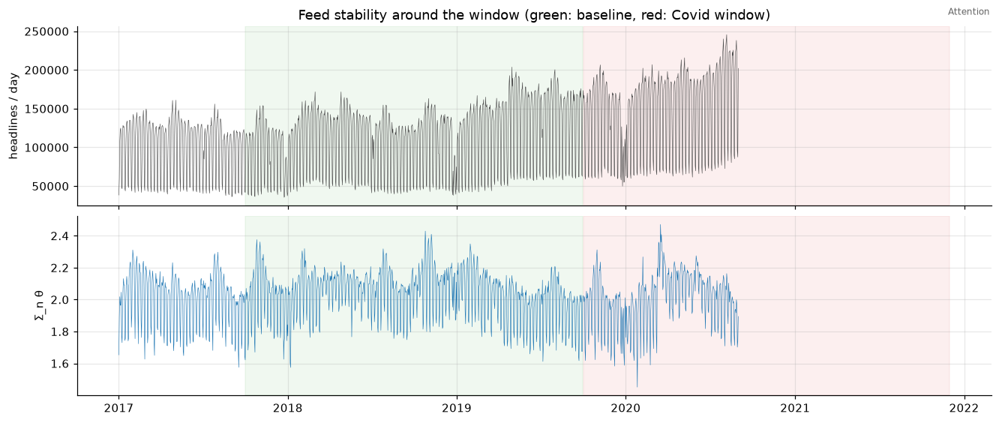

Y,headlines/day,mean Σθ
i32,f64,f64
2017,98757.0,2.002
2018,106540.0,2.068
2019,128253.0,1.982
2020,152220.0,2.025


In [5]:
flow = (daily.filter(pl.col("DATE").is_between(date(2017, 1, 1), VIEW[1]))
        .group_by("DATE").agg(pl.col("N_HEADLINES").first(), pl.col("THETA").sum().alias("SUM_THETA"))
        .sort("DATE"))
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(flow["DATE"], flow["N_HEADLINES"], lw=0.4, color="0.3"); axes[0].set_ylabel("headlines / day")
axes[1].plot(flow["DATE"], flow["SUM_THETA"], lw=0.4, color="tab:blue"); axes[1].set_ylabel("Σ_n θ")
for ax in axes:
    ax.axvspan(*WINDOW, color="tab:red", alpha=0.07); ax.axvspan(*BASELINE, color="tab:green", alpha=0.07)
axes[0].set_title("Feed stability around the window (green: baseline, red: Covid window)")
plt.show()
yr = (flow.with_columns(pl.col("DATE").dt.year().alias("Y")).group_by("Y")
      .agg(pl.col("N_HEADLINES").mean().round(0).alias("headlines/day"),
           pl.col("SUM_THETA").mean().round(3).alias("mean Σθ")).sort("Y"))
yr

## A.2. Post-processing pipeline (stages 1–5)

Same functions as the GFC notebook, with two additions: a trailing-window option for the
stage-1 seasonal mean, and a second (short) composite. Everything is per `narrative_key` and
uses only information available at the Friday of week *t*.

In [6]:
def deseasonalise(daily: pl.DataFrame, min_prior_years: int = MIN_PRIOR_YEARS,
                  seasonal_years: int | None = SEASONAL_YEARS) -> pl.DataFrame:
    # stage 1: subtract the prior-years-only week-of-year mean (expanding, or trailing N years)
    d = daily.with_columns(pl.col("DATE").dt.iso_year().alias("YEAR"),
                           pl.col("DATE").dt.week().clip(1, 52).alias("WOY"))
    yw = (d.group_by(KEY, "YEAR", "WOY").agg(pl.col("THETA").mean().alias("YW_MEAN"))
          .sort(KEY, "WOY", "YEAR")
          .with_columns(pl.col("YW_MEAN").is_not_null().cast(pl.Int32).alias("_has"),
                        pl.col("YW_MEAN").fill_null(0.0).alias("_v")))
    if seasonal_years is None:
        yw = yw.with_columns(pl.col("_v").cum_sum().shift(1).over(KEY, "WOY").alias("_psum"),
                             pl.col("_has").cum_sum().shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
    else:
        n = int(seasonal_years)
        yw = yw.with_columns(
            pl.col("_v").rolling_sum(n, min_samples=1).shift(1).over(KEY, "WOY").alias("_psum"),
            pl.col("_has").rolling_sum(n, min_samples=1).shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
    yw = (yw.with_columns(pl.when(pl.col("N_PRIOR_YEARS") >= min_prior_years)
                          .then(pl.col("_psum") / pl.col("N_PRIOR_YEARS")).otherwise(None).alias("SEAS"))
          .select(KEY, "YEAR", "WOY", "SEAS", "N_PRIOR_YEARS"))
    return (d.join(yw, on=[KEY, "YEAR", "WOY"], how="left")
            .with_columns((pl.col("THETA") - pl.col("SEAS")).alias("THETA_DS")))


def weekly(d: pl.DataFrame) -> pl.DataFrame:
    # stage 2: Mon-Fri mean, stamped on the Friday, on a complete (week x key) grid
    w = (d.filter(pl.col("DATE").dt.weekday() <= 5)
         .with_columns((pl.col("DATE").dt.truncate("1w") + timedelta(days=4)).alias("WEEK"))
         .group_by(KEY, "WEEK")
         .agg(pl.col("THETA_DS").mean().alias("THETA_W"), pl.col("THETA").mean().alias("THETA_RAW_W"),
              pl.col("THETA").count().alias("N_DAYS")))
    grid = pl.DataFrame({"WEEK": pl.date_range(w["WEEK"].min(), w["WEEK"].max(), "1w", eager=True)}).join(
        w.select(KEY).unique(), how="cross")
    return grid.join(w, on=[KEY, "WEEK"], how="left").sort(KEY, "WEEK")


def changes_and_horizons(w: pl.DataFrame, value: str = "THETA_W", horizons=ALL_H) -> pl.DataFrame:
    # stage 3 (first difference) + stage 4 (backward rolling mean over h weeks, full windows only)
    w = w.with_columns(pl.col(value).diff().over(KEY).alias("DTHETA"))
    return w.with_columns([pl.col("DTHETA").rolling_mean(h, min_samples=h).over(KEY).alias(f"D{h}")
                           for h in horizons])


def composite(w: pl.DataFrame, all_h=ALL_H) -> pl.DataFrame:
    # stage 5: each horizon / its own cross-sectional std (ddof=0, NOT demeaned), averaged over H
    w = w.with_columns([(pl.col(f"D{h}") / pl.col(f"D{h}").std(ddof=0).over("WEEK")).alias(f"Z{h}")
                        for h in all_h])

    def avg(hs, name):
        z = [pl.col(f"Z{h}") for h in hs]
        ok = pl.all_horizontal([c.is_not_null() & c.is_finite() for c in z])
        return pl.when(ok).then(pl.sum_horizontal(z) / len(z)).otherwise(None).alias(name)

    return w.with_columns(avg(COMPOSITE_H, "COMPOSITE"), avg(COMPOSITE_SHORT_H, "COMPOSITE_S"))


def post_process(daily: pl.DataFrame, deseason: bool = True, seasonal_years=SEASONAL_YEARS) -> pl.DataFrame:
    d = (deseasonalise(daily, seasonal_years=seasonal_years) if deseason
         else daily.with_columns(pl.col("THETA").alias("THETA_DS")))
    return composite(changes_and_horizons(weekly(d)))


daily_ds = deseasonalise(daily)
panel = composite(changes_and_horizons(weekly(daily_ds)))
print(f"{panel.height:,} (week x narrative) rows | weeks {panel['WEEK'].min()} .. {panel['WEEK'].max()}")
cs = panel.filter(pl.col("COMPOSITE").is_not_null())
for h in COMPOSITE_H:
    s = cs.group_by("WEEK").agg(pl.col(f"Z{h}").std(ddof=0))[f"Z{h}"]
    assert np.allclose(s.to_numpy(), 1.0, atol=1e-6), h
print("σ^(h) normalisation holds; window weeks with a composite:",
      cs.filter(pl.col("WEEK").is_between(*VIEW))["WEEK"].n_unique())

392,288 (week x narrative) rows | weeks 2000-04-07 .. 2020-09-04
σ^(h) normalisation holds; window weeks with a composite: 49


### A.2.1 Stage-by-stage walk-through on the pandemic narrative

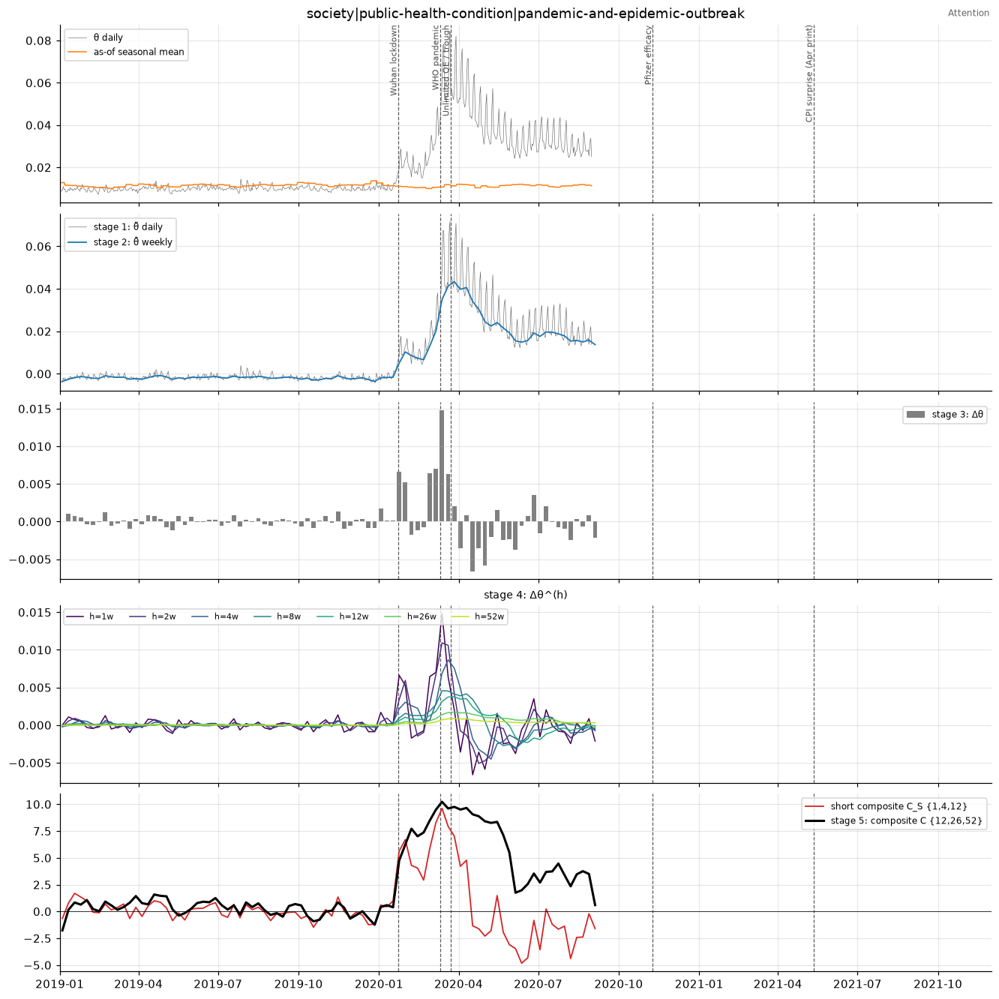

In [7]:
k0 = NAME_TO_KEYS[SHOWCASE][0]
lo = date(2019, 1, 1)
dd = daily_ds.filter((pl.col(KEY) == k0) & pl.col("DATE").is_between(lo, VIEW[1]))
pp = panel.filter((pl.col(KEY) == k0) & pl.col("WEEK").is_between(lo, VIEW[1]))

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(dd["DATE"], dd["THETA"], lw=0.4, color="0.4", label="θ daily")
axes[0].plot(dd["DATE"], dd["SEAS"], lw=1.0, color="tab:orange", label="as-of seasonal mean")
axes[0].set_title(k0); axes[0].legend(loc="upper left", fontsize=8)
axes[1].plot(dd["DATE"], dd["THETA_DS"], lw=0.4, color="0.4", label="stage 1: θ̃ daily")
axes[1].plot(pp["WEEK"], pp["THETA_W"], lw=1.2, color="tab:blue", label="stage 2: θ̄ weekly")
axes[1].legend(loc="upper left", fontsize=8)
axes[2].bar(pp["WEEK"], pp["DTHETA"], width=5, color="0.5", label="stage 3: Δθ"); axes[2].legend(fontsize=8)
for h, c in zip(ALL_H, plt.cm.viridis(np.linspace(0, 0.9, len(ALL_H)))):
    axes[3].plot(pp["WEEK"], pp[f"D{h}"], lw=1.0, color=c, label=f"h={h}w")
axes[3].set_title("stage 4: Δθ^(h)", fontsize=9); axes[3].legend(ncol=len(ALL_H), fontsize=7, loc="upper left")
axes[4].plot(pp["WEEK"], pp["COMPOSITE_S"], lw=1.2, color="tab:red", label="short composite C_S {1,4,12}")
axes[4].plot(pp["WEEK"], pp["COMPOSITE"], lw=2.0, color="k", label="stage 5: composite C {12,26,52}")
axes[4].axhline(0, color="k", lw=0.5); axes[4].legend(fontsize=8, loc="upper right")
for ax in axes:
    date_axis(ax, lo, VIEW[1]); shade_events(ax, labels=ax is axes[0])
plt.show()

## A.3. Composite properties over the window

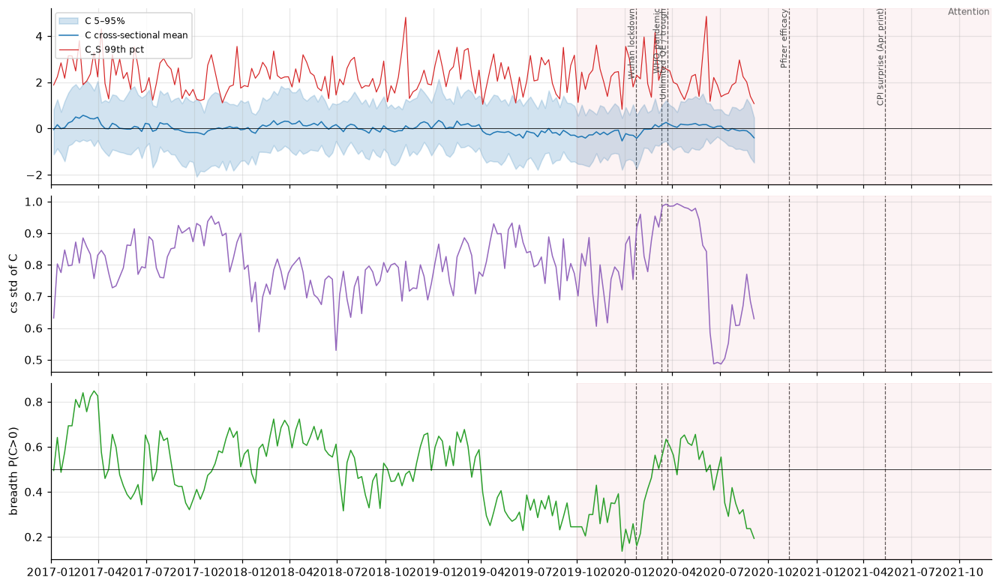

In [8]:
xs = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(date(2017, 1, 1), VIEW[1]))
      .group_by("WEEK")
      .agg(pl.col("COMPOSITE").mean().alias("MEAN"), pl.col("COMPOSITE").std(ddof=0).alias("STD"),
           (pl.col("COMPOSITE") > 0).mean().alias("BREADTH"),
           pl.col("COMPOSITE").quantile(0.95).alias("Q95"), pl.col("COMPOSITE").quantile(0.05).alias("Q05"),
           pl.col("COMPOSITE_S").quantile(0.99).alias("QS99"))
      .sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].fill_between(xs["WEEK"], xs["Q05"], xs["Q95"], color="tab:blue", alpha=0.2, label="C 5–95%")
axes[0].plot(xs["WEEK"], xs["MEAN"], color="tab:blue", lw=1, label="C cross-sectional mean")
axes[0].plot(xs["WEEK"], xs["QS99"], color="tab:red", lw=0.8, label="C_S 99th pct")
axes[0].axhline(0, color="k", lw=0.5); axes[0].legend(fontsize=8, loc="upper left")
axes[1].plot(xs["WEEK"], xs["STD"], color="tab:purple", lw=1); axes[1].set_ylabel("cs std of C")
axes[2].plot(xs["WEEK"], xs["BREADTH"], color="tab:green", lw=1); axes[2].axhline(0.5, color="k", lw=0.5)
axes[2].set_ylabel("breadth P(C>0)")
for ax in axes:
    date_axis(ax, date(2017, 1, 1), VIEW[1]); ax.axvspan(*WINDOW, color="tab:red", alpha=0.05)
    shade_events(ax, labels=ax is axes[0])
plt.show()

## A.4. Predeclared Covid batteries

Battery composite = equal-weight mean of C (and of C_S) over the battery's narrative keys.
The diagnostic battery is drawn dotted/grey: **PLACEBO** is topic-orthogonal (should stay
unremarkable). v3 has no mirror-pole battery: the poles are merged into one narrative.

**v3:** a battery entry naming a pole (e.g. `housing-bust`) now stands for the whole merged narrative (housing-bust + housing-boom); Parts B (negative), C (positive + neutral) and D (positive) carry the direction. The battery cell prints which entries are poles. The placebo holds no narrative merged with a crisis pole (asserted); its only pair, allowance-cap tightening / loosening, is placebo on both sides.


In [9]:
name_to_keys = NAME_TO_KEYS     # narrative names, pole names mapped to their merged narrative
print("pole entries (now the whole merged narrative):",
      {b: pole_entries(ns) for b, ns in BATTERIES.items() if pole_entries(ns)})
_placebo = {k for n in BATTERIES[PLACEBO] for k in NAME_TO_KEYS.get(n, [])}
_stress = {k for b, ns in BATTERIES.items() if b != PLACEBO for n in ns for k in NAME_TO_KEYS.get(n, [])}
assert not _placebo & _stress, f"placebo shares merged narratives with other batteries: {sorted(_placebo & _stress)}"
BATTERIES_STUDY = {b: ns + PLACEBO_BY_STUDY.get(STUDY, []) if b == PLACEBO else ns
                   for b, ns in BATTERIES.items()}
if PLACEBO_BY_STUDY.get(STUDY):
    print(f"{STUDY}: placebo adds {PLACEBO_BY_STUDY[STUDY]} (this study only; same merged "
          f"narratives as stress entries, read on the {'+'.join(STUDIES[STUDY])} label)")
BKEYS = {}
for b, names in BATTERIES_STUDY.items():
    missing = [n for n in names if n not in name_to_keys]
    if missing:
        print(f"[{b}] names not in the taxonomy: {missing}")
    BKEYS[b] = list(dict.fromkeys(k for n in names for k in name_to_keys.get(n, [])))   # two poles of one pair: one merged key
print({b: len(k) for b, k in BKEYS.items()})
blist = [b for b in BKEYS if BKEYS[b]]


def battery_frame(panel, col, bkeys):
    wide = panel.filter(pl.col(col).is_not_null()).pivot(on=KEY, index="WEEK", values=col).sort("WEEK")
    m = wide.drop("WEEK")
    return wide["WEEK"], m, pl.DataFrame({"WEEK": wide["WEEK"], **{
        b: np.nanmean(m.select([k for k in ks if k in m.columns]).to_numpy(), axis=1)
        for b, ks in bkeys.items() if ks}})


WEEKS, C, bat = battery_frame(panel, "COMPOSITE", BKEYS)
WEEKS_S, CS, bat_s = battery_frame(panel, "COMPOSITE_S", BKEYS)
base = bat.filter(pl.col("WEEK").is_between(*BASELINE))
batz = bat.with_columns([((pl.col(b) - base[b].mean()) / base[b].std()).alias(b) for b in blist])
v = bat.filter(pl.col("WEEK").is_between(*VIEW)); v_s = bat_s.filter(pl.col("WEEK").is_between(*VIEW))
print(f"baseline {BASELINE[0]} .. {BASELINE[1]}: {base.height} weeks")

pole entries (now the whole merged narrative): {'health shock': ['public-health-deterioration'], 'lockdown / state control': ['state-direction-expansion'], 'monetary response': ['balance-sheet-expansion', 'global-liquidity-easing'], 'real contraction': ['business-cycle-contraction', 'labour-market-slackening', 'guidance-cut', 'dividend-cut'], 'corporate distress': ['credit-deterioration', 'rating-downgrade'], 'oil / demand collapse': ['demand-destruction', 'demand-driven-price-collapse', 'curve-contango'], 'vaccine / health recovery': ['public-health-improvement'], 'reopening / recovery': ['business-cycle-expansion', 'capex-upswing'], 'reflation / inflation': ['price-level-change-reflation', 'labour-market-tightening', 'input-cost-squeeze'], 'PLACEBO (orthogonal)': ['allowance-cap-tightening', 'allowance-cap-loosening']}
{'health shock': 3, 'lockdown / state control': 3, 'market crash': 7, 'dash for cash / funding': 7, 'monetary response': 7, 'fiscal response': 4, 'real contraction': 7

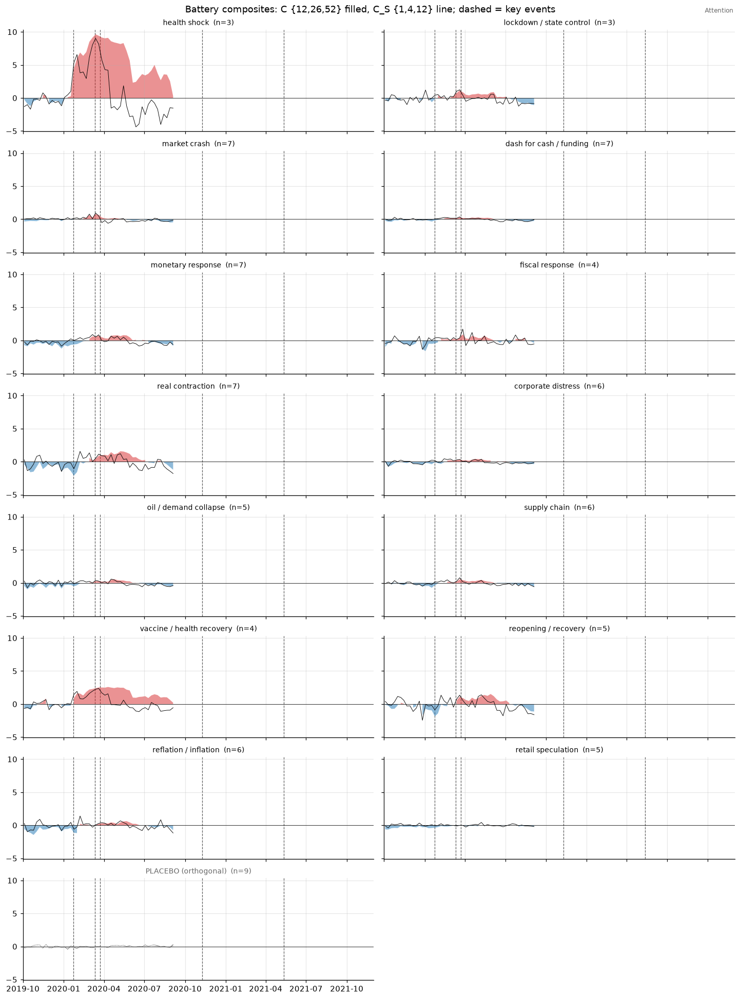

In [10]:
ncol = 2
nrow = int(np.ceil(len(blist) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.2 * nrow), sharex=True, sharey=True)
for ax, b in zip(axes.flat, blist):
    y = v[b].to_numpy()
    diag = b in DIAGNOSTIC
    ax.fill_between(v["WEEK"], 0, y, where=y > 0, color="0.6" if diag else "tab:red", alpha=0.5, lw=0)
    ax.fill_between(v["WEEK"], 0, y, where=y < 0, color="0.8" if diag else "tab:blue", alpha=0.5, lw=0)
    ax.plot(v_s["WEEK"], v_s[b], color="k", lw=0.6, ls=":" if diag else "-", label="C_S")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{b}  (n={len(BKEYS[b])})", fontsize=9, color="0.4" if diag else "k")
    date_axis(ax)
for ax in axes.flat[len(blist):]:
    ax.axis("off")
for ax in axes.flat[:len(blist)]:
    shade_events(ax, labels=False)
fig.suptitle("Battery composites: C {12,26,52} filled, C_S {1,4,12} line; dashed = key events")
plt.show()

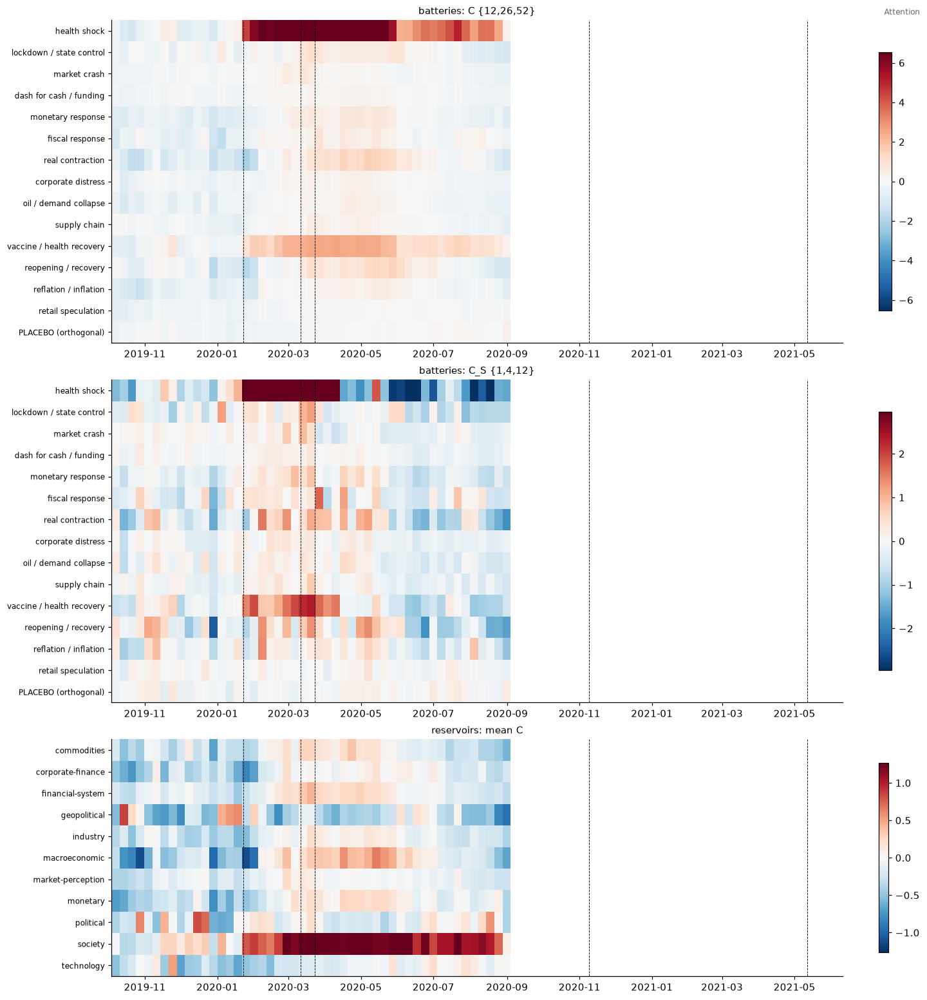

In [11]:
def heat(ax, frame, rows, title, vmax=None):
    m = frame.select(rows).to_numpy().T
    vmax = vmax or np.nanpercentile(np.abs(m), 98)
    x = mdates.date2num(frame["WEEK"].to_list())
    im = ax.imshow(m, aspect="auto", cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax),
                   extent=[x[0], x[-1], len(rows) - 0.5, -0.5], interpolation="nearest")
    ax.set_yticks(range(len(rows)), rows, fontsize=8); ax.xaxis_date(); ax.grid(False)
    for name in KEY_EVENTS:
        ax.axvline(EVENTS[name], color="k", lw=0.6, ls="--")
    ax.set_title(title, fontsize=10)
    return im


res = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(*VIEW))
       .join(NARR.select(KEY, "reservoir"), on=KEY)
       .group_by("WEEK", "reservoir").agg(pl.col("COMPOSITE").mean())
       .pivot(on="reservoir", index="WEEK", values="COMPOSITE").sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(13, 14), height_ratios=[len(blist), len(blist), res.width - 1])
fig.colorbar(heat(axes[0], v, blist, "batteries: C {12,26,52}"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], v_s, blist, "batteries: C_S {1,4,12}"), ax=axes[1], shrink=0.8)
fig.colorbar(heat(axes[2], res, sorted(res.columns[1:]), "reservoirs: mean C"), ax=axes[2], shrink=0.8)
plt.show()

### A.4.1 Event table: permutation test and block-bootstrap baseline band

* `C`, `C_S`: battery composites in the event week (first Friday on/after the event).
* `perm_p`: share of `N_PERM` random equal-size batteries, same week, with a composite ≥ the
  battery's (controls for moves common to all narratives that week).
* `boot_p`: share of `N_BOOT` block-bootstrap draws of the battery's own **baseline** weekly
  composite (blocks of `BLOCK_WEEKS` weeks, preserving serial correlation) whose block maximum
  is ≥ the event value; a conservative "is this outside anything seen pre-Covid" test.

In [12]:
wk_arr = np.array(WEEKS.to_list())
col_of = {k: i for i, k in enumerate(C.columns)}
Cn = C.to_numpy()


def event_week(d):
    return min(int(np.searchsorted(wk_arr, d)), len(wk_arr) - 1)


def perm_p(row, idx, n_perm=N_PERM):
    # vectorised: n_perm random subsets of size k without replacement (argpartition of uniforms)
    x = row[~np.isnan(row)]
    obs = np.nanmean(row[idx])
    k = len(idx)
    pick = np.argpartition(RNG.random((n_perm, len(x))), k, axis=1)[:, :k]
    draws = x[pick].mean(axis=1)
    return obs, (1 + (draws >= obs).sum()) / (n_perm + 1)


def boot_block_max(series, n_boot=N_BOOT, block=BLOCK_WEEKS):
    # distribution of the max of one block drawn from the baseline series (moving-block bootstrap)
    s = series[~np.isnan(series)]
    starts = RNG.integers(0, len(s) - block + 1, n_boot)
    return np.array([s[i:i + block].max() for i in starts])


boot = {b: boot_block_max(base[b].to_numpy()) for b in blist}
rows = []
for ev, d in EVENTS.items():
    if not (VIEW[0] <= d <= VIEW[1]):
        continue
    i = event_week(d)
    i_s = min(int(np.searchsorted(np.array(WEEKS_S.to_list()), d)), bat_s.height - 1)
    for b in blist:
        idx = np.array([col_of[k] for k in BKEYS[b] if k in col_of])
        obs, p = perm_p(Cn[i], idx)
        rows.append({"event": ev, "week": wk_arr[i], "battery": b, "C": obs, "C_S": bat_s[b][i_s],
                     "z_vs_baseline": batz[b][i], "perm_p": p,
                     "boot_p": (1 + (boot[b] >= obs).sum()) / (N_BOOT + 1)})
ev_tab = pl.DataFrame(rows)
for col, dig in (("C", 2), ("C_S", 2), ("perm_p", 3), ("boot_p", 3)):
    print(col)
    display(ev_tab.pivot(on="event", index="battery", values=col).with_columns(pl.selectors.float().round(dig)))

C


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",-0.18,4.45,8.51,9.13,9.63,9.42,9.15,9.15,8.41,0.28,0.28,0.28,0.28,0.28,0.28
"""lockdown / state control""",0.62,-0.19,0.09,0.28,0.74,1.12,0.88,0.88,0.57,-1.07,-1.07,-1.07,-1.07,-1.07,-1.07
"""market crash""",-0.03,-0.04,0.62,0.28,0.78,0.65,0.25,0.25,0.17,-0.46,-0.46,-0.46,-0.46,-0.46,-0.46
"""dash for cash / funding""",-0.12,-0.2,0.12,0.12,0.15,0.27,0.18,0.18,0.21,-0.28,-0.28,-0.28,-0.28,-0.28,-0.28
"""monetary response""",-0.72,-0.61,0.24,0.61,0.55,0.71,0.47,0.47,0.74,-0.85,-0.85,-0.85,-0.85,-0.85,-0.85
"""fiscal response""",-1.62,-0.45,0.07,0.26,0.14,0.4,0.92,0.92,0.54,-0.39,-0.39,-0.39,-0.39,-0.39,-0.39
"""real contraction""",-1.02,-2.12,0.6,0.15,0.42,0.88,0.97,0.97,1.1,-1.23,-1.23,-1.23,-1.23,-1.23,-1.23
"""corporate distress""",-0.2,-0.09,0.22,0.12,0.22,0.32,0.2,0.2,0.41,-0.37,-0.37,-0.37,-0.37,-0.37,-0.37
"""oil / demand collapse""",-0.27,-0.52,0.08,0.04,0.26,0.25,0.19,0.19,0.55,-0.49,-0.49,-0.49,-0.49,-0.49,-0.49


C_S


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.11,5.33,6.18,8.04,9.03,8.16,5.76,5.76,-1.29,-1.54,-1.54,-1.54,-1.54,-1.54,-1.54
"""lockdown / state control""",1.21,0.41,0.26,0.17,1.01,1.24,0.44,0.44,-0.08,-0.85,-0.85,-0.85,-0.85,-0.85,-0.85
"""market crash""",-0.04,0.12,0.77,0.06,0.94,0.49,-0.52,-0.52,0.09,-0.15,-0.15,-0.15,-0.15,-0.15,-0.15
"""dash for cash / funding""",-0.1,0.04,0.15,0.14,0.13,0.35,0.0,0.0,0.07,-0.07,-0.07,-0.07,-0.07,-0.07,-0.07
"""monetary response""",-0.45,-0.0,0.45,0.89,0.51,0.85,-0.02,-0.02,0.34,-0.63,-0.63,-0.63,-0.63,-0.63,-0.63
"""fiscal response""",-0.66,0.37,-0.02,0.43,0.14,0.36,1.71,1.71,-0.51,-0.54,-0.54,-0.54,-0.54,-0.54,-0.54
"""real contraction""",-0.44,-1.09,1.33,-0.0,0.49,1.13,0.89,0.89,-0.29,-1.8,-1.8,-1.8,-1.8,-1.8,-1.8
"""corporate distress""",-0.06,0.16,0.4,0.15,0.25,0.33,0.02,0.02,0.33,-0.16,-0.16,-0.16,-0.16,-0.16,-0.16
"""oil / demand collapse""",0.15,-0.16,0.22,-0.03,0.38,0.26,0.02,0.02,0.46,-0.41,-0.41,-0.41,-0.41,-0.41,-0.41


perm_p


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.029,0.029,0.026,0.028,0.028,0.029
"""lockdown / state control""",0.055,0.263,0.487,0.119,0.047,0.031,0.039,0.04,0.102,0.965,0.965,0.965,0.966,0.966,0.966
"""market crash""",0.215,0.097,0.069,0.087,0.055,0.074,0.243,0.241,0.41,0.606,0.603,0.607,0.606,0.605,0.606
"""dash for cash / funding""",0.311,0.201,0.459,0.243,0.404,0.35,0.347,0.349,0.336,0.28,0.281,0.279,0.282,0.286,0.282
"""monetary response""",0.959,0.765,0.284,0.057,0.072,0.062,0.092,0.093,0.057,0.97,0.97,0.97,0.971,0.97,0.97
"""fiscal response""",1.0,0.602,0.521,0.116,0.411,0.218,0.035,0.036,0.105,0.481,0.484,0.487,0.483,0.485,0.482
"""real contraction""",0.996,1.0,0.074,0.19,0.1,0.058,0.052,0.051,0.04,0.999,0.999,0.999,1.0,1.0,0.999
"""corporate distress""",0.418,0.13,0.306,0.248,0.287,0.288,0.32,0.325,0.146,0.448,0.442,0.446,0.444,0.45,0.449
"""oil / demand collapse""",0.513,0.676,0.518,0.4,0.245,0.397,0.342,0.34,0.087,0.635,0.634,0.63,0.636,0.633,0.628


boot_p


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.864,0.864,0.864,0.864,0.864,0.864
"""lockdown / state control""",0.526,1.0,0.906,0.68,0.517,0.177,0.487,0.487,0.561,1.0,1.0,1.0,1.0,1.0,1.0
"""market crash""",0.947,0.947,0.085,0.467,0.085,0.085,0.467,0.467,0.57,1.0,1.0,1.0,1.0,1.0,1.0
"""dash for cash / funding""",0.911,1.0,0.675,0.708,0.675,0.422,0.571,0.571,0.571,1.0,1.0,1.0,1.0,1.0,1.0
"""monetary response""",1.0,1.0,0.918,0.464,0.609,0.108,0.714,0.714,0.108,1.0,1.0,1.0,1.0,1.0,1.0
"""fiscal response""",1.0,1.0,0.835,0.775,0.798,0.661,0.418,0.418,0.585,1.0,1.0,1.0,1.0,1.0,1.0
"""real contraction""",1.0,1.0,0.663,0.808,0.725,0.486,0.486,0.486,0.43,1.0,1.0,1.0,1.0,1.0,1.0
"""corporate distress""",0.935,0.907,0.741,0.75,0.741,0.594,0.741,0.741,0.506,0.983,0.983,0.983,0.983,0.983,0.983
"""oil / demand collapse""",0.812,0.93,0.692,0.766,0.588,0.588,0.588,0.588,0.232,0.93,0.93,0.93,0.93,0.93,0.93


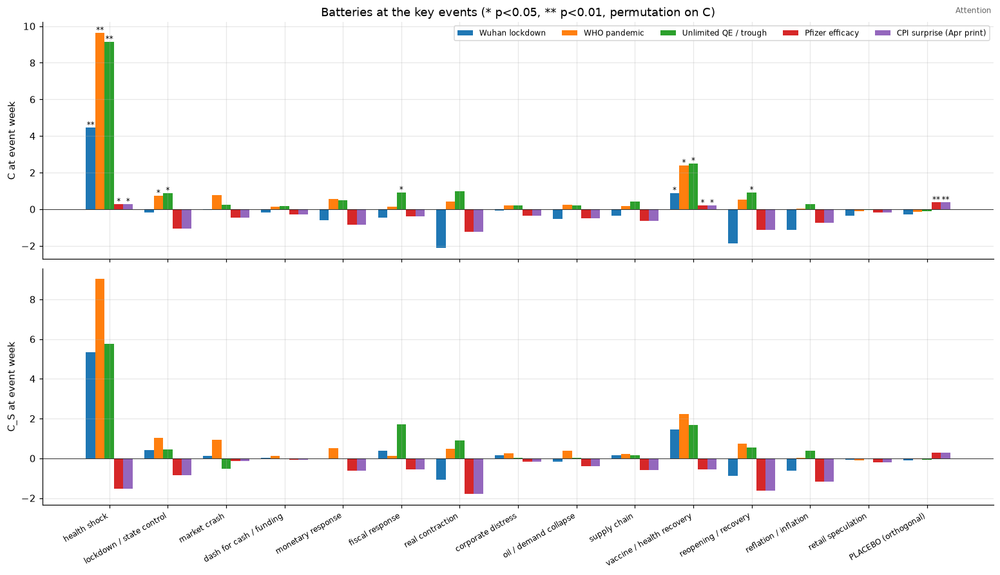

In [13]:
pz = ev_tab.filter(pl.col("event").is_in(list(KEY_EVENTS)))
evs = [e for e in KEY_EVENTS if e in pz["event"].unique().to_list()]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, col in zip(axes, ("C", "C_S")):
    wbar = 0.8 / max(len(evs), 1)
    for j, e in enumerate(evs):
        g = pz.filter(pl.col("event") == e).sort(pl.col("battery").replace_strict({b: i for i, b in enumerate(blist)}))
        xs_ = np.arange(len(blist)) + j * wbar
        ax.bar(xs_, g[col], width=wbar, label=e)
        if col == "C":
            for x_, c_, p_ in zip(xs_, g["C"], g["perm_p"]):
                if p_ < 0.05:
                    ax.text(x_, c_ + (0.03 if c_ >= 0 else -0.12), "*" if p_ >= 0.01 else "**",
                            ha="center", fontsize=8)
    ax.axhline(0, color="k", lw=0.5); ax.set_ylabel(f"{col} at event week")
axes[1].set_xticks(np.arange(len(blist)) + 0.4 - wbar / 2, blist, rotation=30, ha="right", fontsize=8)
axes[0].legend(fontsize=8, ncol=len(evs)); axes[0].set_title("Batteries at the key events (* p<0.05, ** p<0.01, permutation on C)")
plt.show()

## A.5. Horizon term structure at the key events

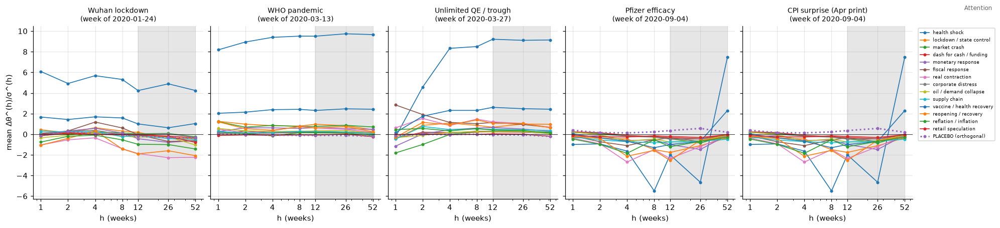

In [14]:
term = panel.select("WEEK", KEY, *[f"Z{h}" for h in ALL_H])
fig, axes = plt.subplots(1, len(KEY_EVENTS), figsize=(18, 4), sharey=True)
for ax, e in zip(axes, KEY_EVENTS):
    wk = wk_arr[event_week(EVENTS[e])]
    t = term.filter(pl.col("WEEK") == wk)
    for b in blist:
        g = t.filter(pl.col(KEY).is_in(BKEYS[b])).select([pl.col(f"Z{h}").mean() for h in ALL_H]).row(0)
        diag = b in DIAGNOSTIC
        ax.plot(ALL_H, g, marker="o", ms=3, lw=2 if diag else 1.1, ls=":" if diag else "-", label=b)
    ax.axhline(0, color="k", lw=0.5); ax.set_xscale("log"); ax.set_xticks(ALL_H, [str(h) for h in ALL_H])
    ax.axvspan(min(COMPOSITE_H), max(COMPOSITE_H), color="0.9", zorder=0)
    ax.set_title(f"{e}\n(week of {wk})", fontsize=9); ax.set_xlabel("h (weeks)")
axes[0].set_ylabel("mean Δθ^(h)/σ^(h)")
axes[-1].legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## A.6. Unsupervised cross-sections

All narratives (poles merged) ranked by the short composite in the crash (Feb-24 → Apr-3 2020) and by
the long composite in the vaccine/reflation phase (Nov-2020 → Jun-2021). Colour = reservoir.

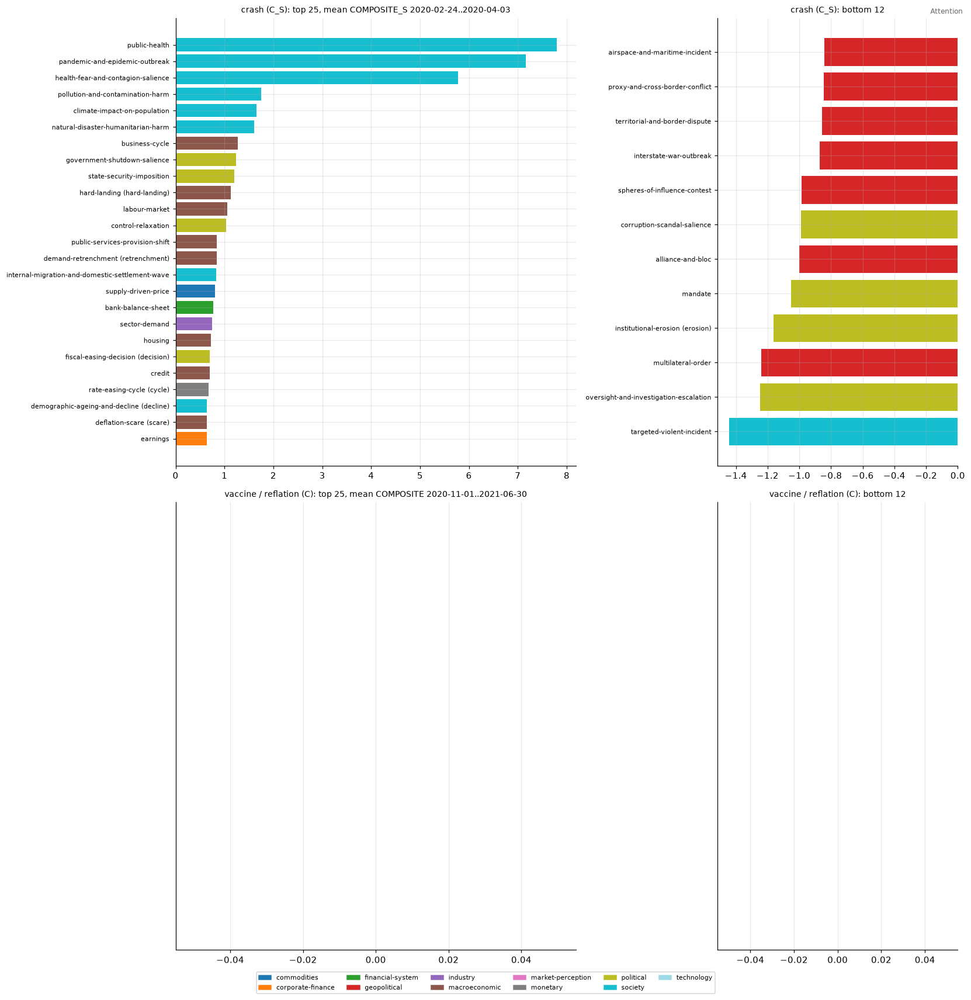

In [16]:
resv = sorted(NARR["reservoir"].unique().to_list())
cmap = dict(zip(resv, plt.cm.tab20(np.linspace(0, 1, len(resv)))))
in_b = {k for b in blist if b not in DIAGNOSTIC for k in BKEYS[b]}


def ranked(col, lo, hi):
    return (panel.filter(pl.col("WEEK").is_between(lo, hi) & pl.col(col).is_not_null())
            .group_by(KEY).agg(pl.col(col).mean().alias("V")).join(NARR, on=KEY).sort("V", descending=True))


def barplot(ax, t, title):
    lab = [f"{r['narrative']} ({r['pole']})" if r["pole"] else r["narrative"] for r in t.iter_rows(named=True)]
    ax.barh(range(t.height), t["V"], color=[cmap[r] for r in t["reservoir"]])
    ax.set_yticks(range(t.height), lab, fontsize=7); ax.invert_yaxis(); ax.set_title(title, fontsize=9)


phases = {"crash (C_S)": ("COMPOSITE_S", date(2020, 2, 24), date(2020, 4, 3)),
          "vaccine / reflation (C)": ("COMPOSITE", date(2020, 11, 1), date(2021, 6, 30))}
fig, axes = plt.subplots(2, 2, figsize=(15, 15), width_ratios=[5, 3])
for row, (name, (col, lo, hi)) in enumerate(phases.items()):
    r = ranked(col, lo, hi)
    barplot(axes[row, 0], r.head(25), f"{name}: top 25, mean {col} {lo}..{hi}")
    barplot(axes[row, 1], r.tail(12), f"{name}: bottom 12")
    # print(f"{name}: battery narratives among top 25 = {r.head(25).filter(pl.col(KEY).is_in(in_b)).height} "
    #       f"(chance ≈ {25 * len(in_b) / r.height:.1f})")
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[r]) for r in resv]
fig.legend(handles, resv, fontsize=7, loc="lower center", ncol=min(6, len(resv)), bbox_to_anchor=(0.5, -0.03))
plt.show()

## A.7. Narrative waves: onset and peak timing

Onset = first week in the window where the battery's C_S exceeds `ONSET_THRESHOLD` (C_S because
Covid is abrupt); peak = arg-max of C over the window. Expected ordering: health shock →
market crash / dash for cash → monetary → fiscal → real contraction / distress / oil → supply
chain → vaccine → reopening → reflation (with retail speculation in early 2021).

battery,onset_CS,peak_C,max_C,max_CS,weeks_CS_lit
str,date,date,f64,f64,i64
"""health shock""",2020-01-24,2020-03-13,9.63,9.03,13
"""market crash""",null,2020-03-13,0.78,0.94,0
"""lockdown / state control""",2020-01-03,2020-03-20,1.12,1.24,3
"""dash for cash / funding""",null,2020-03-20,0.27,0.35,0
"""supply chain""",null,2020-03-20,0.53,0.77,0
"""fiscal response""",2020-03-27,2020-03-27,0.92,1.71,2
"""vaccine / health recovery""",2020-01-24,2020-04-10,2.59,2.37,10
"""corporate distress""",null,2020-04-24,0.41,0.43,0
"""oil / demand collapse""",null,2020-04-24,0.55,0.57,0


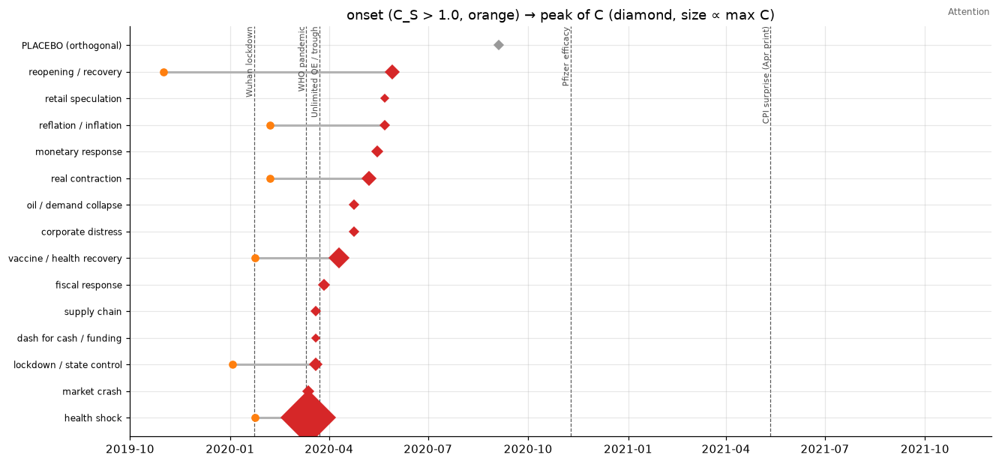

In [17]:
win = v.join(v_s, on="WEEK", suffix="_S")
wv = []
for b in blist:
    ys = win[f"{b}_S"].to_numpy(); y = win[b].to_numpy()
    on = np.flatnonzero(ys > ONSET_THRESHOLD)
    wv.append({"battery": b, "onset_CS": win["WEEK"][int(on[0])] if on.size else None,
               "peak_C": win["WEEK"][int(np.nanargmax(y))], "max_C": float(np.nanmax(y)),
               "max_CS": float(np.nanmax(ys)), "weeks_CS_lit": int(on.size)})
waves = pl.DataFrame(wv).sort("peak_C")
display(waves.with_columns(pl.selectors.float().round(2)))

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, r in enumerate(waves.iter_rows(named=True)):
    col = "0.6" if r["battery"] in DIAGNOSTIC else "tab:red"
    if r["onset_CS"] is not None:
        ax.plot([r["onset_CS"], r["peak_C"]], [i, i], color="0.7", lw=2)
        ax.plot(r["onset_CS"], i, "o", color="tab:orange")
    ax.plot(r["peak_C"], i, "D", color=col, ms=4 + 3 * max(r["max_C"], 0))
ax.set_yticks(range(waves.height), waves["battery"], fontsize=8)
date_axis(ax); shade_events(ax)
ax.set_title(f"onset (C_S > {ONSET_THRESHOLD}, orange) → peak of C (diamond, size ∝ max C)")
plt.show()

In [18]:
# the leading narratives of each quarter (mean C), 2019Q4 .. end of window
q = (panel.filter(pl.col("WEEK").is_between(*VIEW) & pl.col("COMPOSITE").is_not_null())
     .with_columns(pl.col("WEEK").dt.truncate("1q").alias("Q"))
     .group_by("Q", KEY).agg(pl.col("COMPOSITE").mean())
     .join(NARR.select(KEY, "narrative", "pole"), on=KEY)
     .with_columns(pl.when(pl.col("pole").fill_null("") != "").then(pl.format("{} ({})", "narrative", "pole"))
                   .otherwise(pl.col("narrative")).alias("label"))
     .sort("Q", "COMPOSITE", descending=[False, True])
     .group_by("Q", maintain_order=True).head(5)
     .with_columns(pl.format("{} {}", pl.col("label"), pl.col("COMPOSITE").round(2)).alias("top"))
     .group_by("Q", maintain_order=True).agg(pl.col("top"))
     .with_columns(pl.col("Q").dt.strftime("%Y-%m"), *[pl.col("top").list.get(i, null_on_oob=True).alias(f"#{i+1}")
                                                       for i in range(5)])
     .drop("top"))
q

Q,#1,#2,#3,#4,#5
str,str,str,str,str,str
"""2019-10""","""oversight-and-investigation-escalation 2.04""","""civil-unrest-and-protest-wave 1.52""","""corruption-scandal-salience 1.5""","""legislative-gridlock (gridlock) 0.92""","""control-relaxation 0.87"""
"""2020-01""","""public-health 6.41""","""pandemic-and-epidemic-outbreak 6.31""","""health-fear-and-contagion-salience 4.99""","""natural-disaster-humanitarian-harm 2.38""","""climate-impact-on-population 1.42"""
"""2020-04""","""public-health 8.22""","""pandemic-and-epidemic-outbreak 6.51""","""health-fear-and-contagion-salience 4.69""","""climate-impact-on-population 2.25""","""labour-market 1.99"""
"""2020-07""","""public-health 3.76""","""pandemic-and-epidemic-outbreak 3.17""","""health-fear-and-contagion-salience 2.86""","""climate-impact-on-population 2.18""","""internal-migration-and-domestic-settlement-wave 1.59"""


## A.8. Topic-level (direction-free) view

Attention summed over every narrative of a dimension (`reservoir|dimension`, poles pooled), then
the same stages 1–5. This is the quantity attention actually measures without ambiguity.

{'public health': 1, 'market volatility': 3, 'funding & plumbing': 3, 'monetary policy': 3, 'fiscal': 2, 'output & labour': 3, 'supply chain': 3, 'prices': 1, 'state control': 2, 'PLACEBO (orthogonal)': 3}


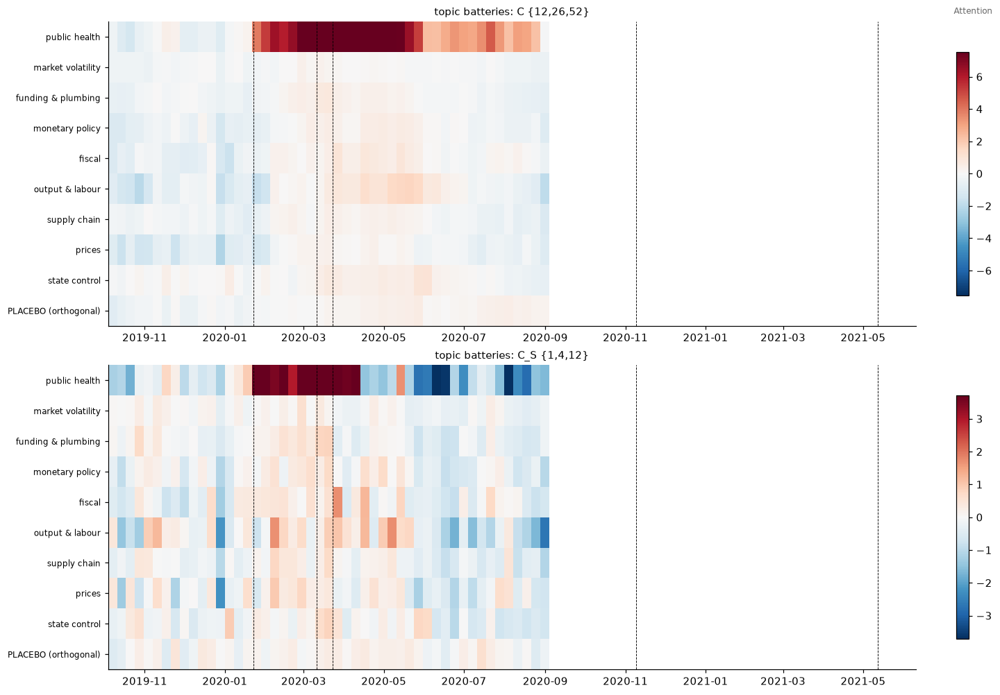

top / bottom dimensions in the crash (C_S) with their vaccine/reflation-phase C


narrative_key,C_S_crash,C_vaccine_reflation
str,f64,f64


In [19]:
topic_daily = (daily.group_by("DATE", "reservoir", "dimension")
               .agg(pl.col("THETA").sum(), pl.col("N_HEADLINES").first())
               .with_columns(pl.format("{}|{}", "reservoir", "dimension").alias(KEY)))
tpanel = post_process(topic_daily)
TKEYS = {b: [k for k in ks if k in set(tpanel[KEY].unique().to_list())] for b, ks in TOPIC_BATTERIES.items()}
print({b: len(k) for b, k in TKEYS.items()})
TW, TC, tbat = battery_frame(tpanel, "COMPOSITE", TKEYS)
_, _, tbat_s = battery_frame(tpanel, "COMPOSITE_S", TKEYS)
tv = tbat.filter(pl.col("WEEK").is_between(*VIEW)); tv_s = tbat_s.filter(pl.col("WEEK").is_between(*VIEW))
tlist = [b for b in TKEYS if TKEYS[b]]
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.colorbar(heat(axes[0], tv, tlist, "topic batteries: C {12,26,52}"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], tv_s, tlist, "topic batteries: C_S {1,4,12}"), ax=axes[1], shrink=0.8)
plt.show()

trank = (tpanel.filter(pl.col("WEEK").is_between(date(2020, 2, 24), date(2020, 4, 3)) & pl.col("COMPOSITE_S").is_not_null())
         .group_by(KEY).agg(pl.col("COMPOSITE_S").mean().alias("C_S_crash"))
         .join(tpanel.filter(pl.col("WEEK").is_between(date(2020, 11, 1), date(2021, 6, 30)))
               .group_by(KEY).agg(pl.col("COMPOSITE").mean().alias("C_vaccine_reflation")), on=KEY)
         .sort("C_S_crash", descending=True))
print("top / bottom dimensions in the crash (C_S) with their vaccine/reflation-phase C")
display(pl.concat([trank.head(12), trank.tail(6)]).with_columns(pl.selectors.float().round(2)))

## A.9. Robustness: stage-1 variants

corr(C spec, C trailing 5y seasonal) over the window = 0.946
corr(C spec, C no stage 1) over the window = 0.901


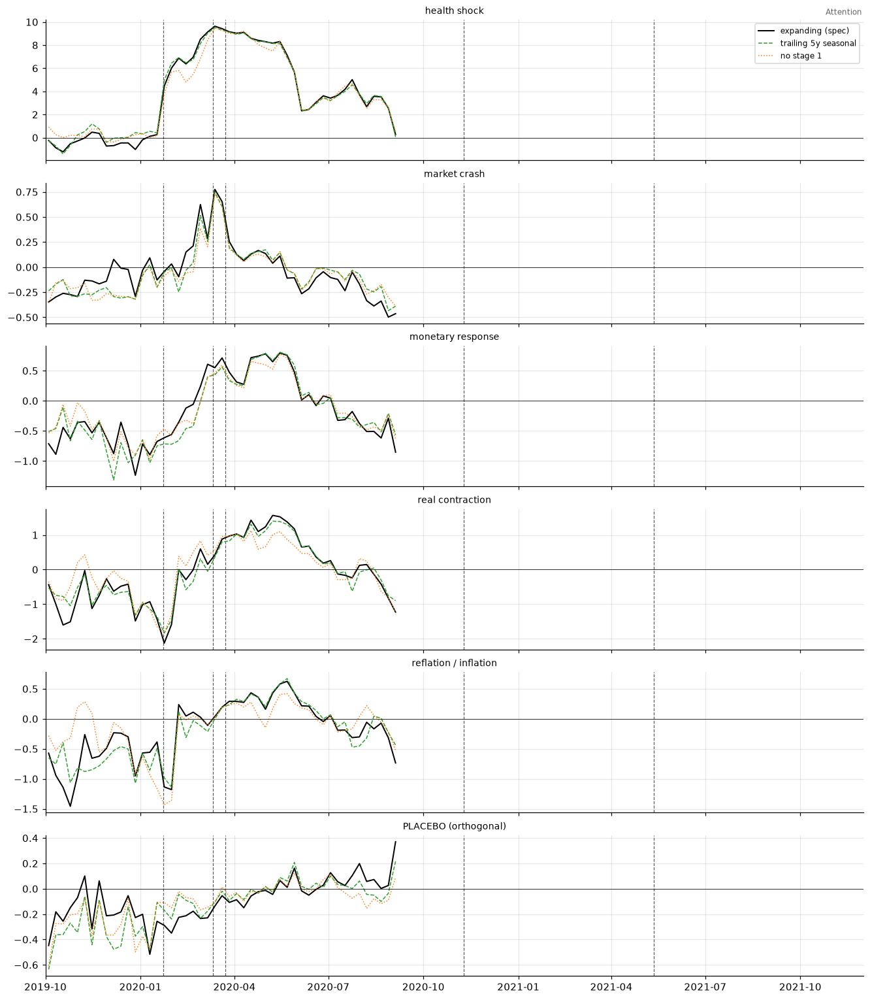

In [20]:
variants = {"expanding (spec)": panel,
            f"trailing {SEASONAL_YEARS_ROBUST}y seasonal": post_process(daily, seasonal_years=SEASONAL_YEARS_ROBUST),
            "no stage 1": post_process(daily, deseason=False)}
ref = panel.select("WEEK", KEY, "COMPOSITE")
for name, p in list(variants.items())[1:]:
    j = ref.join(p.select("WEEK", KEY, pl.col("COMPOSITE").alias("ALT")), on=["WEEK", KEY]).drop_nulls()
    j = j.filter(pl.col("WEEK").is_between(*VIEW))
    print(f"corr(C spec, C {name}) over the window = {np.corrcoef(j['COMPOSITE'], j['ALT'])[0, 1]:.3f}")

show = [b for b in ("health shock", "market crash", "monetary response", "real contraction",
                    "reflation / inflation", PLACEBO) if b in blist]
fig, axes = plt.subplots(len(show), 1, figsize=(12, 2.3 * len(show)), sharex=True)
styles = {"expanding (spec)": ("k", "-", 1.3), f"trailing {SEASONAL_YEARS_ROBUST}y seasonal": ("tab:green", "--", 1),
          "no stage 1": ("tab:orange", ":", 1)}
for name, p in variants.items():
    _, _, b_ = battery_frame(p, "COMPOSITE", {b: BKEYS[b] for b in show})
    b_ = b_.filter(pl.col("WEEK").is_between(*VIEW))
    for ax, b in zip(np.atleast_1d(axes), show):
        c, ls, lw = styles[name]
        ax.plot(b_["WEEK"], b_[b], color=c, ls=ls, lw=lw, label=name)
for ax, b in zip(np.atleast_1d(axes), show):
    ax.axhline(0, color="k", lw=0.5); ax.set_title(b, fontsize=9); date_axis(ax); shade_events(ax, labels=False)
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.show()

In [21]:
# summary per battery: baseline vs Covid phases
phases_ = {"baseline": BASELINE, "shock (Feb–May 20)": (date(2020, 2, 17), date(2020, 5, 31)),
           "vaccine (Nov 20–Mar 21)": (date(2020, 11, 1), date(2021, 3, 31)),
           "reflation (Apr–Nov 21)": (date(2021, 4, 1), VIEW[1])}
summ = []
for b in blist:
    r = {"battery": b}
    for name, (lo_, hi_) in phases_.items():
        r[f"C {name}"] = bat.filter(pl.col("WEEK").is_between(lo_, hi_))[b].mean()
    r["max z (window)"] = batz.filter(pl.col("WEEK").is_between(*VIEW))[b].max()
    summ.append(r)
pl.DataFrame(summ).with_columns(pl.selectors.float().round(2))

battery,C baseline,C shock (Feb–May 20),C vaccine (Nov 20–Mar 21),C reflation (Apr–Nov 21),max z (window)
str,f64,f64,null,null,f64
"""health shock""",0.04,8.37,null,null,11.36
"""lockdown / state control""",0.16,0.52,null,null,1.99
"""market crash""",-0.03,0.22,null,null,2.83
"""dash for cash / funding""",0.03,0.19,null,null,1.18
"""monetary response""",0.07,0.54,null,null,1.9
"""fiscal response""",0.01,0.39,null,null,1.44
"""real contraction""",0.05,0.96,null,null,2.01
"""corporate distress""",0.07,0.24,null,null,0.89
"""oil / demand collapse""",-0.08,0.25,null,null,1.33


# Part B: Negative — labels neg


In [22]:
STUDY = "Negative"
daily = study_daily(STUDIES[STUDY])
print(f"{STUDY}: {daily.height:,} rows | {daily['DATE'].n_unique():,} days | "
      f"{daily[KEY].n_unique()} narratives | {daily['DATE'].min()} .. {daily['DATE'].max()}")
dup = daily.group_by("DATE", KEY).len().filter(pl.col("len") > 1).height
assert dup == 0, f"{dup} duplicated (DATE, {KEY}) rows"


Negative: 2,744,544 rows | 7,458 days | 368 narratives | 2000-04-01 .. 2020-08-31


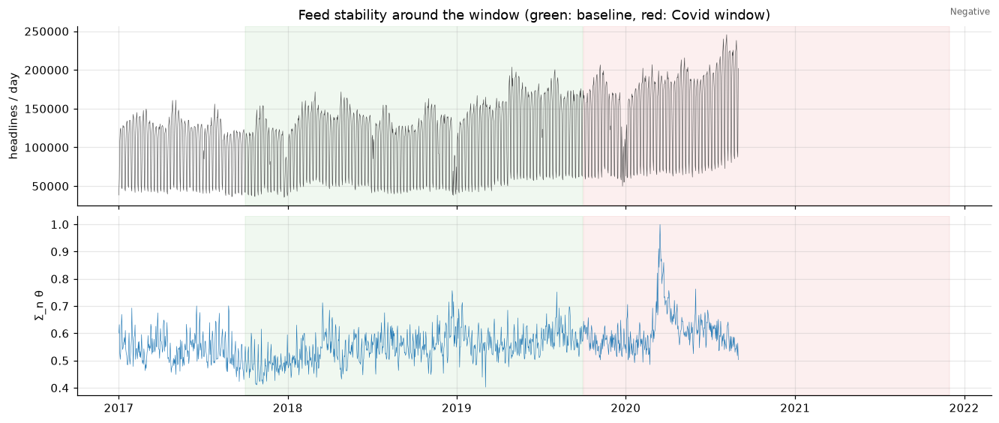

Y,headlines/day,mean Σθ
i32,f64,f64
2017,98757.0,0.527
2018,106540.0,0.549
2019,128253.0,0.573
2020,152220.0,0.618


In [23]:
flow = (daily.filter(pl.col("DATE").is_between(date(2017, 1, 1), VIEW[1]))
        .group_by("DATE").agg(pl.col("N_HEADLINES").first(), pl.col("THETA").sum().alias("SUM_THETA"))
        .sort("DATE"))
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(flow["DATE"], flow["N_HEADLINES"], lw=0.4, color="0.3"); axes[0].set_ylabel("headlines / day")
axes[1].plot(flow["DATE"], flow["SUM_THETA"], lw=0.4, color="tab:blue"); axes[1].set_ylabel("Σ_n θ")
for ax in axes:
    ax.axvspan(*WINDOW, color="tab:red", alpha=0.07); ax.axvspan(*BASELINE, color="tab:green", alpha=0.07)
axes[0].set_title("Feed stability around the window (green: baseline, red: Covid window)")
plt.show()
yr = (flow.with_columns(pl.col("DATE").dt.year().alias("Y")).group_by("Y")
      .agg(pl.col("N_HEADLINES").mean().round(0).alias("headlines/day"),
           pl.col("SUM_THETA").mean().round(3).alias("mean Σθ")).sort("Y"))
yr

## B.2. Post-processing pipeline (stages 1–5)


In [24]:
def deseasonalise(daily: pl.DataFrame, min_prior_years: int = MIN_PRIOR_YEARS,
                  seasonal_years: int | None = SEASONAL_YEARS) -> pl.DataFrame:
    # stage 1: subtract the prior-years-only week-of-year mean (expanding, or trailing N years)
    d = daily.with_columns(pl.col("DATE").dt.iso_year().alias("YEAR"),
                           pl.col("DATE").dt.week().clip(1, 52).alias("WOY"))
    yw = (d.group_by(KEY, "YEAR", "WOY").agg(pl.col("THETA").mean().alias("YW_MEAN"))
          .sort(KEY, "WOY", "YEAR")
          .with_columns(pl.col("YW_MEAN").is_not_null().cast(pl.Int32).alias("_has"),
                        pl.col("YW_MEAN").fill_null(0.0).alias("_v")))
    if seasonal_years is None:
        yw = yw.with_columns(pl.col("_v").cum_sum().shift(1).over(KEY, "WOY").alias("_psum"),
                             pl.col("_has").cum_sum().shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
    else:
        n = int(seasonal_years)
        yw = yw.with_columns(
            pl.col("_v").rolling_sum(n, min_samples=1).shift(1).over(KEY, "WOY").alias("_psum"),
            pl.col("_has").rolling_sum(n, min_samples=1).shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
    yw = (yw.with_columns(pl.when(pl.col("N_PRIOR_YEARS") >= min_prior_years)
                          .then(pl.col("_psum") / pl.col("N_PRIOR_YEARS")).otherwise(None).alias("SEAS"))
          .select(KEY, "YEAR", "WOY", "SEAS", "N_PRIOR_YEARS"))
    return (d.join(yw, on=[KEY, "YEAR", "WOY"], how="left")
            .with_columns((pl.col("THETA") - pl.col("SEAS")).alias("THETA_DS")))


def weekly(d: pl.DataFrame) -> pl.DataFrame:
    # stage 2: Mon-Fri mean, stamped on the Friday, on a complete (week x key) grid
    w = (d.filter(pl.col("DATE").dt.weekday() <= 5)
         .with_columns((pl.col("DATE").dt.truncate("1w") + timedelta(days=4)).alias("WEEK"))
         .group_by(KEY, "WEEK")
         .agg(pl.col("THETA_DS").mean().alias("THETA_W"), pl.col("THETA").mean().alias("THETA_RAW_W"),
              pl.col("THETA").count().alias("N_DAYS")))
    grid = pl.DataFrame({"WEEK": pl.date_range(w["WEEK"].min(), w["WEEK"].max(), "1w", eager=True)}).join(
        w.select(KEY).unique(), how="cross")
    return grid.join(w, on=[KEY, "WEEK"], how="left").sort(KEY, "WEEK")


def changes_and_horizons(w: pl.DataFrame, value: str = "THETA_W", horizons=ALL_H) -> pl.DataFrame:
    # stage 3 (first difference) + stage 4 (backward rolling mean over h weeks, full windows only)
    w = w.with_columns(pl.col(value).diff().over(KEY).alias("DTHETA"))
    return w.with_columns([pl.col("DTHETA").rolling_mean(h, min_samples=h).over(KEY).alias(f"D{h}")
                           for h in horizons])


def composite(w: pl.DataFrame, all_h=ALL_H) -> pl.DataFrame:
    # stage 5: each horizon / its own cross-sectional std (ddof=0, NOT demeaned), averaged over H
    w = w.with_columns([(pl.col(f"D{h}") / pl.col(f"D{h}").std(ddof=0).over("WEEK")).alias(f"Z{h}")
                        for h in all_h])

    def avg(hs, name):
        z = [pl.col(f"Z{h}") for h in hs]
        ok = pl.all_horizontal([c.is_not_null() & c.is_finite() for c in z])
        return pl.when(ok).then(pl.sum_horizontal(z) / len(z)).otherwise(None).alias(name)

    return w.with_columns(avg(COMPOSITE_H, "COMPOSITE"), avg(COMPOSITE_SHORT_H, "COMPOSITE_S"))


def post_process(daily: pl.DataFrame, deseason: bool = True, seasonal_years=SEASONAL_YEARS) -> pl.DataFrame:
    d = (deseasonalise(daily, seasonal_years=seasonal_years) if deseason
         else daily.with_columns(pl.col("THETA").alias("THETA_DS")))
    return composite(changes_and_horizons(weekly(d)))


daily_ds = deseasonalise(daily)
panel = composite(changes_and_horizons(weekly(daily_ds)))
print(f"{panel.height:,} (week x narrative) rows | weeks {panel['WEEK'].min()} .. {panel['WEEK'].max()}")
cs = panel.filter(pl.col("COMPOSITE").is_not_null())
for h in COMPOSITE_H:
    s = cs.group_by("WEEK").agg(pl.col(f"Z{h}").std(ddof=0))[f"Z{h}"]
    assert np.allclose(s.to_numpy(), 1.0, atol=1e-6), h
print("σ^(h) normalisation holds; window weeks with a composite:",
      cs.filter(pl.col("WEEK").is_between(*VIEW))["WEEK"].n_unique())

392,288 (week x narrative) rows | weeks 2000-04-07 .. 2020-09-04
σ^(h) normalisation holds; window weeks with a composite: 49


### B.2.1 Stage-by-stage walk-through on the pandemic narrative


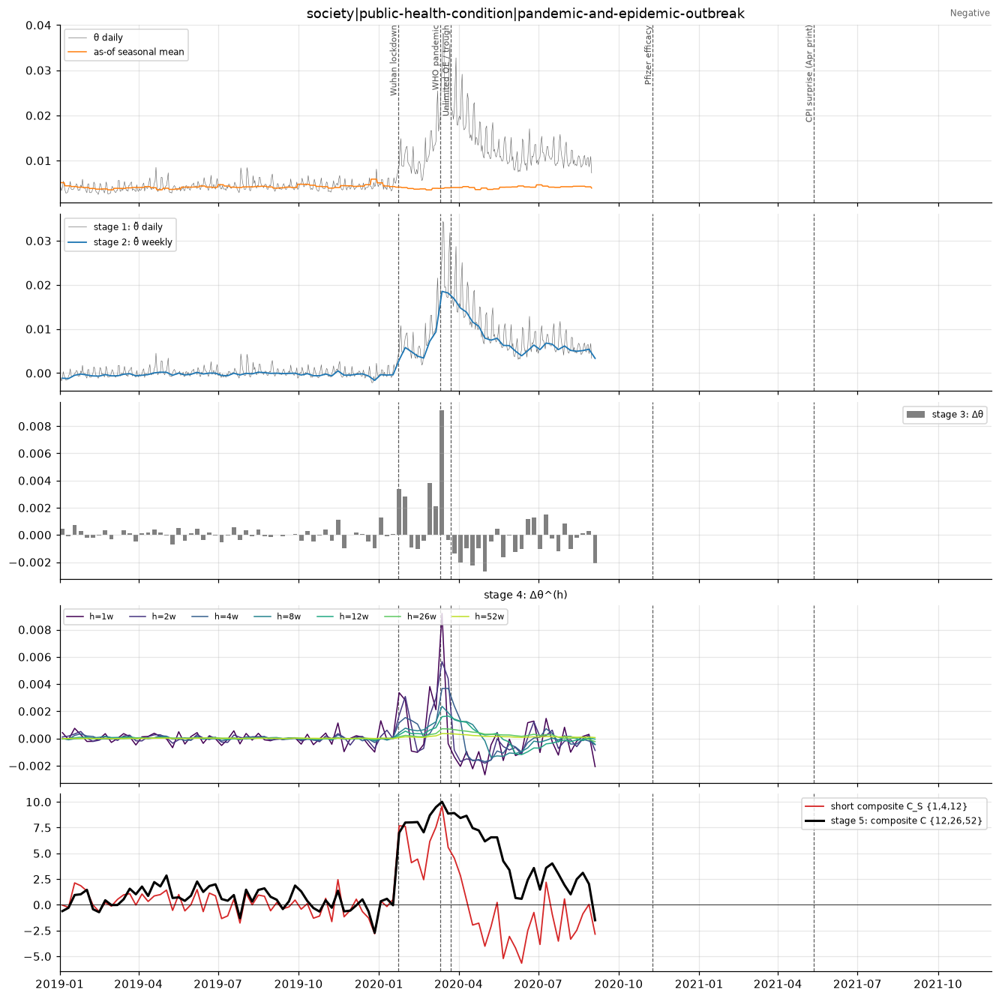

In [25]:
k0 = NAME_TO_KEYS[SHOWCASE][0]
lo = date(2019, 1, 1)
dd = daily_ds.filter((pl.col(KEY) == k0) & pl.col("DATE").is_between(lo, VIEW[1]))
pp = panel.filter((pl.col(KEY) == k0) & pl.col("WEEK").is_between(lo, VIEW[1]))

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(dd["DATE"], dd["THETA"], lw=0.4, color="0.4", label="θ daily")
axes[0].plot(dd["DATE"], dd["SEAS"], lw=1.0, color="tab:orange", label="as-of seasonal mean")
axes[0].set_title(k0); axes[0].legend(loc="upper left", fontsize=8)
axes[1].plot(dd["DATE"], dd["THETA_DS"], lw=0.4, color="0.4", label="stage 1: θ̃ daily")
axes[1].plot(pp["WEEK"], pp["THETA_W"], lw=1.2, color="tab:blue", label="stage 2: θ̄ weekly")
axes[1].legend(loc="upper left", fontsize=8)
axes[2].bar(pp["WEEK"], pp["DTHETA"], width=5, color="0.5", label="stage 3: Δθ"); axes[2].legend(fontsize=8)
for h, c in zip(ALL_H, plt.cm.viridis(np.linspace(0, 0.9, len(ALL_H)))):
    axes[3].plot(pp["WEEK"], pp[f"D{h}"], lw=1.0, color=c, label=f"h={h}w")
axes[3].set_title("stage 4: Δθ^(h)", fontsize=9); axes[3].legend(ncol=len(ALL_H), fontsize=7, loc="upper left")
axes[4].plot(pp["WEEK"], pp["COMPOSITE_S"], lw=1.2, color="tab:red", label="short composite C_S {1,4,12}")
axes[4].plot(pp["WEEK"], pp["COMPOSITE"], lw=2.0, color="k", label="stage 5: composite C {12,26,52}")
axes[4].axhline(0, color="k", lw=0.5); axes[4].legend(fontsize=8, loc="upper right")
for ax in axes:
    date_axis(ax, lo, VIEW[1]); shade_events(ax, labels=ax is axes[0])
plt.show()

## B.3. Composite properties over the window


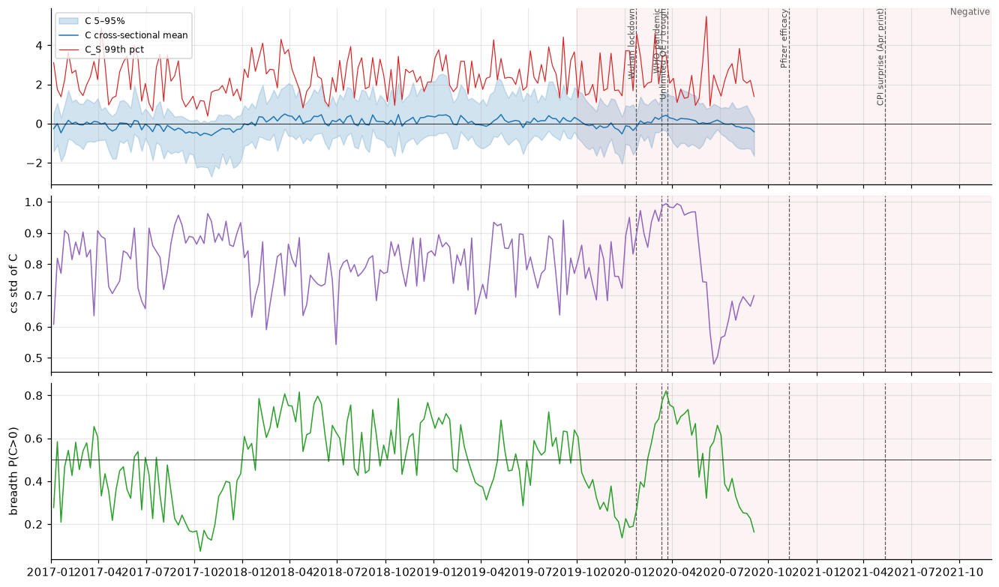

In [26]:
xs = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(date(2017, 1, 1), VIEW[1]))
      .group_by("WEEK")
      .agg(pl.col("COMPOSITE").mean().alias("MEAN"), pl.col("COMPOSITE").std(ddof=0).alias("STD"),
           (pl.col("COMPOSITE") > 0).mean().alias("BREADTH"),
           pl.col("COMPOSITE").quantile(0.95).alias("Q95"), pl.col("COMPOSITE").quantile(0.05).alias("Q05"),
           pl.col("COMPOSITE_S").quantile(0.99).alias("QS99"))
      .sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].fill_between(xs["WEEK"], xs["Q05"], xs["Q95"], color="tab:blue", alpha=0.2, label="C 5–95%")
axes[0].plot(xs["WEEK"], xs["MEAN"], color="tab:blue", lw=1, label="C cross-sectional mean")
axes[0].plot(xs["WEEK"], xs["QS99"], color="tab:red", lw=0.8, label="C_S 99th pct")
axes[0].axhline(0, color="k", lw=0.5); axes[0].legend(fontsize=8, loc="upper left")
axes[1].plot(xs["WEEK"], xs["STD"], color="tab:purple", lw=1); axes[1].set_ylabel("cs std of C")
axes[2].plot(xs["WEEK"], xs["BREADTH"], color="tab:green", lw=1); axes[2].axhline(0.5, color="k", lw=0.5)
axes[2].set_ylabel("breadth P(C>0)")
for ax in axes:
    date_axis(ax, date(2017, 1, 1), VIEW[1]); ax.axvspan(*WINDOW, color="tab:red", alpha=0.05)
    shade_events(ax, labels=ax is axes[0])
plt.show()

## B.4. Predeclared Covid batteries


In [27]:
name_to_keys = NAME_TO_KEYS     # narrative names, pole names mapped to their merged narrative
print("pole entries (now the whole merged narrative):",
      {b: pole_entries(ns) for b, ns in BATTERIES.items() if pole_entries(ns)})
_placebo = {k for n in BATTERIES[PLACEBO] for k in NAME_TO_KEYS.get(n, [])}
_stress = {k for b, ns in BATTERIES.items() if b != PLACEBO for n in ns for k in NAME_TO_KEYS.get(n, [])}
assert not _placebo & _stress, f"placebo shares merged narratives with other batteries: {sorted(_placebo & _stress)}"
BATTERIES_STUDY = {b: ns + PLACEBO_BY_STUDY.get(STUDY, []) if b == PLACEBO else ns
                   for b, ns in BATTERIES.items()}
if PLACEBO_BY_STUDY.get(STUDY):
    print(f"{STUDY}: placebo adds {PLACEBO_BY_STUDY[STUDY]} (this study only; same merged "
          f"narratives as stress entries, read on the {'+'.join(STUDIES[STUDY])} label)")
BKEYS = {}
for b, names in BATTERIES_STUDY.items():
    missing = [n for n in names if n not in name_to_keys]
    if missing:
        print(f"[{b}] names not in the taxonomy: {missing}")
    BKEYS[b] = list(dict.fromkeys(k for n in names for k in name_to_keys.get(n, [])))   # two poles of one pair: one merged key
print({b: len(k) for b, k in BKEYS.items()})
blist = [b for b in BKEYS if BKEYS[b]]


def battery_frame(panel, col, bkeys):
    wide = panel.filter(pl.col(col).is_not_null()).pivot(on=KEY, index="WEEK", values=col).sort("WEEK")
    m = wide.drop("WEEK")
    return wide["WEEK"], m, pl.DataFrame({"WEEK": wide["WEEK"], **{
        b: np.nanmean(m.select([k for k in ks if k in m.columns]).to_numpy(), axis=1)
        for b, ks in bkeys.items() if ks}})


WEEKS, C, bat = battery_frame(panel, "COMPOSITE", BKEYS)
WEEKS_S, CS, bat_s = battery_frame(panel, "COMPOSITE_S", BKEYS)
base = bat.filter(pl.col("WEEK").is_between(*BASELINE))
batz = bat.with_columns([((pl.col(b) - base[b].mean()) / base[b].std()).alias(b) for b in blist])
v = bat.filter(pl.col("WEEK").is_between(*VIEW)); v_s = bat_s.filter(pl.col("WEEK").is_between(*VIEW))
print(f"baseline {BASELINE[0]} .. {BASELINE[1]}: {base.height} weeks")

pole entries (now the whole merged narrative): {'health shock': ['public-health-deterioration'], 'lockdown / state control': ['state-direction-expansion'], 'monetary response': ['balance-sheet-expansion', 'global-liquidity-easing'], 'real contraction': ['business-cycle-contraction', 'labour-market-slackening', 'guidance-cut', 'dividend-cut'], 'corporate distress': ['credit-deterioration', 'rating-downgrade'], 'oil / demand collapse': ['demand-destruction', 'demand-driven-price-collapse', 'curve-contango'], 'vaccine / health recovery': ['public-health-improvement'], 'reopening / recovery': ['business-cycle-expansion', 'capex-upswing'], 'reflation / inflation': ['price-level-change-reflation', 'labour-market-tightening', 'input-cost-squeeze'], 'PLACEBO (orthogonal)': ['allowance-cap-tightening', 'allowance-cap-loosening']}
{'health shock': 3, 'lockdown / state control': 3, 'market crash': 7, 'dash for cash / funding': 7, 'monetary response': 7, 'fiscal response': 4, 'real contraction': 7

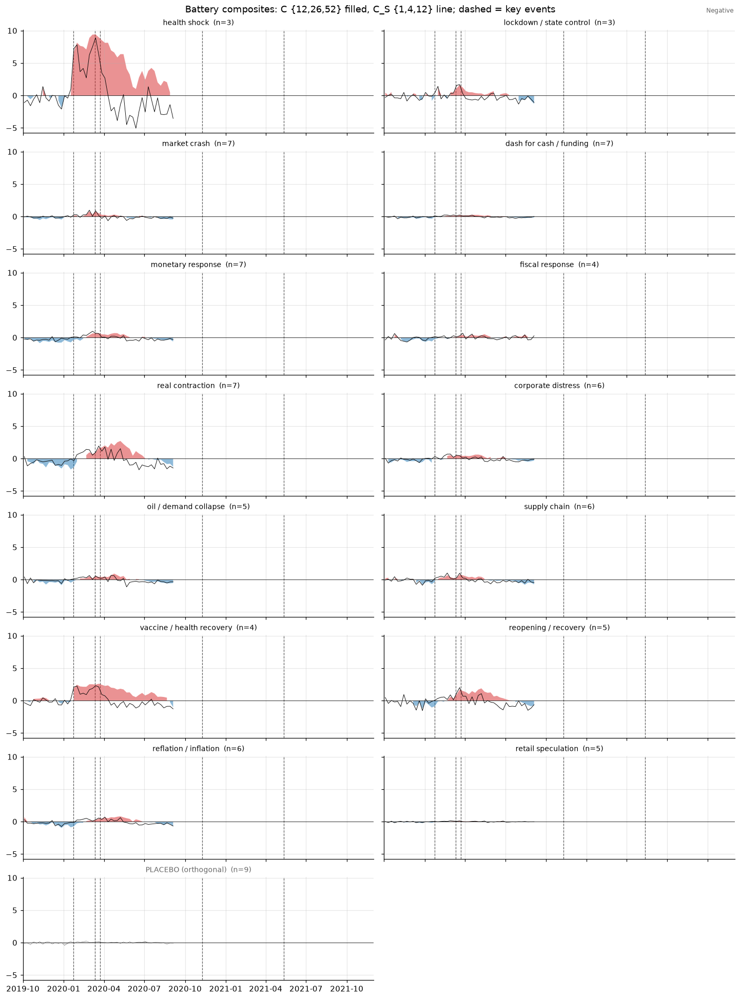

In [28]:
ncol = 2
nrow = int(np.ceil(len(blist) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.2 * nrow), sharex=True, sharey=True)
for ax, b in zip(axes.flat, blist):
    y = v[b].to_numpy()
    diag = b in DIAGNOSTIC
    ax.fill_between(v["WEEK"], 0, y, where=y > 0, color="0.6" if diag else "tab:red", alpha=0.5, lw=0)
    ax.fill_between(v["WEEK"], 0, y, where=y < 0, color="0.8" if diag else "tab:blue", alpha=0.5, lw=0)
    ax.plot(v_s["WEEK"], v_s[b], color="k", lw=0.6, ls=":" if diag else "-", label="C_S")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{b}  (n={len(BKEYS[b])})", fontsize=9, color="0.4" if diag else "k")
    date_axis(ax)
for ax in axes.flat[len(blist):]:
    ax.axis("off")
for ax in axes.flat[:len(blist)]:
    shade_events(ax, labels=False)
fig.suptitle("Battery composites: C {12,26,52} filled, C_S {1,4,12} line; dashed = key events")
plt.show()

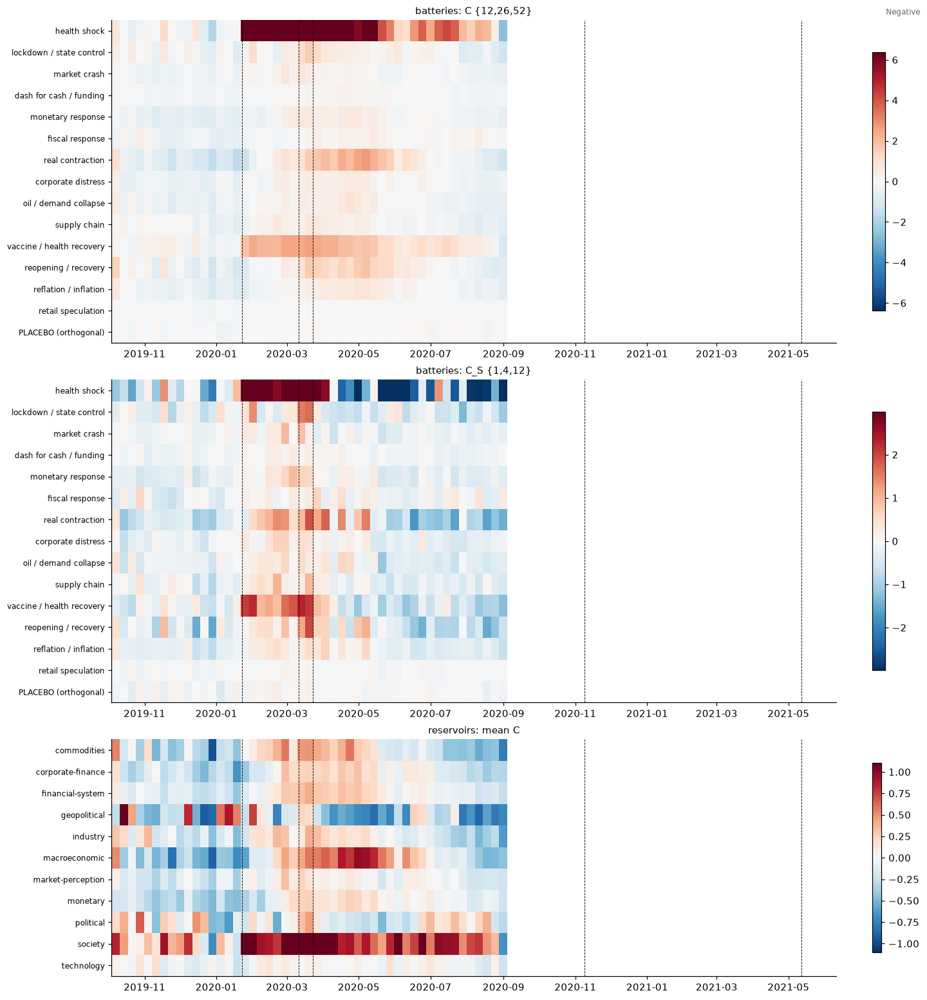

In [29]:
def heat(ax, frame, rows, title, vmax=None):
    m = frame.select(rows).to_numpy().T
    vmax = vmax or np.nanpercentile(np.abs(m), 98)
    x = mdates.date2num(frame["WEEK"].to_list())
    im = ax.imshow(m, aspect="auto", cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax),
                   extent=[x[0], x[-1], len(rows) - 0.5, -0.5], interpolation="nearest")
    ax.set_yticks(range(len(rows)), rows, fontsize=8); ax.xaxis_date(); ax.grid(False)
    for name in KEY_EVENTS:
        ax.axvline(EVENTS[name], color="k", lw=0.6, ls="--")
    ax.set_title(title, fontsize=10)
    return im


res = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(*VIEW))
       .join(NARR.select(KEY, "reservoir"), on=KEY)
       .group_by("WEEK", "reservoir").agg(pl.col("COMPOSITE").mean())
       .pivot(on="reservoir", index="WEEK", values="COMPOSITE").sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(13, 14), height_ratios=[len(blist), len(blist), res.width - 1])
fig.colorbar(heat(axes[0], v, blist, "batteries: C {12,26,52}"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], v_s, blist, "batteries: C_S {1,4,12}"), ax=axes[1], shrink=0.8)
fig.colorbar(heat(axes[2], res, sorted(res.columns[1:]), "reservoirs: mean C"), ax=axes[2], shrink=0.8)
plt.show()

### B.4.1 Event table: permutation test and block-bootstrap baseline band


In [30]:
wk_arr = np.array(WEEKS.to_list())
col_of = {k: i for i, k in enumerate(C.columns)}
Cn = C.to_numpy()


def event_week(d):
    return min(int(np.searchsorted(wk_arr, d)), len(wk_arr) - 1)


def perm_p(row, idx, n_perm=N_PERM):
    # vectorised: n_perm random subsets of size k without replacement (argpartition of uniforms)
    x = row[~np.isnan(row)]
    obs = np.nanmean(row[idx])
    k = len(idx)
    pick = np.argpartition(RNG.random((n_perm, len(x))), k, axis=1)[:, :k]
    draws = x[pick].mean(axis=1)
    return obs, (1 + (draws >= obs).sum()) / (n_perm + 1)


def boot_block_max(series, n_boot=N_BOOT, block=BLOCK_WEEKS):
    # distribution of the max of one block drawn from the baseline series (moving-block bootstrap)
    s = series[~np.isnan(series)]
    starts = RNG.integers(0, len(s) - block + 1, n_boot)
    return np.array([s[i:i + block].max() for i in starts])


boot = {b: boot_block_max(base[b].to_numpy()) for b in blist}
rows = []
for ev, d in EVENTS.items():
    if not (VIEW[0] <= d <= VIEW[1]):
        continue
    i = event_week(d)
    i_s = min(int(np.searchsorted(np.array(WEEKS_S.to_list()), d)), bat_s.height - 1)
    for b in blist:
        idx = np.array([col_of[k] for k in BKEYS[b] if k in col_of])
        obs, p = perm_p(Cn[i], idx)
        rows.append({"event": ev, "week": wk_arr[i], "battery": b, "C": obs, "C_S": bat_s[b][i_s],
                     "z_vs_baseline": batz[b][i], "perm_p": p,
                     "boot_p": (1 + (boot[b] >= obs).sum()) / (N_BOOT + 1)})
ev_tab = pl.DataFrame(rows)
for col, dig in (("C", 2), ("C_S", 2), ("perm_p", 3), ("boot_p", 3)):
    print(col)
    display(ev_tab.pivot(on="event", index="battery", values=col).with_columns(pl.selectors.float().round(dig)))

C


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",-0.23,6.75,8.89,9.39,9.42,8.98,8.52,8.52,6.63,-2.67,-2.67,-2.67,-2.67,-2.67,-2.67
"""lockdown / state control""",0.24,-0.18,0.52,0.44,1.11,1.62,1.23,1.23,0.37,-1.29,-1.29,-1.29,-1.29,-1.29,-1.29
"""market crash""",-0.08,0.14,0.78,0.33,0.76,0.51,0.25,0.25,0.29,-0.45,-0.45,-0.45,-0.45,-0.45,-0.45
"""dash for cash / funding""",-0.09,-0.06,0.06,0.13,0.11,0.19,0.17,0.17,0.24,-0.16,-0.16,-0.16,-0.16,-0.16,-0.16
"""monetary response""",-0.4,-0.34,0.37,0.63,0.66,0.67,0.48,0.48,0.68,-0.61,-0.61,-0.61,-0.61,-0.61,-0.61
"""fiscal response""",-0.66,-0.22,-0.11,0.07,0.05,0.26,0.42,0.42,0.29,0.17,0.17,0.17,0.17,0.17,0.17
"""real contraction""",-0.89,-1.35,0.96,0.69,0.91,1.6,1.7,1.7,2.0,-1.28,-1.28,-1.28,-1.28,-1.28,-1.28
"""corporate distress""",-0.12,0.04,0.52,0.26,0.47,0.51,0.4,0.4,0.6,-0.32,-0.32,-0.32,-0.32,-0.32,-0.32
"""oil / demand collapse""",-0.19,-0.2,0.48,0.21,0.49,0.41,0.39,0.39,0.91,-0.55,-0.55,-0.55,-0.55,-0.55,-0.55


C_S


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",-0.03,7.23,6.27,7.5,8.91,6.33,3.49,3.49,-1.83,-3.55,-3.55,-3.55,-3.55,-3.55,-3.55
"""lockdown / state control""",0.47,0.41,0.29,0.37,1.55,1.67,0.29,0.29,-0.6,-1.09,-1.09,-1.09,-1.09,-1.09,-1.09
"""market crash""",-0.0,0.28,0.97,0.02,0.89,0.16,-0.3,-0.3,0.15,-0.25,-0.25,-0.25,-0.25,-0.25,-0.25
"""dash for cash / funding""",-0.02,0.1,0.11,0.24,0.11,0.22,0.08,0.08,0.01,0.02,0.02,0.02,0.02,0.02,0.02
"""monetary response""",-0.22,0.11,0.64,0.96,0.66,0.61,0.04,0.04,0.19,-0.34,-0.34,-0.34,-0.34,-0.34,-0.34
"""fiscal response""",-0.49,0.15,-0.02,0.27,0.1,0.26,0.66,0.66,-0.25,0.26,0.26,0.26,0.26,0.26,0.26
"""real contraction""",-0.41,-0.34,1.35,0.51,0.95,1.93,1.13,1.13,-0.3,-1.46,-1.46,-1.46,-1.46,-1.46,-1.46
"""corporate distress""",0.02,0.31,0.69,0.18,0.51,0.44,0.07,0.07,0.24,-0.11,-0.11,-0.11,-0.11,-0.11,-0.11
"""oil / demand collapse""",0.13,0.11,0.62,0.03,0.55,0.27,0.17,0.17,0.58,-0.35,-0.35,-0.35,-0.35,-0.35,-0.35


perm_p


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
"""lockdown / state control""",0.125,0.459,0.181,0.123,0.042,0.028,0.033,0.033,0.296,0.968,0.968,0.967,0.968,0.967,0.968
"""market crash""",0.326,0.124,0.074,0.158,0.076,0.267,0.458,0.456,0.374,0.587,0.593,0.587,0.586,0.588,0.586
"""dash for cash / funding""",0.33,0.252,0.816,0.55,0.822,0.764,0.608,0.608,0.444,0.117,0.12,0.116,0.116,0.117,0.119
"""monetary response""",0.864,0.716,0.293,0.057,0.099,0.144,0.174,0.173,0.092,0.8,0.792,0.794,0.794,0.796,0.795
"""fiscal response""",0.963,0.511,0.928,0.661,0.834,0.587,0.251,0.251,0.37,0.024,0.023,0.025,0.024,0.023,0.023
"""real contraction""",1.0,1.0,0.061,0.056,0.06,0.026,0.009,0.008,0.001,0.996,0.997,0.996,0.997,0.996,0.997
"""corporate distress""",0.371,0.166,0.164,0.265,0.228,0.263,0.25,0.251,0.126,0.37,0.372,0.366,0.375,0.372,0.37
"""oil / demand collapse""",0.504,0.482,0.199,0.357,0.224,0.381,0.266,0.267,0.057,0.703,0.703,0.703,0.7,0.7,0.701


boot_p


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.937,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
"""lockdown / state control""",0.82,1.0,0.711,0.786,0.417,0.174,0.259,0.259,0.796,1.0,1.0,1.0,1.0,1.0,1.0
"""market crash""",0.957,0.821,0.089,0.685,0.089,0.453,0.685,0.685,0.685,1.0,1.0,1.0,1.0,1.0,1.0
"""dash for cash / funding""",1.0,0.973,0.78,0.736,0.736,0.658,0.715,0.715,0.616,1.0,1.0,1.0,1.0,1.0,1.0
"""monetary response""",1.0,1.0,0.821,0.575,0.575,0.575,0.699,0.699,0.575,1.0,1.0,1.0,1.0,1.0,1.0
"""fiscal response""",1.0,1.0,0.968,0.838,0.838,0.763,0.621,0.621,0.763,0.822,0.822,0.822,0.822,0.822,0.822
"""real contraction""",1.0,1.0,0.722,0.744,0.744,0.234,0.234,0.234,0.0,1.0,1.0,1.0,1.0,1.0,1.0
"""corporate distress""",0.961,0.785,0.517,0.678,0.545,0.517,0.61,0.61,0.451,1.0,1.0,1.0,1.0,1.0,1.0
"""oil / demand collapse""",1.0,1.0,0.644,0.731,0.644,0.682,0.682,0.682,0.106,1.0,1.0,1.0,1.0,1.0,1.0


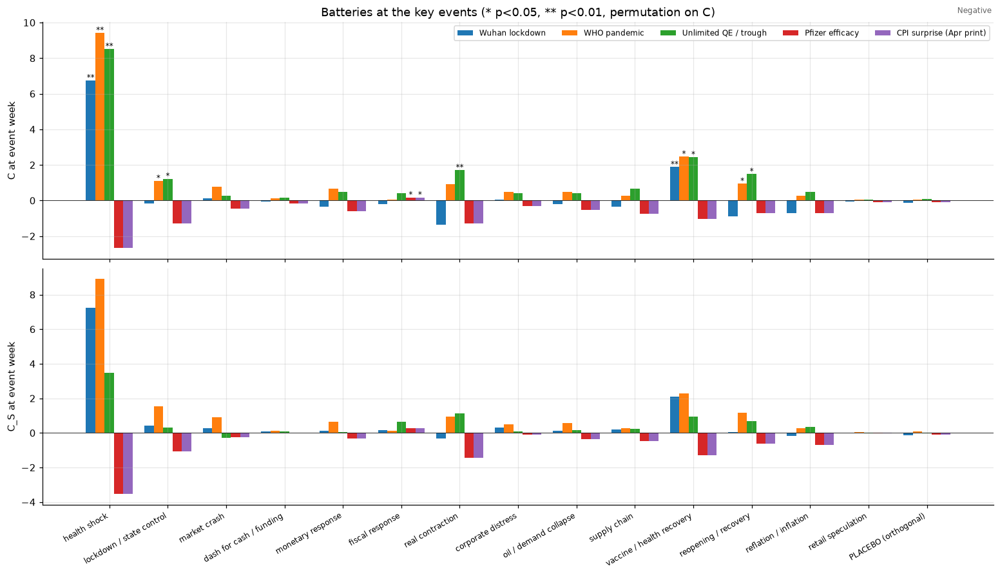

In [31]:
pz = ev_tab.filter(pl.col("event").is_in(list(KEY_EVENTS)))
evs = [e for e in KEY_EVENTS if e in pz["event"].unique().to_list()]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, col in zip(axes, ("C", "C_S")):
    wbar = 0.8 / max(len(evs), 1)
    for j, e in enumerate(evs):
        g = pz.filter(pl.col("event") == e).sort(pl.col("battery").replace_strict({b: i for i, b in enumerate(blist)}))
        xs_ = np.arange(len(blist)) + j * wbar
        ax.bar(xs_, g[col], width=wbar, label=e)
        if col == "C":
            for x_, c_, p_ in zip(xs_, g["C"], g["perm_p"]):
                if p_ < 0.05:
                    ax.text(x_, c_ + (0.03 if c_ >= 0 else -0.12), "*" if p_ >= 0.01 else "**",
                            ha="center", fontsize=8)
    ax.axhline(0, color="k", lw=0.5); ax.set_ylabel(f"{col} at event week")
axes[1].set_xticks(np.arange(len(blist)) + 0.4 - wbar / 2, blist, rotation=30, ha="right", fontsize=8)
axes[0].legend(fontsize=8, ncol=len(evs)); axes[0].set_title("Batteries at the key events (* p<0.05, ** p<0.01, permutation on C)")
plt.show()

## B.5. Horizon term structure at the key events


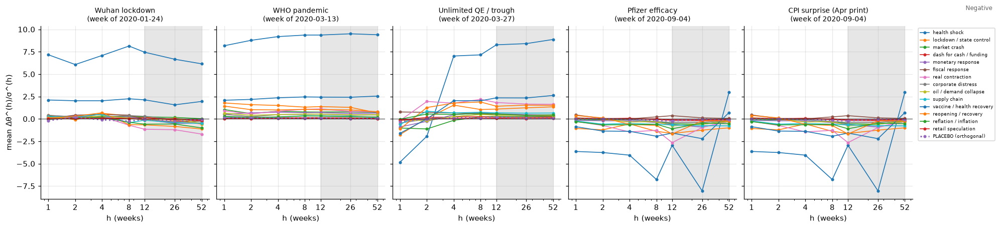

In [32]:
term = panel.select("WEEK", KEY, *[f"Z{h}" for h in ALL_H])
fig, axes = plt.subplots(1, len(KEY_EVENTS), figsize=(18, 4), sharey=True)
for ax, e in zip(axes, KEY_EVENTS):
    wk = wk_arr[event_week(EVENTS[e])]
    t = term.filter(pl.col("WEEK") == wk)
    for b in blist:
        g = t.filter(pl.col(KEY).is_in(BKEYS[b])).select([pl.col(f"Z{h}").mean() for h in ALL_H]).row(0)
        diag = b in DIAGNOSTIC
        ax.plot(ALL_H, g, marker="o", ms=3, lw=2 if diag else 1.1, ls=":" if diag else "-", label=b)
    ax.axhline(0, color="k", lw=0.5); ax.set_xscale("log"); ax.set_xticks(ALL_H, [str(h) for h in ALL_H])
    ax.axvspan(min(COMPOSITE_H), max(COMPOSITE_H), color="0.9", zorder=0)
    ax.set_title(f"{e}\n(week of {wk})", fontsize=9); ax.set_xlabel("h (weeks)")
axes[0].set_ylabel("mean Δθ^(h)/σ^(h)")
axes[-1].legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## B.6. Unsupervised cross-sections


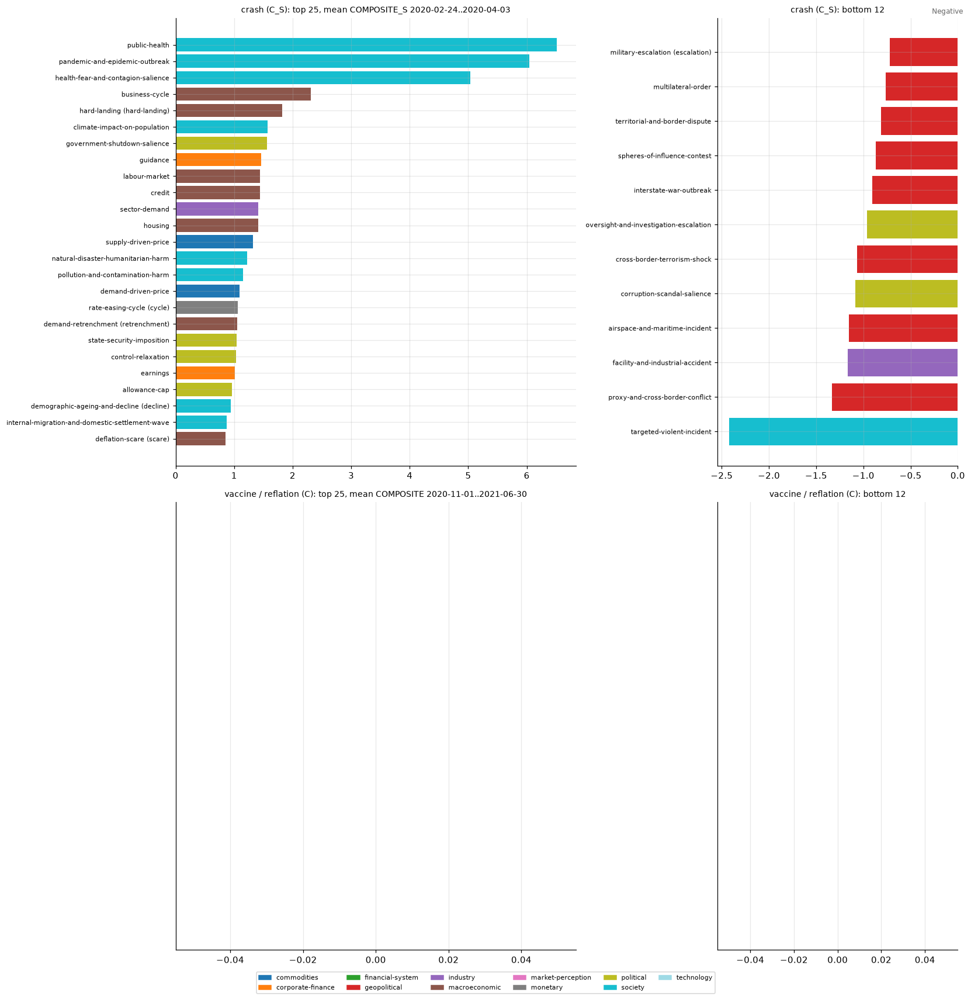

In [34]:
resv = sorted(NARR["reservoir"].unique().to_list())
cmap = dict(zip(resv, plt.cm.tab20(np.linspace(0, 1, len(resv)))))
in_b = {k for b in blist if b not in DIAGNOSTIC for k in BKEYS[b]}


def ranked(col, lo, hi):
    return (panel.filter(pl.col("WEEK").is_between(lo, hi) & pl.col(col).is_not_null())
            .group_by(KEY).agg(pl.col(col).mean().alias("V")).join(NARR, on=KEY).sort("V", descending=True))


def barplot(ax, t, title):
    lab = [f"{r['narrative']} ({r['pole']})" if r["pole"] else r["narrative"] for r in t.iter_rows(named=True)]
    ax.barh(range(t.height), t["V"], color=[cmap[r] for r in t["reservoir"]])
    ax.set_yticks(range(t.height), lab, fontsize=7); ax.invert_yaxis(); ax.set_title(title, fontsize=9)


phases = {"crash (C_S)": ("COMPOSITE_S", date(2020, 2, 24), date(2020, 4, 3)),
          "vaccine / reflation (C)": ("COMPOSITE", date(2020, 11, 1), date(2021, 6, 30))}
fig, axes = plt.subplots(2, 2, figsize=(15, 15), width_ratios=[5, 3])
for row, (name, (col, lo, hi)) in enumerate(phases.items()):
    r = ranked(col, lo, hi)
    barplot(axes[row, 0], r.head(25), f"{name}: top 25, mean {col} {lo}..{hi}")
    barplot(axes[row, 1], r.tail(12), f"{name}: bottom 12")
    # print(f"{name}: battery narratives among top 25 = {r.head(25).filter(pl.col(KEY).is_in(in_b)).height} "
    #       f"(chance ≈ {25 * len(in_b) / r.height:.1f})")
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[r]) for r in resv]
fig.legend(handles, resv, fontsize=7, loc="lower center", ncol=min(6, len(resv)), bbox_to_anchor=(0.5, -0.03))
plt.show()

## B.7. Narrative waves: onset and peak timing


battery,onset_CS,peak_C,max_C,max_CS,weeks_CS_lit
str,date,date,f64,f64,i64
"""market crash""",null,2020-02-28,0.78,0.97,0
"""health shock""",2019-11-15,2020-03-13,9.42,8.91,13
"""lockdown / state control""",2020-01-31,2020-03-20,1.62,1.67,3
"""supply chain""",2020-02-21,2020-03-20,0.74,1.01,1
"""vaccine / health recovery""",2020-01-24,2020-03-20,2.59,2.29,7
"""dash for cash / funding""",null,2020-04-17,0.27,0.24,0
"""monetary response""",null,2020-04-24,0.68,0.96,0
"""oil / demand collapse""",null,2020-04-24,0.91,0.65,0
"""retail speculation""",null,2020-04-24,0.08,0.12,0


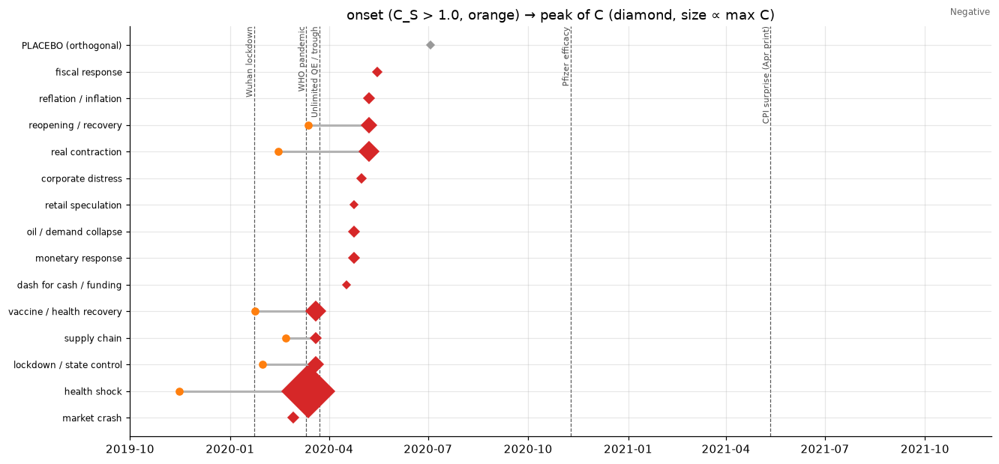

In [35]:
win = v.join(v_s, on="WEEK", suffix="_S")
wv = []
for b in blist:
    ys = win[f"{b}_S"].to_numpy(); y = win[b].to_numpy()
    on = np.flatnonzero(ys > ONSET_THRESHOLD)
    wv.append({"battery": b, "onset_CS": win["WEEK"][int(on[0])] if on.size else None,
               "peak_C": win["WEEK"][int(np.nanargmax(y))], "max_C": float(np.nanmax(y)),
               "max_CS": float(np.nanmax(ys)), "weeks_CS_lit": int(on.size)})
waves = pl.DataFrame(wv).sort("peak_C")
display(waves.with_columns(pl.selectors.float().round(2)))

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, r in enumerate(waves.iter_rows(named=True)):
    col = "0.6" if r["battery"] in DIAGNOSTIC else "tab:red"
    if r["onset_CS"] is not None:
        ax.plot([r["onset_CS"], r["peak_C"]], [i, i], color="0.7", lw=2)
        ax.plot(r["onset_CS"], i, "o", color="tab:orange")
    ax.plot(r["peak_C"], i, "D", color=col, ms=4 + 3 * max(r["max_C"], 0))
ax.set_yticks(range(waves.height), waves["battery"], fontsize=8)
date_axis(ax); shade_events(ax)
ax.set_title(f"onset (C_S > {ONSET_THRESHOLD}, orange) → peak of C (diamond, size ∝ max C)")
plt.show()

In [36]:
# the leading narratives of each quarter (mean C), 2019Q4 .. end of window
q = (panel.filter(pl.col("WEEK").is_between(*VIEW) & pl.col("COMPOSITE").is_not_null())
     .with_columns(pl.col("WEEK").dt.truncate("1q").alias("Q"))
     .group_by("Q", KEY).agg(pl.col("COMPOSITE").mean())
     .join(NARR.select(KEY, "narrative", "pole"), on=KEY)
     .with_columns(pl.when(pl.col("pole").fill_null("") != "").then(pl.format("{} ({})", "narrative", "pole"))
                   .otherwise(pl.col("narrative")).alias("label"))
     .sort("Q", "COMPOSITE", descending=[False, True])
     .group_by("Q", maintain_order=True).head(5)
     .with_columns(pl.format("{} {}", pl.col("label"), pl.col("COMPOSITE").round(2)).alias("top"))
     .group_by("Q", maintain_order=True).agg(pl.col("top"))
     .with_columns(pl.col("Q").dt.strftime("%Y-%m"), *[pl.col("top").list.get(i, null_on_oob=True).alias(f"#{i+1}")
                                                       for i in range(5)])
     .drop("top"))
q

Q,#1,#2,#3,#4,#5
str,str,str,str,str,str
"""2019-10""","""civil-unrest-and-protest-wave 2.32""","""control-relaxation 1.47""","""crime-wave-and-security-deterioration 1.35""","""social-fracture-and-polarisation (polarisation) 1.22""","""military-escalation (escalation) 1.16"""
"""2020-01""","""public-health 7.08""","""pandemic-and-epidemic-outbreak 6.53""","""health-fear-and-contagion-salience 5.35""","""natural-disaster-humanitarian-harm 2.58""","""cross-border-terrorism-shock 2.03"""
"""2020-04""","""public-health 6.13""","""pandemic-and-epidemic-outbreak 5.07""","""health-fear-and-contagion-salience 3.73""","""business-cycle 3.39""","""hard-landing (hard-landing) 2.67"""
"""2020-07""","""health-fear-and-contagion-salience 2.14""","""pandemic-and-epidemic-outbreak 2.11""","""public-health 1.71""","""human-capital-erosion (erosion) 1.26""","""electoral-cycle-uncertainty 1.13"""


## B.8. Topic-level (direction-free) view


{'public health': 1, 'market volatility': 3, 'funding & plumbing': 3, 'monetary policy': 3, 'fiscal': 2, 'output & labour': 3, 'supply chain': 3, 'prices': 1, 'state control': 2, 'PLACEBO (orthogonal)': 3}


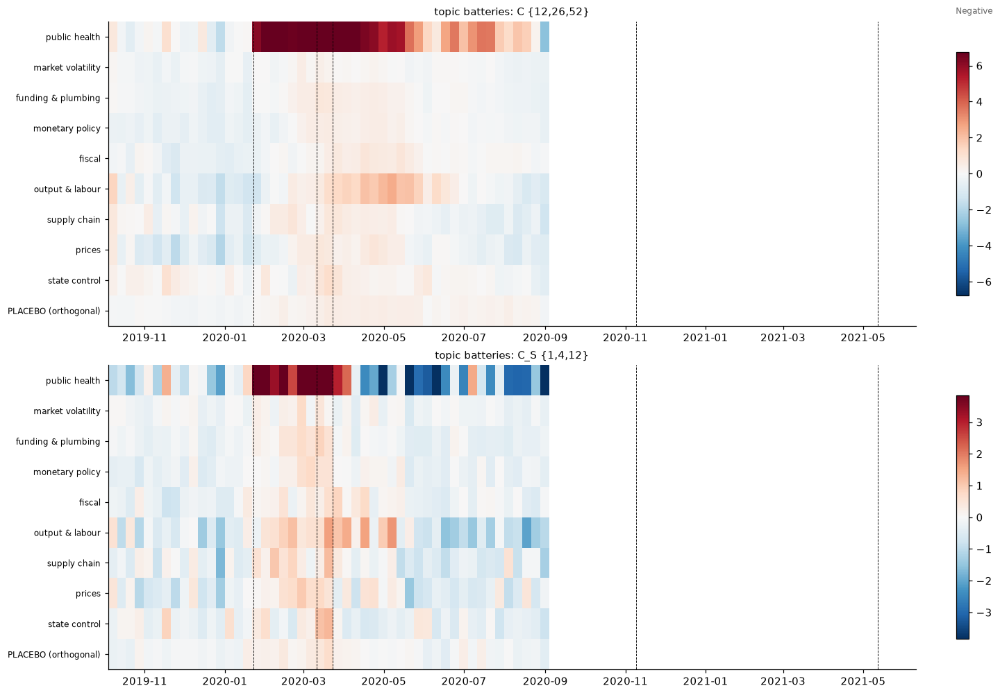

top / bottom dimensions in the crash (C_S) with their vaccine/reflation-phase C


narrative_key,C_S_crash,C_vaccine_reflation
str,f64,f64


In [37]:
topic_daily = (daily.group_by("DATE", "reservoir", "dimension")
               .agg(pl.col("THETA").sum(), pl.col("N_HEADLINES").first())
               .with_columns(pl.format("{}|{}", "reservoir", "dimension").alias(KEY)))
tpanel = post_process(topic_daily)
TKEYS = {b: [k for k in ks if k in set(tpanel[KEY].unique().to_list())] for b, ks in TOPIC_BATTERIES.items()}
print({b: len(k) for b, k in TKEYS.items()})
TW, TC, tbat = battery_frame(tpanel, "COMPOSITE", TKEYS)
_, _, tbat_s = battery_frame(tpanel, "COMPOSITE_S", TKEYS)
tv = tbat.filter(pl.col("WEEK").is_between(*VIEW)); tv_s = tbat_s.filter(pl.col("WEEK").is_between(*VIEW))
tlist = [b for b in TKEYS if TKEYS[b]]
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.colorbar(heat(axes[0], tv, tlist, "topic batteries: C {12,26,52}"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], tv_s, tlist, "topic batteries: C_S {1,4,12}"), ax=axes[1], shrink=0.8)
plt.show()

trank = (tpanel.filter(pl.col("WEEK").is_between(date(2020, 2, 24), date(2020, 4, 3)) & pl.col("COMPOSITE_S").is_not_null())
         .group_by(KEY).agg(pl.col("COMPOSITE_S").mean().alias("C_S_crash"))
         .join(tpanel.filter(pl.col("WEEK").is_between(date(2020, 11, 1), date(2021, 6, 30)))
               .group_by(KEY).agg(pl.col("COMPOSITE").mean().alias("C_vaccine_reflation")), on=KEY)
         .sort("C_S_crash", descending=True))
print("top / bottom dimensions in the crash (C_S) with their vaccine/reflation-phase C")
display(pl.concat([trank.head(12), trank.tail(6)]).with_columns(pl.selectors.float().round(2)))

## B.9. Robustness: stage-1 variants


corr(C spec, C trailing 5y seasonal) over the window = 0.963
corr(C spec, C no stage 1) over the window = 0.951


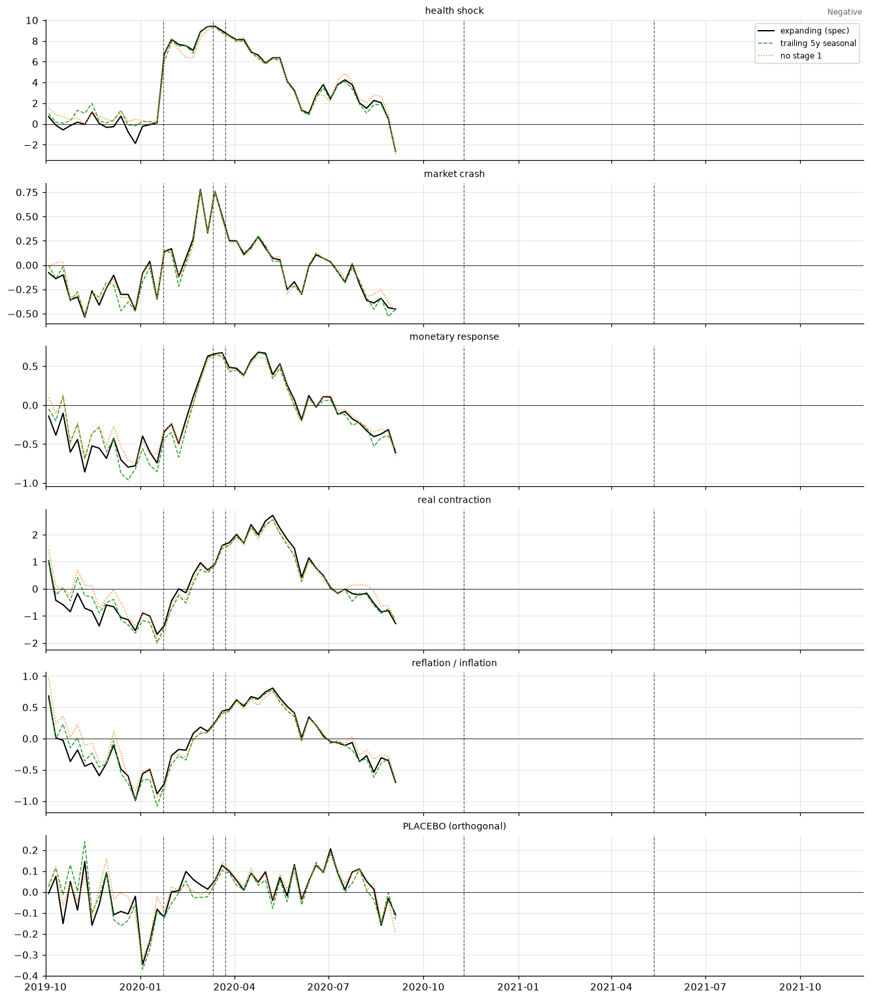

In [38]:
variants = {"expanding (spec)": panel,
            f"trailing {SEASONAL_YEARS_ROBUST}y seasonal": post_process(daily, seasonal_years=SEASONAL_YEARS_ROBUST),
            "no stage 1": post_process(daily, deseason=False)}
ref = panel.select("WEEK", KEY, "COMPOSITE")
for name, p in list(variants.items())[1:]:
    j = ref.join(p.select("WEEK", KEY, pl.col("COMPOSITE").alias("ALT")), on=["WEEK", KEY]).drop_nulls()
    j = j.filter(pl.col("WEEK").is_between(*VIEW))
    print(f"corr(C spec, C {name}) over the window = {np.corrcoef(j['COMPOSITE'], j['ALT'])[0, 1]:.3f}")

show = [b for b in ("health shock", "market crash", "monetary response", "real contraction",
                    "reflation / inflation", PLACEBO) if b in blist]
fig, axes = plt.subplots(len(show), 1, figsize=(12, 2.3 * len(show)), sharex=True)
styles = {"expanding (spec)": ("k", "-", 1.3), f"trailing {SEASONAL_YEARS_ROBUST}y seasonal": ("tab:green", "--", 1),
          "no stage 1": ("tab:orange", ":", 1)}
for name, p in variants.items():
    _, _, b_ = battery_frame(p, "COMPOSITE", {b: BKEYS[b] for b in show})
    b_ = b_.filter(pl.col("WEEK").is_between(*VIEW))
    for ax, b in zip(np.atleast_1d(axes), show):
        c, ls, lw = styles[name]
        ax.plot(b_["WEEK"], b_[b], color=c, ls=ls, lw=lw, label=name)
for ax, b in zip(np.atleast_1d(axes), show):
    ax.axhline(0, color="k", lw=0.5); ax.set_title(b, fontsize=9); date_axis(ax); shade_events(ax, labels=False)
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.show()

In [39]:
# summary per battery: baseline vs Covid phases
phases_ = {"baseline": BASELINE, "shock (Feb–May 20)": (date(2020, 2, 17), date(2020, 5, 31)),
           "vaccine (Nov 20–Mar 21)": (date(2020, 11, 1), date(2021, 3, 31)),
           "reflation (Apr–Nov 21)": (date(2021, 4, 1), VIEW[1])}
summ = []
for b in blist:
    r = {"battery": b}
    for name, (lo_, hi_) in phases_.items():
        r[f"C {name}"] = bat.filter(pl.col("WEEK").is_between(lo_, hi_))[b].mean()
    r["max z (window)"] = batz.filter(pl.col("WEEK").is_between(*VIEW))[b].max()
    summ.append(r)
pl.DataFrame(summ).with_columns(pl.selectors.float().round(2))

battery,C baseline,C shock (Feb–May 20),C vaccine (Nov 20–Mar 21),C reflation (Apr–Nov 21),max z (window)
str,f64,f64,null,null,f64
"""health shock""",0.15,7.21,null,null,7.69
"""lockdown / state control""",0.12,0.52,null,null,2.3
"""market crash""",0.08,0.24,null,null,2.34
"""dash for cash / funding""",0.05,0.17,null,null,1.16
"""monetary response""",0.14,0.46,null,null,1.35
"""fiscal response""",0.04,0.2,null,null,1.28
"""real contraction""",0.42,1.68,null,null,2.81
"""corporate distress""",0.08,0.41,null,null,1.21
"""oil / demand collapse""",0.16,0.42,null,null,2.01


# Part C: Positive + neutral — labels neu + pos


In [40]:
STUDY = "Positive + neutral"
daily = study_daily(STUDIES[STUDY])
print(f"{STUDY}: {daily.height:,} rows | {daily['DATE'].n_unique():,} days | "
      f"{daily[KEY].n_unique()} narratives | {daily['DATE'].min()} .. {daily['DATE'].max()}")
dup = daily.group_by("DATE", KEY).len().filter(pl.col("len") > 1).height
assert dup == 0, f"{dup} duplicated (DATE, {KEY}) rows"


Positive + neutral: 2,744,544 rows | 7,458 days | 368 narratives | 2000-04-01 .. 2020-08-31


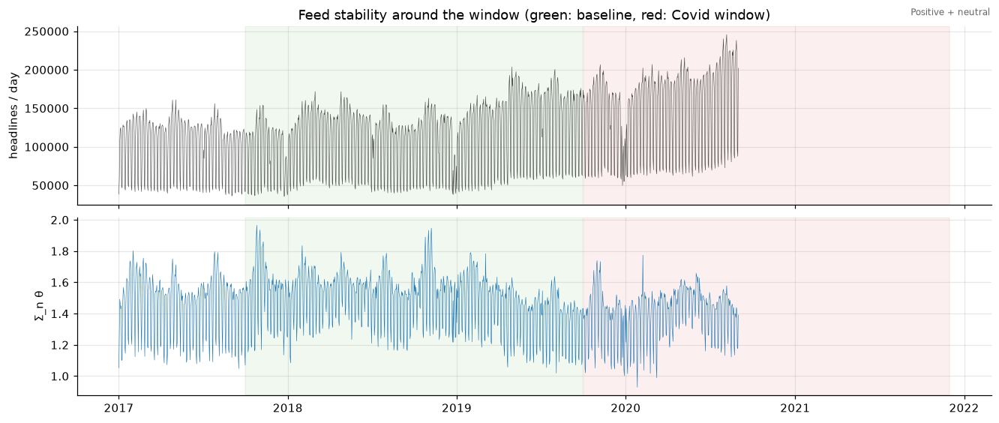

Y,headlines/day,mean Σθ
i32,f64,f64
2017,98757.0,1.474
2018,106540.0,1.519
2019,128253.0,1.409
2020,152220.0,1.406


In [41]:
flow = (daily.filter(pl.col("DATE").is_between(date(2017, 1, 1), VIEW[1]))
        .group_by("DATE").agg(pl.col("N_HEADLINES").first(), pl.col("THETA").sum().alias("SUM_THETA"))
        .sort("DATE"))
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(flow["DATE"], flow["N_HEADLINES"], lw=0.4, color="0.3"); axes[0].set_ylabel("headlines / day")
axes[1].plot(flow["DATE"], flow["SUM_THETA"], lw=0.4, color="tab:blue"); axes[1].set_ylabel("Σ_n θ")
for ax in axes:
    ax.axvspan(*WINDOW, color="tab:red", alpha=0.07); ax.axvspan(*BASELINE, color="tab:green", alpha=0.07)
axes[0].set_title("Feed stability around the window (green: baseline, red: Covid window)")
plt.show()
yr = (flow.with_columns(pl.col("DATE").dt.year().alias("Y")).group_by("Y")
      .agg(pl.col("N_HEADLINES").mean().round(0).alias("headlines/day"),
           pl.col("SUM_THETA").mean().round(3).alias("mean Σθ")).sort("Y"))
yr

## C.2. Post-processing pipeline (stages 1–5)


In [42]:
def deseasonalise(daily: pl.DataFrame, min_prior_years: int = MIN_PRIOR_YEARS,
                  seasonal_years: int | None = SEASONAL_YEARS) -> pl.DataFrame:
    # stage 1: subtract the prior-years-only week-of-year mean (expanding, or trailing N years)
    d = daily.with_columns(pl.col("DATE").dt.iso_year().alias("YEAR"),
                           pl.col("DATE").dt.week().clip(1, 52).alias("WOY"))
    yw = (d.group_by(KEY, "YEAR", "WOY").agg(pl.col("THETA").mean().alias("YW_MEAN"))
          .sort(KEY, "WOY", "YEAR")
          .with_columns(pl.col("YW_MEAN").is_not_null().cast(pl.Int32).alias("_has"),
                        pl.col("YW_MEAN").fill_null(0.0).alias("_v")))
    if seasonal_years is None:
        yw = yw.with_columns(pl.col("_v").cum_sum().shift(1).over(KEY, "WOY").alias("_psum"),
                             pl.col("_has").cum_sum().shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
    else:
        n = int(seasonal_years)
        yw = yw.with_columns(
            pl.col("_v").rolling_sum(n, min_samples=1).shift(1).over(KEY, "WOY").alias("_psum"),
            pl.col("_has").rolling_sum(n, min_samples=1).shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
    yw = (yw.with_columns(pl.when(pl.col("N_PRIOR_YEARS") >= min_prior_years)
                          .then(pl.col("_psum") / pl.col("N_PRIOR_YEARS")).otherwise(None).alias("SEAS"))
          .select(KEY, "YEAR", "WOY", "SEAS", "N_PRIOR_YEARS"))
    return (d.join(yw, on=[KEY, "YEAR", "WOY"], how="left")
            .with_columns((pl.col("THETA") - pl.col("SEAS")).alias("THETA_DS")))


def weekly(d: pl.DataFrame) -> pl.DataFrame:
    # stage 2: Mon-Fri mean, stamped on the Friday, on a complete (week x key) grid
    w = (d.filter(pl.col("DATE").dt.weekday() <= 5)
         .with_columns((pl.col("DATE").dt.truncate("1w") + timedelta(days=4)).alias("WEEK"))
         .group_by(KEY, "WEEK")
         .agg(pl.col("THETA_DS").mean().alias("THETA_W"), pl.col("THETA").mean().alias("THETA_RAW_W"),
              pl.col("THETA").count().alias("N_DAYS")))
    grid = pl.DataFrame({"WEEK": pl.date_range(w["WEEK"].min(), w["WEEK"].max(), "1w", eager=True)}).join(
        w.select(KEY).unique(), how="cross")
    return grid.join(w, on=[KEY, "WEEK"], how="left").sort(KEY, "WEEK")


def changes_and_horizons(w: pl.DataFrame, value: str = "THETA_W", horizons=ALL_H) -> pl.DataFrame:
    # stage 3 (first difference) + stage 4 (backward rolling mean over h weeks, full windows only)
    w = w.with_columns(pl.col(value).diff().over(KEY).alias("DTHETA"))
    return w.with_columns([pl.col("DTHETA").rolling_mean(h, min_samples=h).over(KEY).alias(f"D{h}")
                           for h in horizons])


def composite(w: pl.DataFrame, all_h=ALL_H) -> pl.DataFrame:
    # stage 5: each horizon / its own cross-sectional std (ddof=0, NOT demeaned), averaged over H
    w = w.with_columns([(pl.col(f"D{h}") / pl.col(f"D{h}").std(ddof=0).over("WEEK")).alias(f"Z{h}")
                        for h in all_h])

    def avg(hs, name):
        z = [pl.col(f"Z{h}") for h in hs]
        ok = pl.all_horizontal([c.is_not_null() & c.is_finite() for c in z])
        return pl.when(ok).then(pl.sum_horizontal(z) / len(z)).otherwise(None).alias(name)

    return w.with_columns(avg(COMPOSITE_H, "COMPOSITE"), avg(COMPOSITE_SHORT_H, "COMPOSITE_S"))


def post_process(daily: pl.DataFrame, deseason: bool = True, seasonal_years=SEASONAL_YEARS) -> pl.DataFrame:
    d = (deseasonalise(daily, seasonal_years=seasonal_years) if deseason
         else daily.with_columns(pl.col("THETA").alias("THETA_DS")))
    return composite(changes_and_horizons(weekly(d)))


daily_ds = deseasonalise(daily)
panel = composite(changes_and_horizons(weekly(daily_ds)))
print(f"{panel.height:,} (week x narrative) rows | weeks {panel['WEEK'].min()} .. {panel['WEEK'].max()}")
cs = panel.filter(pl.col("COMPOSITE").is_not_null())
for h in COMPOSITE_H:
    s = cs.group_by("WEEK").agg(pl.col(f"Z{h}").std(ddof=0))[f"Z{h}"]
    assert np.allclose(s.to_numpy(), 1.0, atol=1e-6), h
print("σ^(h) normalisation holds; window weeks with a composite:",
      cs.filter(pl.col("WEEK").is_between(*VIEW))["WEEK"].n_unique())

392,288 (week x narrative) rows | weeks 2000-04-07 .. 2020-09-04
σ^(h) normalisation holds; window weeks with a composite: 49


### C.2.1 Stage-by-stage walk-through on the pandemic narrative


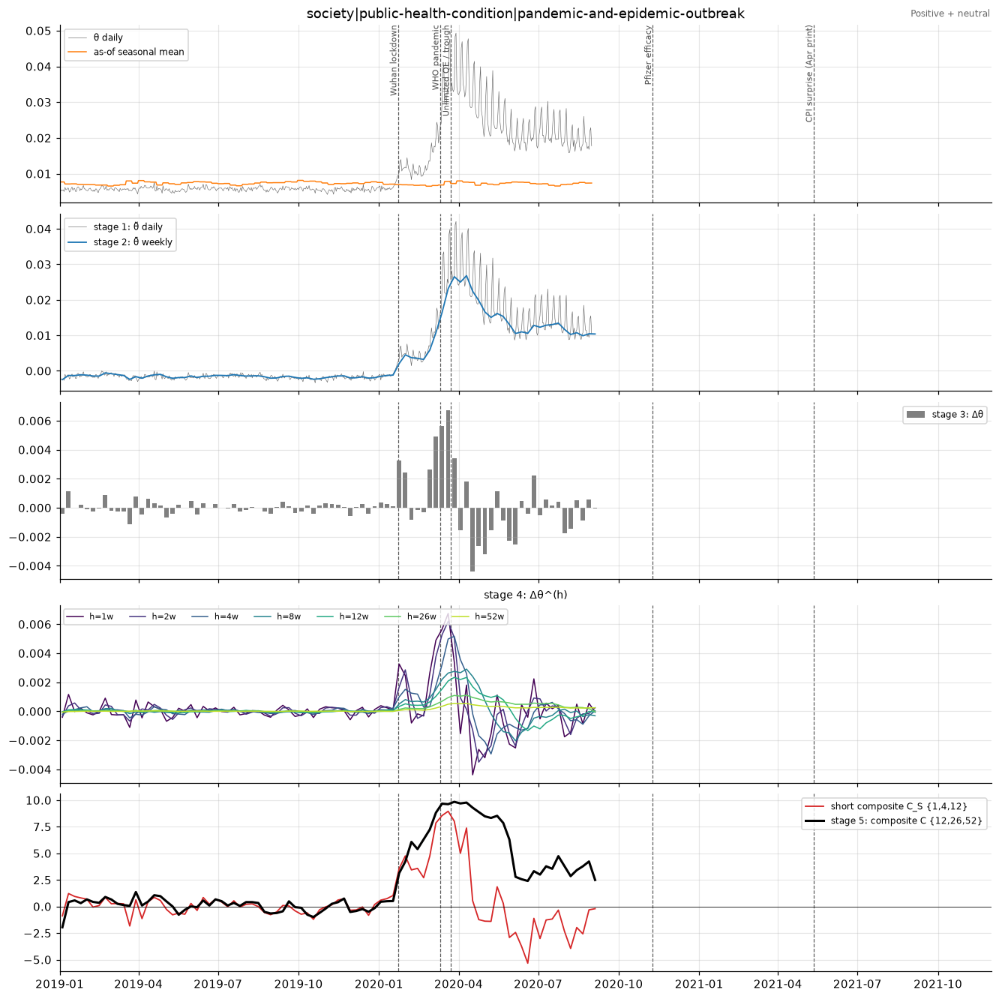

In [43]:
k0 = NAME_TO_KEYS[SHOWCASE][0]
lo = date(2019, 1, 1)
dd = daily_ds.filter((pl.col(KEY) == k0) & pl.col("DATE").is_between(lo, VIEW[1]))
pp = panel.filter((pl.col(KEY) == k0) & pl.col("WEEK").is_between(lo, VIEW[1]))

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(dd["DATE"], dd["THETA"], lw=0.4, color="0.4", label="θ daily")
axes[0].plot(dd["DATE"], dd["SEAS"], lw=1.0, color="tab:orange", label="as-of seasonal mean")
axes[0].set_title(k0); axes[0].legend(loc="upper left", fontsize=8)
axes[1].plot(dd["DATE"], dd["THETA_DS"], lw=0.4, color="0.4", label="stage 1: θ̃ daily")
axes[1].plot(pp["WEEK"], pp["THETA_W"], lw=1.2, color="tab:blue", label="stage 2: θ̄ weekly")
axes[1].legend(loc="upper left", fontsize=8)
axes[2].bar(pp["WEEK"], pp["DTHETA"], width=5, color="0.5", label="stage 3: Δθ"); axes[2].legend(fontsize=8)
for h, c in zip(ALL_H, plt.cm.viridis(np.linspace(0, 0.9, len(ALL_H)))):
    axes[3].plot(pp["WEEK"], pp[f"D{h}"], lw=1.0, color=c, label=f"h={h}w")
axes[3].set_title("stage 4: Δθ^(h)", fontsize=9); axes[3].legend(ncol=len(ALL_H), fontsize=7, loc="upper left")
axes[4].plot(pp["WEEK"], pp["COMPOSITE_S"], lw=1.2, color="tab:red", label="short composite C_S {1,4,12}")
axes[4].plot(pp["WEEK"], pp["COMPOSITE"], lw=2.0, color="k", label="stage 5: composite C {12,26,52}")
axes[4].axhline(0, color="k", lw=0.5); axes[4].legend(fontsize=8, loc="upper right")
for ax in axes:
    date_axis(ax, lo, VIEW[1]); shade_events(ax, labels=ax is axes[0])
plt.show()

## C.3. Composite properties over the window


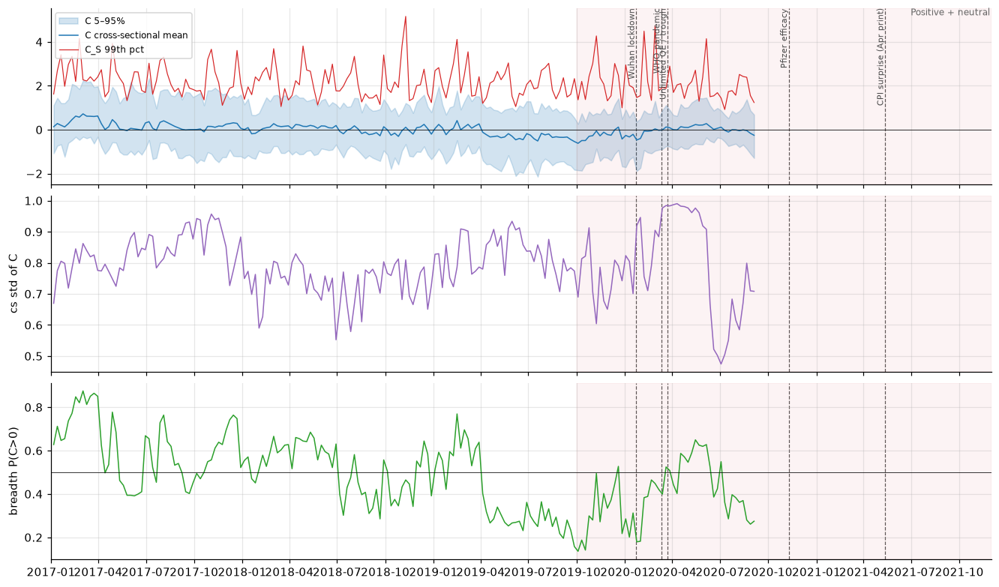

In [44]:
xs = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(date(2017, 1, 1), VIEW[1]))
      .group_by("WEEK")
      .agg(pl.col("COMPOSITE").mean().alias("MEAN"), pl.col("COMPOSITE").std(ddof=0).alias("STD"),
           (pl.col("COMPOSITE") > 0).mean().alias("BREADTH"),
           pl.col("COMPOSITE").quantile(0.95).alias("Q95"), pl.col("COMPOSITE").quantile(0.05).alias("Q05"),
           pl.col("COMPOSITE_S").quantile(0.99).alias("QS99"))
      .sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].fill_between(xs["WEEK"], xs["Q05"], xs["Q95"], color="tab:blue", alpha=0.2, label="C 5–95%")
axes[0].plot(xs["WEEK"], xs["MEAN"], color="tab:blue", lw=1, label="C cross-sectional mean")
axes[0].plot(xs["WEEK"], xs["QS99"], color="tab:red", lw=0.8, label="C_S 99th pct")
axes[0].axhline(0, color="k", lw=0.5); axes[0].legend(fontsize=8, loc="upper left")
axes[1].plot(xs["WEEK"], xs["STD"], color="tab:purple", lw=1); axes[1].set_ylabel("cs std of C")
axes[2].plot(xs["WEEK"], xs["BREADTH"], color="tab:green", lw=1); axes[2].axhline(0.5, color="k", lw=0.5)
axes[2].set_ylabel("breadth P(C>0)")
for ax in axes:
    date_axis(ax, date(2017, 1, 1), VIEW[1]); ax.axvspan(*WINDOW, color="tab:red", alpha=0.05)
    shade_events(ax, labels=ax is axes[0])
plt.show()

## C.4. Predeclared Covid batteries


In [45]:
name_to_keys = NAME_TO_KEYS     # narrative names, pole names mapped to their merged narrative
print("pole entries (now the whole merged narrative):",
      {b: pole_entries(ns) for b, ns in BATTERIES.items() if pole_entries(ns)})
_placebo = {k for n in BATTERIES[PLACEBO] for k in NAME_TO_KEYS.get(n, [])}
_stress = {k for b, ns in BATTERIES.items() if b != PLACEBO for n in ns for k in NAME_TO_KEYS.get(n, [])}
assert not _placebo & _stress, f"placebo shares merged narratives with other batteries: {sorted(_placebo & _stress)}"
BATTERIES_STUDY = {b: ns + PLACEBO_BY_STUDY.get(STUDY, []) if b == PLACEBO else ns
                   for b, ns in BATTERIES.items()}
if PLACEBO_BY_STUDY.get(STUDY):
    print(f"{STUDY}: placebo adds {PLACEBO_BY_STUDY[STUDY]} (this study only; same merged "
          f"narratives as stress entries, read on the {'+'.join(STUDIES[STUDY])} label)")
BKEYS = {}
for b, names in BATTERIES_STUDY.items():
    missing = [n for n in names if n not in name_to_keys]
    if missing:
        print(f"[{b}] names not in the taxonomy: {missing}")
    BKEYS[b] = list(dict.fromkeys(k for n in names for k in name_to_keys.get(n, [])))   # two poles of one pair: one merged key
print({b: len(k) for b, k in BKEYS.items()})
blist = [b for b in BKEYS if BKEYS[b]]


def battery_frame(panel, col, bkeys):
    wide = panel.filter(pl.col(col).is_not_null()).pivot(on=KEY, index="WEEK", values=col).sort("WEEK")
    m = wide.drop("WEEK")
    return wide["WEEK"], m, pl.DataFrame({"WEEK": wide["WEEK"], **{
        b: np.nanmean(m.select([k for k in ks if k in m.columns]).to_numpy(), axis=1)
        for b, ks in bkeys.items() if ks}})


WEEKS, C, bat = battery_frame(panel, "COMPOSITE", BKEYS)
WEEKS_S, CS, bat_s = battery_frame(panel, "COMPOSITE_S", BKEYS)
base = bat.filter(pl.col("WEEK").is_between(*BASELINE))
batz = bat.with_columns([((pl.col(b) - base[b].mean()) / base[b].std()).alias(b) for b in blist])
v = bat.filter(pl.col("WEEK").is_between(*VIEW)); v_s = bat_s.filter(pl.col("WEEK").is_between(*VIEW))
print(f"baseline {BASELINE[0]} .. {BASELINE[1]}: {base.height} weeks")

pole entries (now the whole merged narrative): {'health shock': ['public-health-deterioration'], 'lockdown / state control': ['state-direction-expansion'], 'monetary response': ['balance-sheet-expansion', 'global-liquidity-easing'], 'real contraction': ['business-cycle-contraction', 'labour-market-slackening', 'guidance-cut', 'dividend-cut'], 'corporate distress': ['credit-deterioration', 'rating-downgrade'], 'oil / demand collapse': ['demand-destruction', 'demand-driven-price-collapse', 'curve-contango'], 'vaccine / health recovery': ['public-health-improvement'], 'reopening / recovery': ['business-cycle-expansion', 'capex-upswing'], 'reflation / inflation': ['price-level-change-reflation', 'labour-market-tightening', 'input-cost-squeeze'], 'PLACEBO (orthogonal)': ['allowance-cap-tightening', 'allowance-cap-loosening']}
{'health shock': 3, 'lockdown / state control': 3, 'market crash': 7, 'dash for cash / funding': 7, 'monetary response': 7, 'fiscal response': 4, 'real contraction': 7

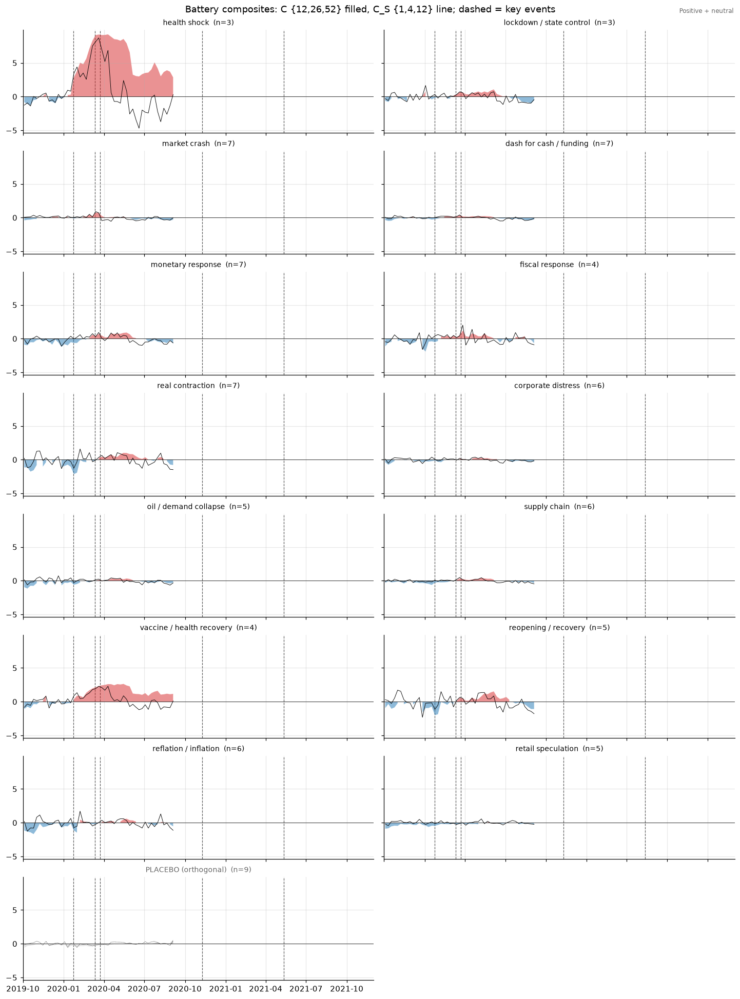

In [46]:
ncol = 2
nrow = int(np.ceil(len(blist) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.2 * nrow), sharex=True, sharey=True)
for ax, b in zip(axes.flat, blist):
    y = v[b].to_numpy()
    diag = b in DIAGNOSTIC
    ax.fill_between(v["WEEK"], 0, y, where=y > 0, color="0.6" if diag else "tab:red", alpha=0.5, lw=0)
    ax.fill_between(v["WEEK"], 0, y, where=y < 0, color="0.8" if diag else "tab:blue", alpha=0.5, lw=0)
    ax.plot(v_s["WEEK"], v_s[b], color="k", lw=0.6, ls=":" if diag else "-", label="C_S")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{b}  (n={len(BKEYS[b])})", fontsize=9, color="0.4" if diag else "k")
    date_axis(ax)
for ax in axes.flat[len(blist):]:
    ax.axis("off")
for ax in axes.flat[:len(blist)]:
    shade_events(ax, labels=False)
fig.suptitle("Battery composites: C {12,26,52} filled, C_S {1,4,12} line; dashed = key events")
plt.show()

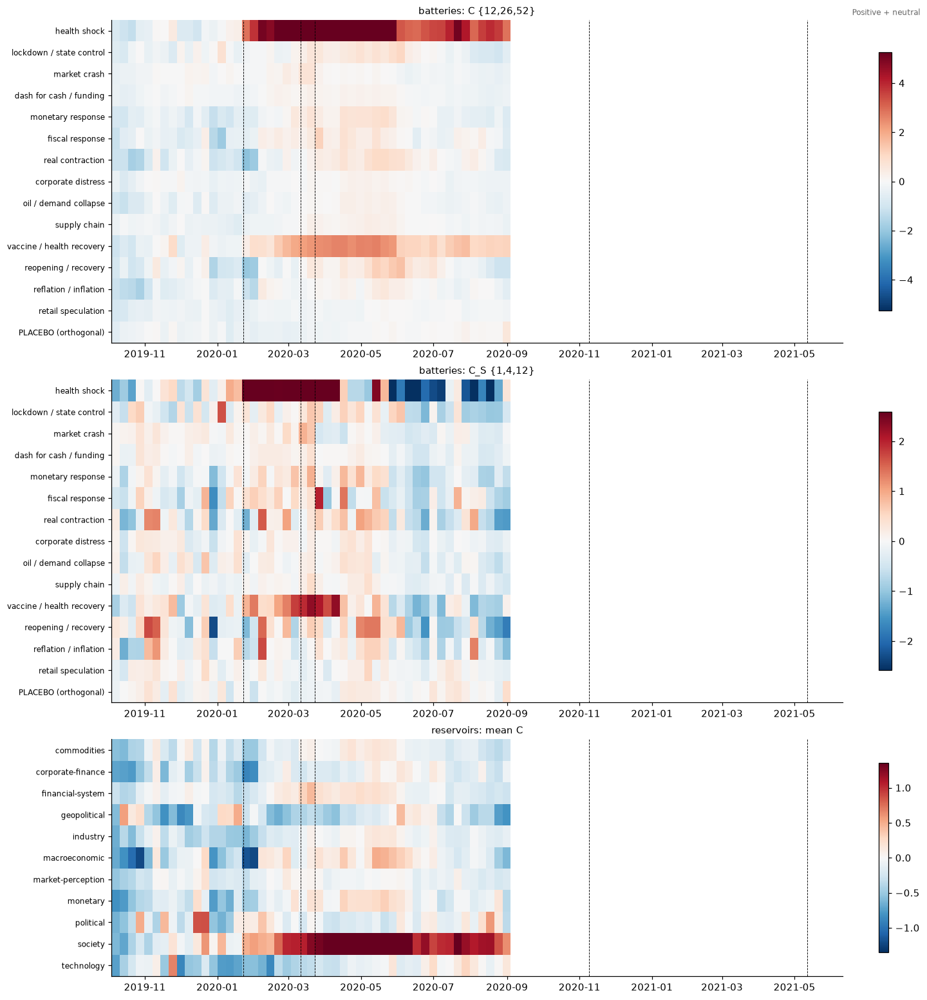

In [47]:
def heat(ax, frame, rows, title, vmax=None):
    m = frame.select(rows).to_numpy().T
    vmax = vmax or np.nanpercentile(np.abs(m), 98)
    x = mdates.date2num(frame["WEEK"].to_list())
    im = ax.imshow(m, aspect="auto", cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax),
                   extent=[x[0], x[-1], len(rows) - 0.5, -0.5], interpolation="nearest")
    ax.set_yticks(range(len(rows)), rows, fontsize=8); ax.xaxis_date(); ax.grid(False)
    for name in KEY_EVENTS:
        ax.axvline(EVENTS[name], color="k", lw=0.6, ls="--")
    ax.set_title(title, fontsize=10)
    return im


res = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(*VIEW))
       .join(NARR.select(KEY, "reservoir"), on=KEY)
       .group_by("WEEK", "reservoir").agg(pl.col("COMPOSITE").mean())
       .pivot(on="reservoir", index="WEEK", values="COMPOSITE").sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(13, 14), height_ratios=[len(blist), len(blist), res.width - 1])
fig.colorbar(heat(axes[0], v, blist, "batteries: C {12,26,52}"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], v_s, blist, "batteries: C_S {1,4,12}"), ax=axes[1], shrink=0.8)
fig.colorbar(heat(axes[2], res, sorted(res.columns[1:]), "reservoirs: mean C"), ax=axes[2], shrink=0.8)
plt.show()

### C.4.1 Event table: permutation test and block-bootstrap baseline band


In [48]:
wk_arr = np.array(WEEKS.to_list())
col_of = {k: i for i, k in enumerate(C.columns)}
Cn = C.to_numpy()


def event_week(d):
    return min(int(np.searchsorted(wk_arr, d)), len(wk_arr) - 1)


def perm_p(row, idx, n_perm=N_PERM):
    # vectorised: n_perm random subsets of size k without replacement (argpartition of uniforms)
    x = row[~np.isnan(row)]
    obs = np.nanmean(row[idx])
    k = len(idx)
    pick = np.argpartition(RNG.random((n_perm, len(x))), k, axis=1)[:, :k]
    draws = x[pick].mean(axis=1)
    return obs, (1 + (draws >= obs).sum()) / (n_perm + 1)


def boot_block_max(series, n_boot=N_BOOT, block=BLOCK_WEEKS):
    # distribution of the max of one block drawn from the baseline series (moving-block bootstrap)
    s = series[~np.isnan(series)]
    starts = RNG.integers(0, len(s) - block + 1, n_boot)
    return np.array([s[i:i + block].max() for i in starts])


boot = {b: boot_block_max(base[b].to_numpy()) for b in blist}
rows = []
for ev, d in EVENTS.items():
    if not (VIEW[0] <= d <= VIEW[1]):
        continue
    i = event_week(d)
    i_s = min(int(np.searchsorted(np.array(WEEKS_S.to_list()), d)), bat_s.height - 1)
    for b in blist:
        idx = np.array([col_of[k] for k in BKEYS[b] if k in col_of])
        obs, p = perm_p(Cn[i], idx)
        rows.append({"event": ev, "week": wk_arr[i], "battery": b, "C": obs, "C_S": bat_s[b][i_s],
                     "z_vs_baseline": batz[b][i], "perm_p": p,
                     "boot_p": (1 + (boot[b] >= obs).sum()) / (N_BOOT + 1)})
ev_tab = pl.DataFrame(rows)
for col, dig in (("C", 2), ("C_S", 2), ("perm_p", 3), ("boot_p", 3)):
    print(col)
    display(ev_tab.pivot(on="event", index="battery", values=col).with_columns(pl.selectors.float().round(dig)))

C


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",-0.07,2.87,7.11,8.3,9.11,9.2,9.13,9.13,8.52,2.86,2.86,2.86,2.86,2.86,2.86
"""lockdown / state control""",0.78,-0.17,-0.26,0.16,0.32,0.65,0.6,0.6,0.61,-0.56,-0.56,-0.56,-0.56,-0.56,-0.56
"""market crash""",0.0,-0.11,0.42,0.24,0.73,0.73,0.24,0.24,0.08,-0.31,-0.31,-0.31,-0.31,-0.31,-0.31
"""dash for cash / funding""",-0.13,-0.22,0.17,0.11,0.19,0.32,0.19,0.19,0.17,-0.27,-0.27,-0.27,-0.27,-0.27,-0.27
"""monetary response""",-0.82,-0.63,0.12,0.57,0.4,0.71,0.45,0.45,0.7,-0.72,-0.72,-0.72,-0.72,-0.72,-0.72
"""fiscal response""",-1.92,-0.5,0.22,0.4,0.22,0.5,1.21,1.21,0.61,-0.67,-0.67,-0.67,-0.67,-0.67,-0.67
"""real contraction""",-0.92,-2.15,0.24,-0.2,-0.1,0.24,0.43,0.43,0.49,-0.79,-0.79,-0.79,-0.79,-0.79,-0.79
"""corporate distress""",-0.24,-0.12,-0.05,0.02,-0.05,0.14,0.06,0.06,0.26,-0.28,-0.28,-0.28,-0.28,-0.28,-0.28
"""oil / demand collapse""",-0.29,-0.59,-0.24,-0.06,0.0,0.11,0.05,0.05,0.3,-0.28,-0.28,-0.28,-0.28,-0.28,-0.28


C_S


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.13,3.43,5.1,7.51,8.13,8.7,6.96,6.96,-0.71,0.3,0.3,0.3,0.3,0.3,0.3
"""lockdown / state control""",1.66,0.33,0.12,0.03,0.3,0.71,0.58,0.58,0.31,-0.43,-0.43,-0.43,-0.43,-0.43,-0.43
"""market crash""",-0.07,0.03,0.5,0.08,0.9,0.71,-0.44,-0.44,0.03,-0.04,-0.04,-0.04,-0.04,-0.04,-0.04
"""dash for cash / funding""",-0.14,0.01,0.17,0.07,0.15,0.4,-0.01,-0.01,0.12,-0.11,-0.11,-0.11,-0.11,-0.11,-0.11
"""monetary response""",-0.52,-0.05,0.23,0.74,0.28,0.92,0.07,0.07,0.4,-0.63,-0.63,-0.63,-0.63,-0.63,-0.63
"""fiscal response""",-0.61,0.4,-0.0,0.49,0.16,0.41,2.01,2.01,-0.63,-0.91,-0.91,-0.91,-0.91,-0.91,-0.91
"""real contraction""",-0.37,-1.25,1.05,-0.31,-0.07,0.33,0.63,0.63,-0.12,-1.47,-1.47,-1.47,-1.47,-1.47,-1.47
"""corporate distress""",-0.1,0.06,0.11,0.11,-0.07,0.2,0.02,0.02,0.36,-0.15,-0.15,-0.15,-0.15,-0.15,-0.15
"""oil / demand collapse""",0.15,-0.27,-0.13,-0.06,0.14,0.23,-0.05,-0.05,0.32,-0.33,-0.33,-0.33,-0.33,-0.33,-0.33


perm_p


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""lockdown / state control""",0.021,0.228,0.78,0.147,0.105,0.06,0.068,0.071,0.07,0.791,0.795,0.795,0.795,0.788,0.794
"""market crash""",0.177,0.105,0.093,0.08,0.057,0.058,0.169,0.171,0.443,0.566,0.566,0.572,0.562,0.561,0.57
"""dash for cash / funding""",0.314,0.204,0.237,0.148,0.138,0.144,0.22,0.218,0.282,0.504,0.503,0.501,0.506,0.503,0.502
"""monetary response""",0.963,0.748,0.295,0.055,0.064,0.059,0.077,0.079,0.058,0.968,0.969,0.968,0.967,0.969,0.969
"""fiscal response""",1.0,0.627,0.221,0.048,0.14,0.085,0.034,0.033,0.067,0.898,0.895,0.899,0.898,0.897,0.895
"""real contraction""",0.98,1.0,0.183,0.757,0.541,0.214,0.087,0.085,0.082,0.983,0.983,0.983,0.983,0.983,0.982
"""corporate distress""",0.477,0.122,0.544,0.297,0.437,0.35,0.411,0.414,0.193,0.512,0.514,0.513,0.516,0.506,0.51
"""oil / demand collapse""",0.541,0.71,0.81,0.457,0.35,0.401,0.428,0.428,0.163,0.521,0.53,0.518,0.519,0.517,0.518


boot_p


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.937,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""lockdown / state control""",0.46,1.0,1.0,0.938,0.658,0.517,0.517,0.517,0.517,1.0,1.0,1.0,1.0,1.0,1.0
"""market crash""",0.712,0.832,0.162,0.378,0.0,0.0,0.378,0.378,0.602,0.955,0.955,0.955,0.955,0.955,0.955
"""dash for cash / funding""",0.832,1.0,0.712,0.721,0.693,0.352,0.693,0.693,0.712,1.0,1.0,1.0,1.0,1.0,1.0
"""monetary response""",1.0,1.0,0.977,0.324,0.681,0.288,0.585,0.585,0.288,1.0,1.0,1.0,1.0,1.0,1.0
"""fiscal response""",1.0,1.0,0.785,0.728,0.785,0.636,0.161,0.161,0.495,1.0,1.0,1.0,1.0,1.0,1.0
"""real contraction""",1.0,1.0,0.806,0.806,0.806,0.806,0.684,0.684,0.684,0.947,0.947,0.947,0.947,0.947,0.947
"""corporate distress""",0.921,0.921,0.921,0.843,0.921,0.758,0.843,0.843,0.71,0.921,0.921,0.921,0.921,0.921,0.921
"""oil / demand collapse""",0.821,0.848,0.821,0.688,0.677,0.58,0.647,0.647,0.488,0.821,0.821,0.821,0.821,0.821,0.821


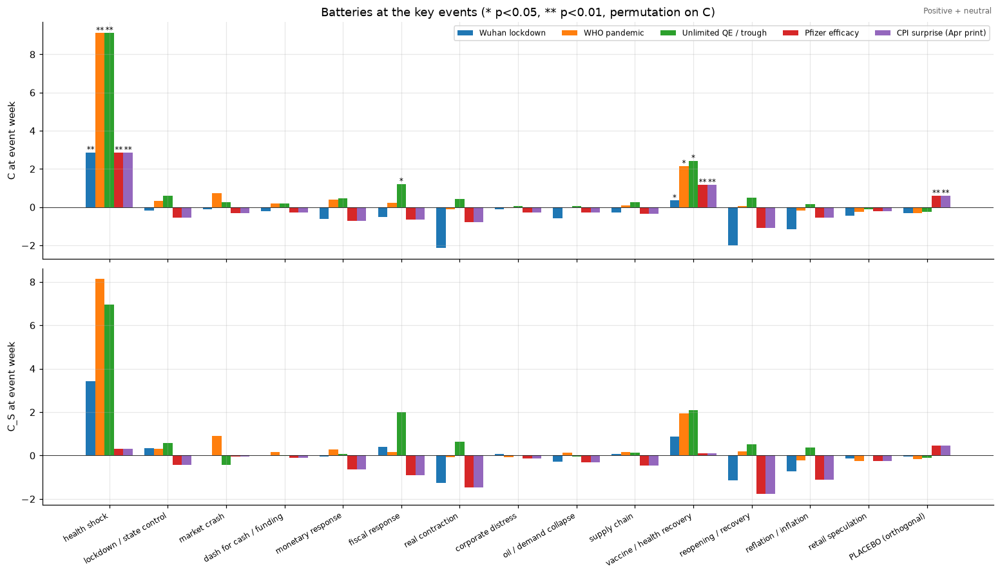

In [49]:
pz = ev_tab.filter(pl.col("event").is_in(list(KEY_EVENTS)))
evs = [e for e in KEY_EVENTS if e in pz["event"].unique().to_list()]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, col in zip(axes, ("C", "C_S")):
    wbar = 0.8 / max(len(evs), 1)
    for j, e in enumerate(evs):
        g = pz.filter(pl.col("event") == e).sort(pl.col("battery").replace_strict({b: i for i, b in enumerate(blist)}))
        xs_ = np.arange(len(blist)) + j * wbar
        ax.bar(xs_, g[col], width=wbar, label=e)
        if col == "C":
            for x_, c_, p_ in zip(xs_, g["C"], g["perm_p"]):
                if p_ < 0.05:
                    ax.text(x_, c_ + (0.03 if c_ >= 0 else -0.12), "*" if p_ >= 0.01 else "**",
                            ha="center", fontsize=8)
    ax.axhline(0, color="k", lw=0.5); ax.set_ylabel(f"{col} at event week")
axes[1].set_xticks(np.arange(len(blist)) + 0.4 - wbar / 2, blist, rotation=30, ha="right", fontsize=8)
axes[0].legend(fontsize=8, ncol=len(evs)); axes[0].set_title("Batteries at the key events (* p<0.05, ** p<0.01, permutation on C)")
plt.show()

## C.5. Horizon term structure at the key events


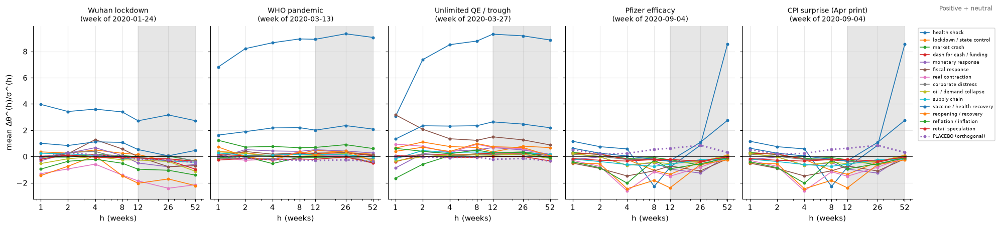

In [50]:
term = panel.select("WEEK", KEY, *[f"Z{h}" for h in ALL_H])
fig, axes = plt.subplots(1, len(KEY_EVENTS), figsize=(18, 4), sharey=True)
for ax, e in zip(axes, KEY_EVENTS):
    wk = wk_arr[event_week(EVENTS[e])]
    t = term.filter(pl.col("WEEK") == wk)
    for b in blist:
        g = t.filter(pl.col(KEY).is_in(BKEYS[b])).select([pl.col(f"Z{h}").mean() for h in ALL_H]).row(0)
        diag = b in DIAGNOSTIC
        ax.plot(ALL_H, g, marker="o", ms=3, lw=2 if diag else 1.1, ls=":" if diag else "-", label=b)
    ax.axhline(0, color="k", lw=0.5); ax.set_xscale("log"); ax.set_xticks(ALL_H, [str(h) for h in ALL_H])
    ax.axvspan(min(COMPOSITE_H), max(COMPOSITE_H), color="0.9", zorder=0)
    ax.set_title(f"{e}\n(week of {wk})", fontsize=9); ax.set_xlabel("h (weeks)")
axes[0].set_ylabel("mean Δθ^(h)/σ^(h)")
axes[-1].legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## C.6. Unsupervised cross-sections


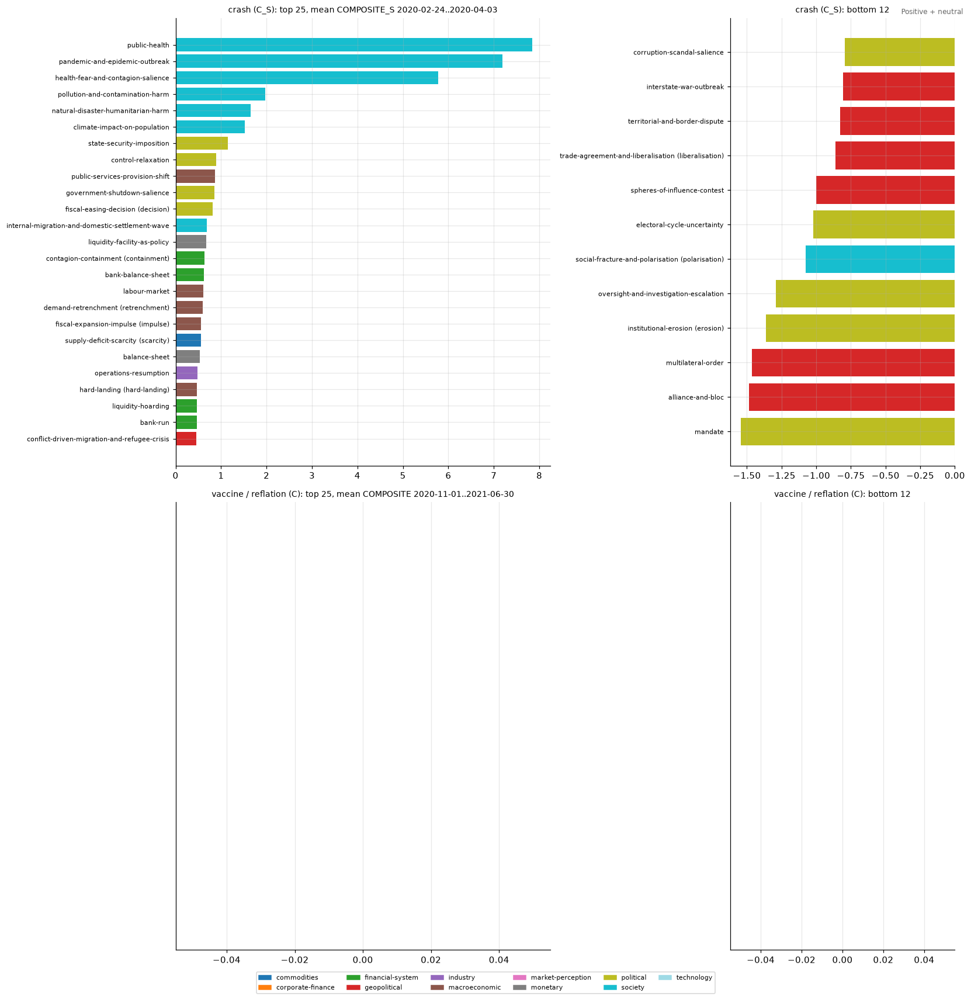

In [52]:
resv = sorted(NARR["reservoir"].unique().to_list())
cmap = dict(zip(resv, plt.cm.tab20(np.linspace(0, 1, len(resv)))))
in_b = {k for b in blist if b not in DIAGNOSTIC for k in BKEYS[b]}


def ranked(col, lo, hi):
    return (panel.filter(pl.col("WEEK").is_between(lo, hi) & pl.col(col).is_not_null())
            .group_by(KEY).agg(pl.col(col).mean().alias("V")).join(NARR, on=KEY).sort("V", descending=True))


def barplot(ax, t, title):
    lab = [f"{r['narrative']} ({r['pole']})" if r["pole"] else r["narrative"] for r in t.iter_rows(named=True)]
    ax.barh(range(t.height), t["V"], color=[cmap[r] for r in t["reservoir"]])
    ax.set_yticks(range(t.height), lab, fontsize=7); ax.invert_yaxis(); ax.set_title(title, fontsize=9)


phases = {"crash (C_S)": ("COMPOSITE_S", date(2020, 2, 24), date(2020, 4, 3)),
          "vaccine / reflation (C)": ("COMPOSITE", date(2020, 11, 1), date(2021, 6, 30))}
fig, axes = plt.subplots(2, 2, figsize=(15, 15), width_ratios=[5, 3])
for row, (name, (col, lo, hi)) in enumerate(phases.items()):
    r = ranked(col, lo, hi)
    barplot(axes[row, 0], r.head(25), f"{name}: top 25, mean {col} {lo}..{hi}")
    barplot(axes[row, 1], r.tail(12), f"{name}: bottom 12")
    # print(f"{name}: battery narratives among top 25 = {r.head(25).filter(pl.col(KEY).is_in(in_b)).height} "
    #       f"(chance ≈ {25 * len(in_b) / r.height:.1f})")
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[r]) for r in resv]
fig.legend(handles, resv, fontsize=7, loc="lower center", ncol=min(6, len(resv)), bbox_to_anchor=(0.5, -0.03))
plt.show()

## C.7. Narrative waves: onset and peak timing


battery,onset_CS,peak_C,max_C,max_CS,weeks_CS_lit
str,date,date,f64,f64,i64
"""market crash""",null,2020-03-20,0.73,0.9,0
"""dash for cash / funding""",null,2020-03-20,0.32,0.4,0
"""fiscal response""",2020-03-27,2020-03-27,1.21,2.01,2
"""health shock""",2020-01-24,2020-04-10,9.22,8.7,13
"""corporate distress""",null,2020-04-24,0.26,0.38,0
"""supply chain""",null,2020-05-08,0.41,0.48,0
"""real contraction""",2019-11-01,2020-05-15,1.01,1.59,5
"""vaccine / health recovery""",2020-01-31,2020-05-15,2.63,2.29,9
"""monetary response""",null,2020-05-22,0.9,0.92,0


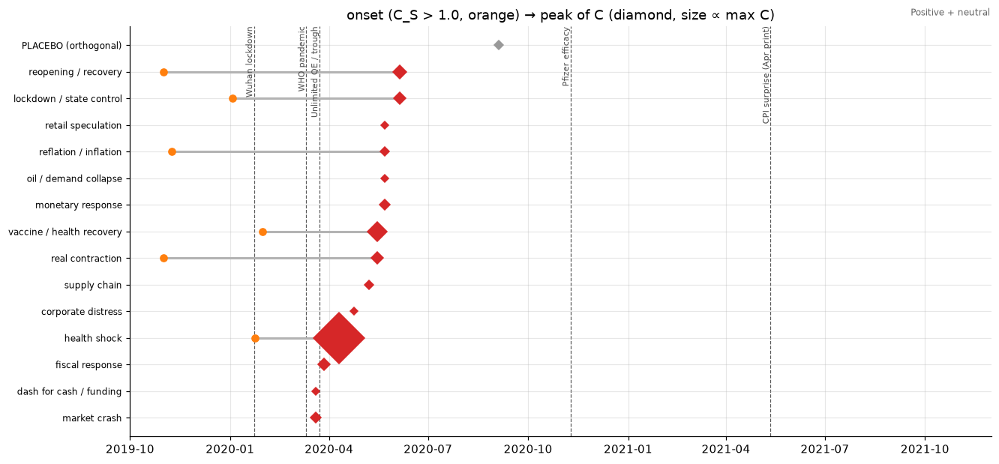

In [53]:
win = v.join(v_s, on="WEEK", suffix="_S")
wv = []
for b in blist:
    ys = win[f"{b}_S"].to_numpy(); y = win[b].to_numpy()
    on = np.flatnonzero(ys > ONSET_THRESHOLD)
    wv.append({"battery": b, "onset_CS": win["WEEK"][int(on[0])] if on.size else None,
               "peak_C": win["WEEK"][int(np.nanargmax(y))], "max_C": float(np.nanmax(y)),
               "max_CS": float(np.nanmax(ys)), "weeks_CS_lit": int(on.size)})
waves = pl.DataFrame(wv).sort("peak_C")
display(waves.with_columns(pl.selectors.float().round(2)))

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, r in enumerate(waves.iter_rows(named=True)):
    col = "0.6" if r["battery"] in DIAGNOSTIC else "tab:red"
    if r["onset_CS"] is not None:
        ax.plot([r["onset_CS"], r["peak_C"]], [i, i], color="0.7", lw=2)
        ax.plot(r["onset_CS"], i, "o", color="tab:orange")
    ax.plot(r["peak_C"], i, "D", color=col, ms=4 + 3 * max(r["max_C"], 0))
ax.set_yticks(range(waves.height), waves["battery"], fontsize=8)
date_axis(ax); shade_events(ax)
ax.set_title(f"onset (C_S > {ONSET_THRESHOLD}, orange) → peak of C (diamond, size ∝ max C)")
plt.show()

In [54]:
# the leading narratives of each quarter (mean C), 2019Q4 .. end of window
q = (panel.filter(pl.col("WEEK").is_between(*VIEW) & pl.col("COMPOSITE").is_not_null())
     .with_columns(pl.col("WEEK").dt.truncate("1q").alias("Q"))
     .group_by("Q", KEY).agg(pl.col("COMPOSITE").mean())
     .join(NARR.select(KEY, "narrative", "pole"), on=KEY)
     .with_columns(pl.when(pl.col("pole").fill_null("") != "").then(pl.format("{} ({})", "narrative", "pole"))
                   .otherwise(pl.col("narrative")).alias("label"))
     .sort("Q", "COMPOSITE", descending=[False, True])
     .group_by("Q", maintain_order=True).head(5)
     .with_columns(pl.format("{} {}", pl.col("label"), pl.col("COMPOSITE").round(2)).alias("top"))
     .group_by("Q", maintain_order=True).agg(pl.col("top"))
     .with_columns(pl.col("Q").dt.strftime("%Y-%m"), *[pl.col("top").list.get(i, null_on_oob=True).alias(f"#{i+1}")
                                                       for i in range(5)])
     .drop("top"))
q

Q,#1,#2,#3,#4,#5
str,str,str,str,str,str
"""2019-10""","""oversight-and-investigation-escalation 2.13""","""corruption-scandal-salience 1.55""","""legislative-gridlock (gridlock) 0.93""","""civil-unrest-and-protest-wave 0.87""","""capacity 0.8"""
"""2020-01""","""pandemic-and-epidemic-outbreak 5.52""","""public-health 5.33""","""health-fear-and-contagion-salience 4.25""","""natural-disaster-humanitarian-harm 1.93""","""pollution-and-contamination-harm 1.35"""
"""2020-04""","""public-health 8.69""","""pandemic-and-epidemic-outbreak 6.78""","""health-fear-and-contagion-salience 4.86""","""climate-impact-on-population 2.28""","""natural-disaster-humanitarian-harm 2.21"""
"""2020-07""","""public-health 4.61""","""pandemic-and-epidemic-outbreak 3.56""","""health-fear-and-contagion-salience 3.08""","""climate-impact-on-population 2.7""","""internal-migration-and-domestic-settlement-wave 1.76"""


## C.8. Topic-level (direction-free) view


{'public health': 1, 'market volatility': 3, 'funding & plumbing': 3, 'monetary policy': 3, 'fiscal': 2, 'output & labour': 3, 'supply chain': 3, 'prices': 1, 'state control': 2, 'PLACEBO (orthogonal)': 3}


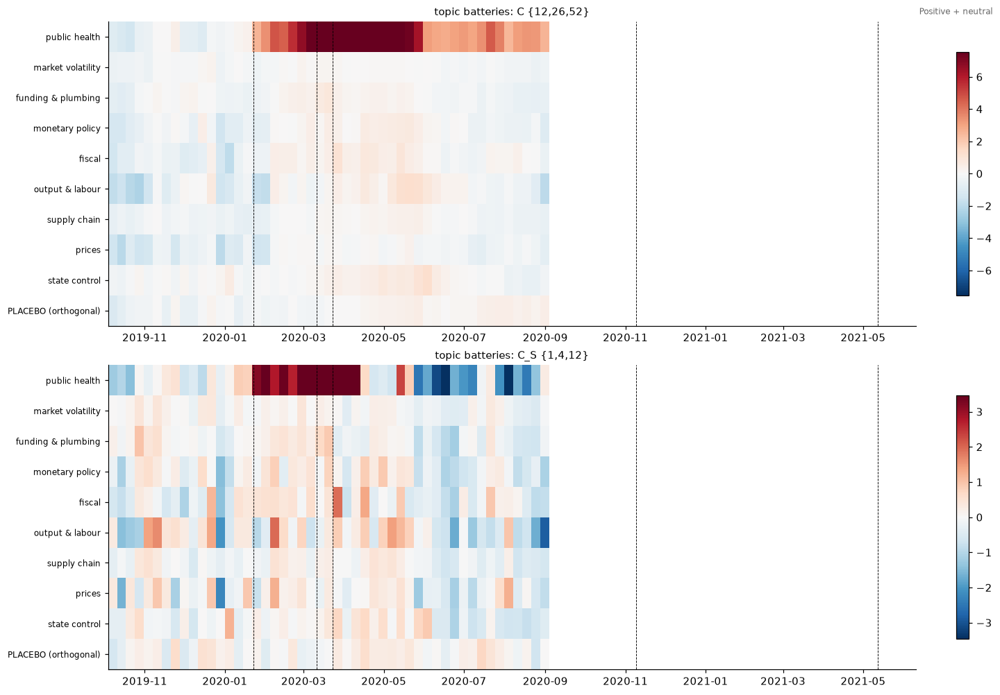

top / bottom dimensions in the crash (C_S) with their vaccine/reflation-phase C


narrative_key,C_S_crash,C_vaccine_reflation
str,f64,f64


In [55]:
topic_daily = (daily.group_by("DATE", "reservoir", "dimension")
               .agg(pl.col("THETA").sum(), pl.col("N_HEADLINES").first())
               .with_columns(pl.format("{}|{}", "reservoir", "dimension").alias(KEY)))
tpanel = post_process(topic_daily)
TKEYS = {b: [k for k in ks if k in set(tpanel[KEY].unique().to_list())] for b, ks in TOPIC_BATTERIES.items()}
print({b: len(k) for b, k in TKEYS.items()})
TW, TC, tbat = battery_frame(tpanel, "COMPOSITE", TKEYS)
_, _, tbat_s = battery_frame(tpanel, "COMPOSITE_S", TKEYS)
tv = tbat.filter(pl.col("WEEK").is_between(*VIEW)); tv_s = tbat_s.filter(pl.col("WEEK").is_between(*VIEW))
tlist = [b for b in TKEYS if TKEYS[b]]
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.colorbar(heat(axes[0], tv, tlist, "topic batteries: C {12,26,52}"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], tv_s, tlist, "topic batteries: C_S {1,4,12}"), ax=axes[1], shrink=0.8)
plt.show()

trank = (tpanel.filter(pl.col("WEEK").is_between(date(2020, 2, 24), date(2020, 4, 3)) & pl.col("COMPOSITE_S").is_not_null())
         .group_by(KEY).agg(pl.col("COMPOSITE_S").mean().alias("C_S_crash"))
         .join(tpanel.filter(pl.col("WEEK").is_between(date(2020, 11, 1), date(2021, 6, 30)))
               .group_by(KEY).agg(pl.col("COMPOSITE").mean().alias("C_vaccine_reflation")), on=KEY)
         .sort("C_S_crash", descending=True))
print("top / bottom dimensions in the crash (C_S) with their vaccine/reflation-phase C")
display(pl.concat([trank.head(12), trank.tail(6)]).with_columns(pl.selectors.float().round(2)))

## C.9. Robustness: stage-1 variants


corr(C spec, C trailing 5y seasonal) over the window = 0.933
corr(C spec, C no stage 1) over the window = 0.875


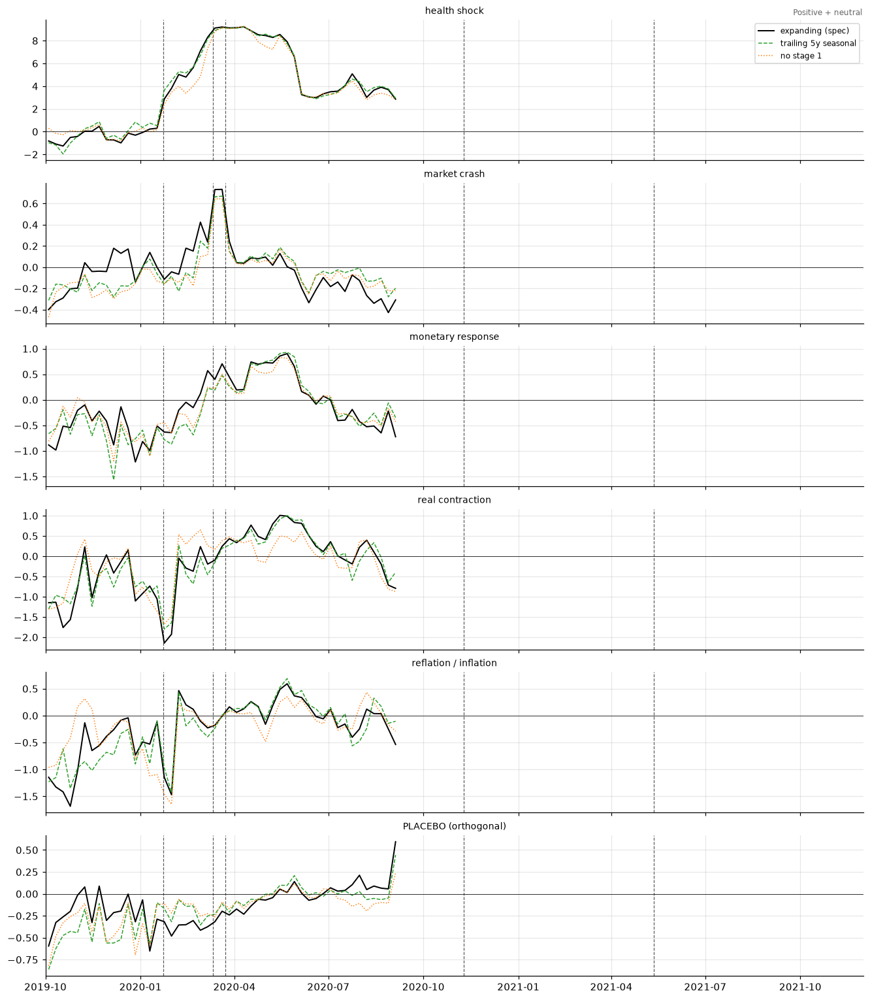

In [56]:
variants = {"expanding (spec)": panel,
            f"trailing {SEASONAL_YEARS_ROBUST}y seasonal": post_process(daily, seasonal_years=SEASONAL_YEARS_ROBUST),
            "no stage 1": post_process(daily, deseason=False)}
ref = panel.select("WEEK", KEY, "COMPOSITE")
for name, p in list(variants.items())[1:]:
    j = ref.join(p.select("WEEK", KEY, pl.col("COMPOSITE").alias("ALT")), on=["WEEK", KEY]).drop_nulls()
    j = j.filter(pl.col("WEEK").is_between(*VIEW))
    print(f"corr(C spec, C {name}) over the window = {np.corrcoef(j['COMPOSITE'], j['ALT'])[0, 1]:.3f}")

show = [b for b in ("health shock", "market crash", "monetary response", "real contraction",
                    "reflation / inflation", PLACEBO) if b in blist]
fig, axes = plt.subplots(len(show), 1, figsize=(12, 2.3 * len(show)), sharex=True)
styles = {"expanding (spec)": ("k", "-", 1.3), f"trailing {SEASONAL_YEARS_ROBUST}y seasonal": ("tab:green", "--", 1),
          "no stage 1": ("tab:orange", ":", 1)}
for name, p in variants.items():
    _, _, b_ = battery_frame(p, "COMPOSITE", {b: BKEYS[b] for b in show})
    b_ = b_.filter(pl.col("WEEK").is_between(*VIEW))
    for ax, b in zip(np.atleast_1d(axes), show):
        c, ls, lw = styles[name]
        ax.plot(b_["WEEK"], b_[b], color=c, ls=ls, lw=lw, label=name)
for ax, b in zip(np.atleast_1d(axes), show):
    ax.axhline(0, color="k", lw=0.5); ax.set_title(b, fontsize=9); date_axis(ax); shade_events(ax, labels=False)
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.show()

In [57]:
# summary per battery: baseline vs Covid phases
phases_ = {"baseline": BASELINE, "shock (Feb–May 20)": (date(2020, 2, 17), date(2020, 5, 31)),
           "vaccine (Nov 20–Mar 21)": (date(2020, 11, 1), date(2021, 3, 31)),
           "reflation (Apr–Nov 21)": (date(2021, 4, 1), VIEW[1])}
summ = []
for b in blist:
    r = {"battery": b}
    for name, (lo_, hi_) in phases_.items():
        r[f"C {name}"] = bat.filter(pl.col("WEEK").is_between(lo_, hi_))[b].mean()
    r["max z (window)"] = batz.filter(pl.col("WEEK").is_between(*VIEW))[b].max()
    summ.append(r)
pl.DataFrame(summ).with_columns(pl.selectors.float().round(2))

battery,C baseline,C shock (Feb–May 20),C vaccine (Nov 20–Mar 21),C reflation (Apr–Nov 21),max z (window)
str,f64,f64,null,null,f64
"""health shock""",-0.02,8.27,null,null,13.94
"""lockdown / state control""",0.15,0.44,null,null,2.37
"""market crash""",-0.07,0.2,null,null,2.83
"""dash for cash / funding""",0.02,0.19,null,null,1.41
"""monetary response""",0.02,0.52,null,null,2.25
"""fiscal response""",-0.01,0.47,null,null,1.71
"""real contraction""",-0.13,0.42,null,null,1.44
"""corporate distress""",0.07,0.1,null,null,0.54
"""oil / demand collapse""",-0.18,0.11,null,null,0.89


# Part D: Positive — labels pos


In [58]:
STUDY = "Positive"
daily = study_daily(STUDIES[STUDY])
print(f"{STUDY}: {daily.height:,} rows | {daily['DATE'].n_unique():,} days | "
      f"{daily[KEY].n_unique()} narratives | {daily['DATE'].min()} .. {daily['DATE'].max()}")
dup = daily.group_by("DATE", KEY).len().filter(pl.col("len") > 1).height
assert dup == 0, f"{dup} duplicated (DATE, {KEY}) rows"


Positive: 2,744,544 rows | 7,458 days | 368 narratives | 2000-04-01 .. 2020-08-31


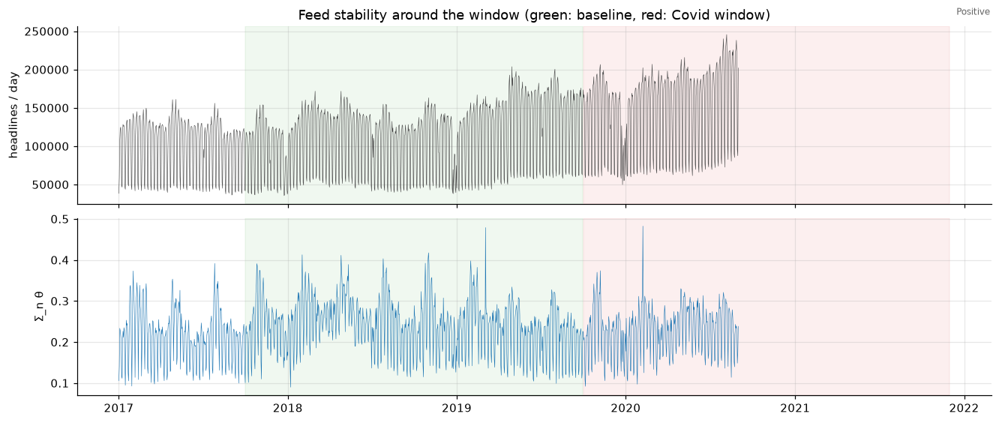

Y,headlines/day,mean Σθ
i32,f64,f64
2017,98757.0,0.219
2018,106540.0,0.25
2019,128253.0,0.224
2020,152220.0,0.232


In [59]:
flow = (daily.filter(pl.col("DATE").is_between(date(2017, 1, 1), VIEW[1]))
        .group_by("DATE").agg(pl.col("N_HEADLINES").first(), pl.col("THETA").sum().alias("SUM_THETA"))
        .sort("DATE"))
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(flow["DATE"], flow["N_HEADLINES"], lw=0.4, color="0.3"); axes[0].set_ylabel("headlines / day")
axes[1].plot(flow["DATE"], flow["SUM_THETA"], lw=0.4, color="tab:blue"); axes[1].set_ylabel("Σ_n θ")
for ax in axes:
    ax.axvspan(*WINDOW, color="tab:red", alpha=0.07); ax.axvspan(*BASELINE, color="tab:green", alpha=0.07)
axes[0].set_title("Feed stability around the window (green: baseline, red: Covid window)")
plt.show()
yr = (flow.with_columns(pl.col("DATE").dt.year().alias("Y")).group_by("Y")
      .agg(pl.col("N_HEADLINES").mean().round(0).alias("headlines/day"),
           pl.col("SUM_THETA").mean().round(3).alias("mean Σθ")).sort("Y"))
yr

## D.2. Post-processing pipeline (stages 1–5)


In [60]:
def deseasonalise(daily: pl.DataFrame, min_prior_years: int = MIN_PRIOR_YEARS,
                  seasonal_years: int | None = SEASONAL_YEARS) -> pl.DataFrame:
    # stage 1: subtract the prior-years-only week-of-year mean (expanding, or trailing N years)
    d = daily.with_columns(pl.col("DATE").dt.iso_year().alias("YEAR"),
                           pl.col("DATE").dt.week().clip(1, 52).alias("WOY"))
    yw = (d.group_by(KEY, "YEAR", "WOY").agg(pl.col("THETA").mean().alias("YW_MEAN"))
          .sort(KEY, "WOY", "YEAR")
          .with_columns(pl.col("YW_MEAN").is_not_null().cast(pl.Int32).alias("_has"),
                        pl.col("YW_MEAN").fill_null(0.0).alias("_v")))
    if seasonal_years is None:
        yw = yw.with_columns(pl.col("_v").cum_sum().shift(1).over(KEY, "WOY").alias("_psum"),
                             pl.col("_has").cum_sum().shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
    else:
        n = int(seasonal_years)
        yw = yw.with_columns(
            pl.col("_v").rolling_sum(n, min_samples=1).shift(1).over(KEY, "WOY").alias("_psum"),
            pl.col("_has").rolling_sum(n, min_samples=1).shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
    yw = (yw.with_columns(pl.when(pl.col("N_PRIOR_YEARS") >= min_prior_years)
                          .then(pl.col("_psum") / pl.col("N_PRIOR_YEARS")).otherwise(None).alias("SEAS"))
          .select(KEY, "YEAR", "WOY", "SEAS", "N_PRIOR_YEARS"))
    return (d.join(yw, on=[KEY, "YEAR", "WOY"], how="left")
            .with_columns((pl.col("THETA") - pl.col("SEAS")).alias("THETA_DS")))


def weekly(d: pl.DataFrame) -> pl.DataFrame:
    # stage 2: Mon-Fri mean, stamped on the Friday, on a complete (week x key) grid
    w = (d.filter(pl.col("DATE").dt.weekday() <= 5)
         .with_columns((pl.col("DATE").dt.truncate("1w") + timedelta(days=4)).alias("WEEK"))
         .group_by(KEY, "WEEK")
         .agg(pl.col("THETA_DS").mean().alias("THETA_W"), pl.col("THETA").mean().alias("THETA_RAW_W"),
              pl.col("THETA").count().alias("N_DAYS")))
    grid = pl.DataFrame({"WEEK": pl.date_range(w["WEEK"].min(), w["WEEK"].max(), "1w", eager=True)}).join(
        w.select(KEY).unique(), how="cross")
    return grid.join(w, on=[KEY, "WEEK"], how="left").sort(KEY, "WEEK")


def changes_and_horizons(w: pl.DataFrame, value: str = "THETA_W", horizons=ALL_H) -> pl.DataFrame:
    # stage 3 (first difference) + stage 4 (backward rolling mean over h weeks, full windows only)
    w = w.with_columns(pl.col(value).diff().over(KEY).alias("DTHETA"))
    return w.with_columns([pl.col("DTHETA").rolling_mean(h, min_samples=h).over(KEY).alias(f"D{h}")
                           for h in horizons])


def composite(w: pl.DataFrame, all_h=ALL_H) -> pl.DataFrame:
    # stage 5: each horizon / its own cross-sectional std (ddof=0, NOT demeaned), averaged over H
    w = w.with_columns([(pl.col(f"D{h}") / pl.col(f"D{h}").std(ddof=0).over("WEEK")).alias(f"Z{h}")
                        for h in all_h])

    def avg(hs, name):
        z = [pl.col(f"Z{h}") for h in hs]
        ok = pl.all_horizontal([c.is_not_null() & c.is_finite() for c in z])
        return pl.when(ok).then(pl.sum_horizontal(z) / len(z)).otherwise(None).alias(name)

    return w.with_columns(avg(COMPOSITE_H, "COMPOSITE"), avg(COMPOSITE_SHORT_H, "COMPOSITE_S"))


def post_process(daily: pl.DataFrame, deseason: bool = True, seasonal_years=SEASONAL_YEARS) -> pl.DataFrame:
    d = (deseasonalise(daily, seasonal_years=seasonal_years) if deseason
         else daily.with_columns(pl.col("THETA").alias("THETA_DS")))
    return composite(changes_and_horizons(weekly(d)))


daily_ds = deseasonalise(daily)
panel = composite(changes_and_horizons(weekly(daily_ds)))
print(f"{panel.height:,} (week x narrative) rows | weeks {panel['WEEK'].min()} .. {panel['WEEK'].max()}")
cs = panel.filter(pl.col("COMPOSITE").is_not_null())
for h in COMPOSITE_H:
    s = cs.group_by("WEEK").agg(pl.col(f"Z{h}").std(ddof=0))[f"Z{h}"]
    assert np.allclose(s.to_numpy(), 1.0, atol=1e-6), h
print("σ^(h) normalisation holds; window weeks with a composite:",
      cs.filter(pl.col("WEEK").is_between(*VIEW))["WEEK"].n_unique())

392,288 (week x narrative) rows | weeks 2000-04-07 .. 2020-09-04
σ^(h) normalisation holds; window weeks with a composite: 49


### D.2.1 Stage-by-stage walk-through on the pandemic narrative


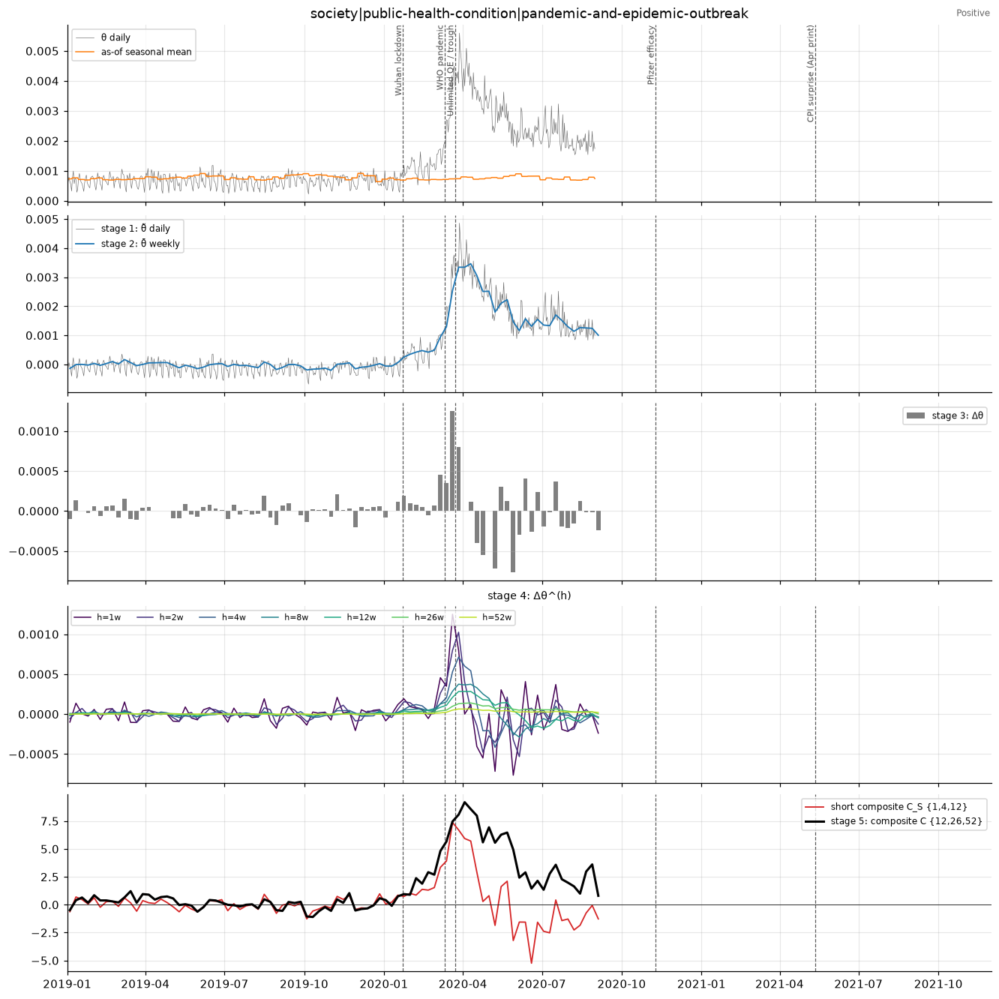

In [61]:
k0 = NAME_TO_KEYS[SHOWCASE][0]
lo = date(2019, 1, 1)
dd = daily_ds.filter((pl.col(KEY) == k0) & pl.col("DATE").is_between(lo, VIEW[1]))
pp = panel.filter((pl.col(KEY) == k0) & pl.col("WEEK").is_between(lo, VIEW[1]))

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(dd["DATE"], dd["THETA"], lw=0.4, color="0.4", label="θ daily")
axes[0].plot(dd["DATE"], dd["SEAS"], lw=1.0, color="tab:orange", label="as-of seasonal mean")
axes[0].set_title(k0); axes[0].legend(loc="upper left", fontsize=8)
axes[1].plot(dd["DATE"], dd["THETA_DS"], lw=0.4, color="0.4", label="stage 1: θ̃ daily")
axes[1].plot(pp["WEEK"], pp["THETA_W"], lw=1.2, color="tab:blue", label="stage 2: θ̄ weekly")
axes[1].legend(loc="upper left", fontsize=8)
axes[2].bar(pp["WEEK"], pp["DTHETA"], width=5, color="0.5", label="stage 3: Δθ"); axes[2].legend(fontsize=8)
for h, c in zip(ALL_H, plt.cm.viridis(np.linspace(0, 0.9, len(ALL_H)))):
    axes[3].plot(pp["WEEK"], pp[f"D{h}"], lw=1.0, color=c, label=f"h={h}w")
axes[3].set_title("stage 4: Δθ^(h)", fontsize=9); axes[3].legend(ncol=len(ALL_H), fontsize=7, loc="upper left")
axes[4].plot(pp["WEEK"], pp["COMPOSITE_S"], lw=1.2, color="tab:red", label="short composite C_S {1,4,12}")
axes[4].plot(pp["WEEK"], pp["COMPOSITE"], lw=2.0, color="k", label="stage 5: composite C {12,26,52}")
axes[4].axhline(0, color="k", lw=0.5); axes[4].legend(fontsize=8, loc="upper right")
for ax in axes:
    date_axis(ax, lo, VIEW[1]); shade_events(ax, labels=ax is axes[0])
plt.show()

## D.3. Composite properties over the window


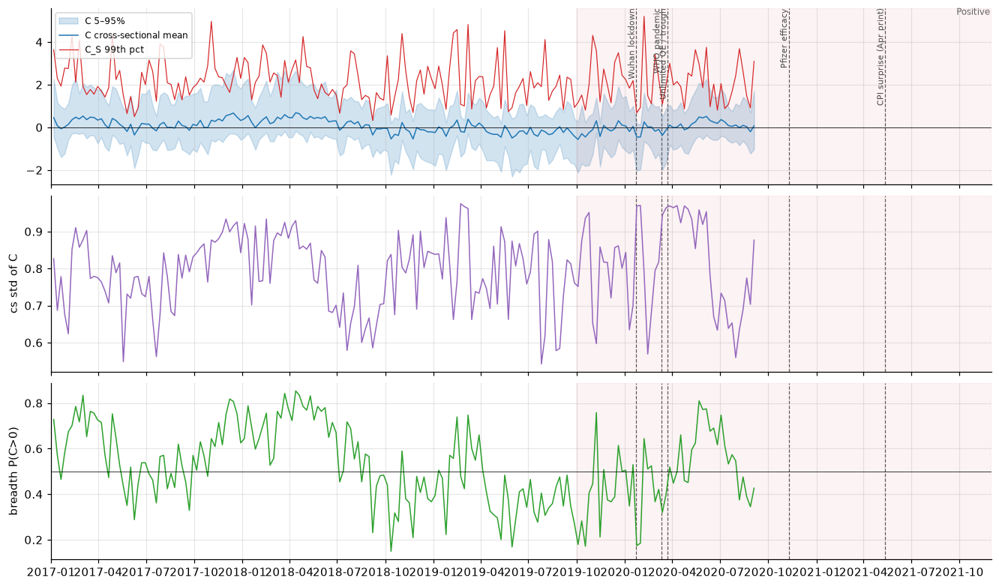

In [62]:
xs = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(date(2017, 1, 1), VIEW[1]))
      .group_by("WEEK")
      .agg(pl.col("COMPOSITE").mean().alias("MEAN"), pl.col("COMPOSITE").std(ddof=0).alias("STD"),
           (pl.col("COMPOSITE") > 0).mean().alias("BREADTH"),
           pl.col("COMPOSITE").quantile(0.95).alias("Q95"), pl.col("COMPOSITE").quantile(0.05).alias("Q05"),
           pl.col("COMPOSITE_S").quantile(0.99).alias("QS99"))
      .sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].fill_between(xs["WEEK"], xs["Q05"], xs["Q95"], color="tab:blue", alpha=0.2, label="C 5–95%")
axes[0].plot(xs["WEEK"], xs["MEAN"], color="tab:blue", lw=1, label="C cross-sectional mean")
axes[0].plot(xs["WEEK"], xs["QS99"], color="tab:red", lw=0.8, label="C_S 99th pct")
axes[0].axhline(0, color="k", lw=0.5); axes[0].legend(fontsize=8, loc="upper left")
axes[1].plot(xs["WEEK"], xs["STD"], color="tab:purple", lw=1); axes[1].set_ylabel("cs std of C")
axes[2].plot(xs["WEEK"], xs["BREADTH"], color="tab:green", lw=1); axes[2].axhline(0.5, color="k", lw=0.5)
axes[2].set_ylabel("breadth P(C>0)")
for ax in axes:
    date_axis(ax, date(2017, 1, 1), VIEW[1]); ax.axvspan(*WINDOW, color="tab:red", alpha=0.05)
    shade_events(ax, labels=ax is axes[0])
plt.show()

## D.4. Predeclared Covid batteries


In [63]:
name_to_keys = NAME_TO_KEYS     # narrative names, pole names mapped to their merged narrative
print("pole entries (now the whole merged narrative):",
      {b: pole_entries(ns) for b, ns in BATTERIES.items() if pole_entries(ns)})
_placebo = {k for n in BATTERIES[PLACEBO] for k in NAME_TO_KEYS.get(n, [])}
_stress = {k for b, ns in BATTERIES.items() if b != PLACEBO for n in ns for k in NAME_TO_KEYS.get(n, [])}
assert not _placebo & _stress, f"placebo shares merged narratives with other batteries: {sorted(_placebo & _stress)}"
BATTERIES_STUDY = {b: ns + PLACEBO_BY_STUDY.get(STUDY, []) if b == PLACEBO else ns
                   for b, ns in BATTERIES.items()}
if PLACEBO_BY_STUDY.get(STUDY):
    print(f"{STUDY}: placebo adds {PLACEBO_BY_STUDY[STUDY]} (this study only; same merged "
          f"narratives as stress entries, read on the {'+'.join(STUDIES[STUDY])} label)")
BKEYS = {}
for b, names in BATTERIES_STUDY.items():
    missing = [n for n in names if n not in name_to_keys]
    if missing:
        print(f"[{b}] names not in the taxonomy: {missing}")
    BKEYS[b] = list(dict.fromkeys(k for n in names for k in name_to_keys.get(n, [])))   # two poles of one pair: one merged key
print({b: len(k) for b, k in BKEYS.items()})
blist = [b for b in BKEYS if BKEYS[b]]


def battery_frame(panel, col, bkeys):
    wide = panel.filter(pl.col(col).is_not_null()).pivot(on=KEY, index="WEEK", values=col).sort("WEEK")
    m = wide.drop("WEEK")
    return wide["WEEK"], m, pl.DataFrame({"WEEK": wide["WEEK"], **{
        b: np.nanmean(m.select([k for k in ks if k in m.columns]).to_numpy(), axis=1)
        for b, ks in bkeys.items() if ks}})


WEEKS, C, bat = battery_frame(panel, "COMPOSITE", BKEYS)
WEEKS_S, CS, bat_s = battery_frame(panel, "COMPOSITE_S", BKEYS)
base = bat.filter(pl.col("WEEK").is_between(*BASELINE))
batz = bat.with_columns([((pl.col(b) - base[b].mean()) / base[b].std()).alias(b) for b in blist])
v = bat.filter(pl.col("WEEK").is_between(*VIEW)); v_s = bat_s.filter(pl.col("WEEK").is_between(*VIEW))
print(f"baseline {BASELINE[0]} .. {BASELINE[1]}: {base.height} weeks")

pole entries (now the whole merged narrative): {'health shock': ['public-health-deterioration'], 'lockdown / state control': ['state-direction-expansion'], 'monetary response': ['balance-sheet-expansion', 'global-liquidity-easing'], 'real contraction': ['business-cycle-contraction', 'labour-market-slackening', 'guidance-cut', 'dividend-cut'], 'corporate distress': ['credit-deterioration', 'rating-downgrade'], 'oil / demand collapse': ['demand-destruction', 'demand-driven-price-collapse', 'curve-contango'], 'vaccine / health recovery': ['public-health-improvement'], 'reopening / recovery': ['business-cycle-expansion', 'capex-upswing'], 'reflation / inflation': ['price-level-change-reflation', 'labour-market-tightening', 'input-cost-squeeze'], 'PLACEBO (orthogonal)': ['allowance-cap-tightening', 'allowance-cap-loosening']}
{'health shock': 3, 'lockdown / state control': 3, 'market crash': 7, 'dash for cash / funding': 7, 'monetary response': 7, 'fiscal response': 4, 'real contraction': 7

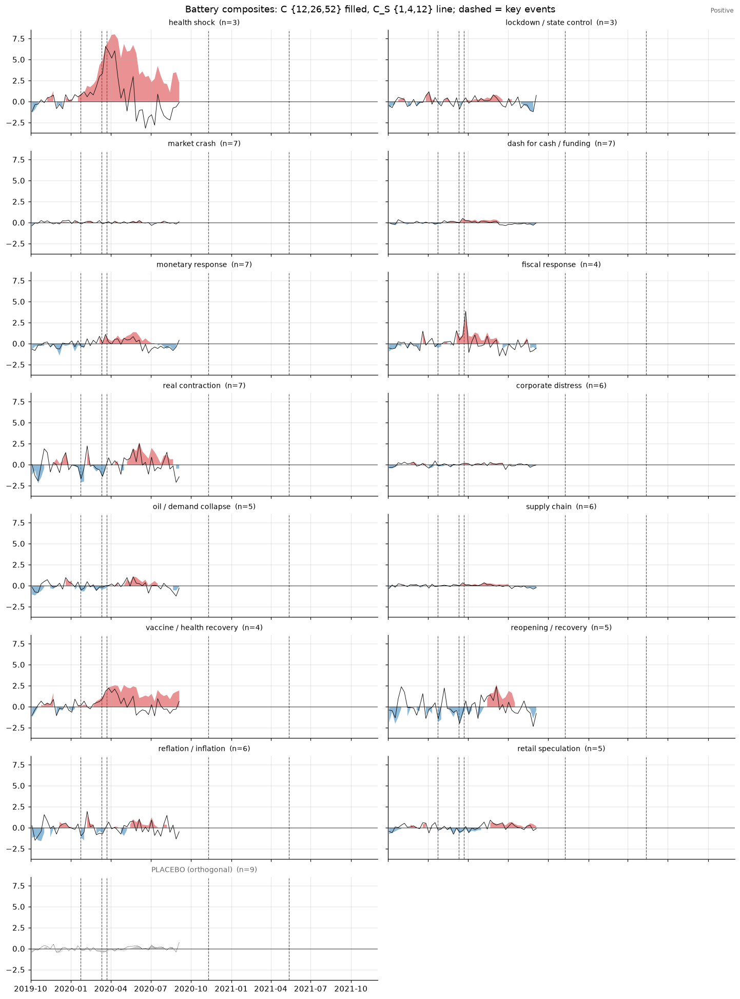

In [64]:
ncol = 2
nrow = int(np.ceil(len(blist) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.2 * nrow), sharex=True, sharey=True)
for ax, b in zip(axes.flat, blist):
    y = v[b].to_numpy()
    diag = b in DIAGNOSTIC
    ax.fill_between(v["WEEK"], 0, y, where=y > 0, color="0.6" if diag else "tab:red", alpha=0.5, lw=0)
    ax.fill_between(v["WEEK"], 0, y, where=y < 0, color="0.8" if diag else "tab:blue", alpha=0.5, lw=0)
    ax.plot(v_s["WEEK"], v_s[b], color="k", lw=0.6, ls=":" if diag else "-", label="C_S")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{b}  (n={len(BKEYS[b])})", fontsize=9, color="0.4" if diag else "k")
    date_axis(ax)
for ax in axes.flat[len(blist):]:
    ax.axis("off")
for ax in axes.flat[:len(blist)]:
    shade_events(ax, labels=False)
fig.suptitle("Battery composites: C {12,26,52} filled, C_S {1,4,12} line; dashed = key events")
plt.show()

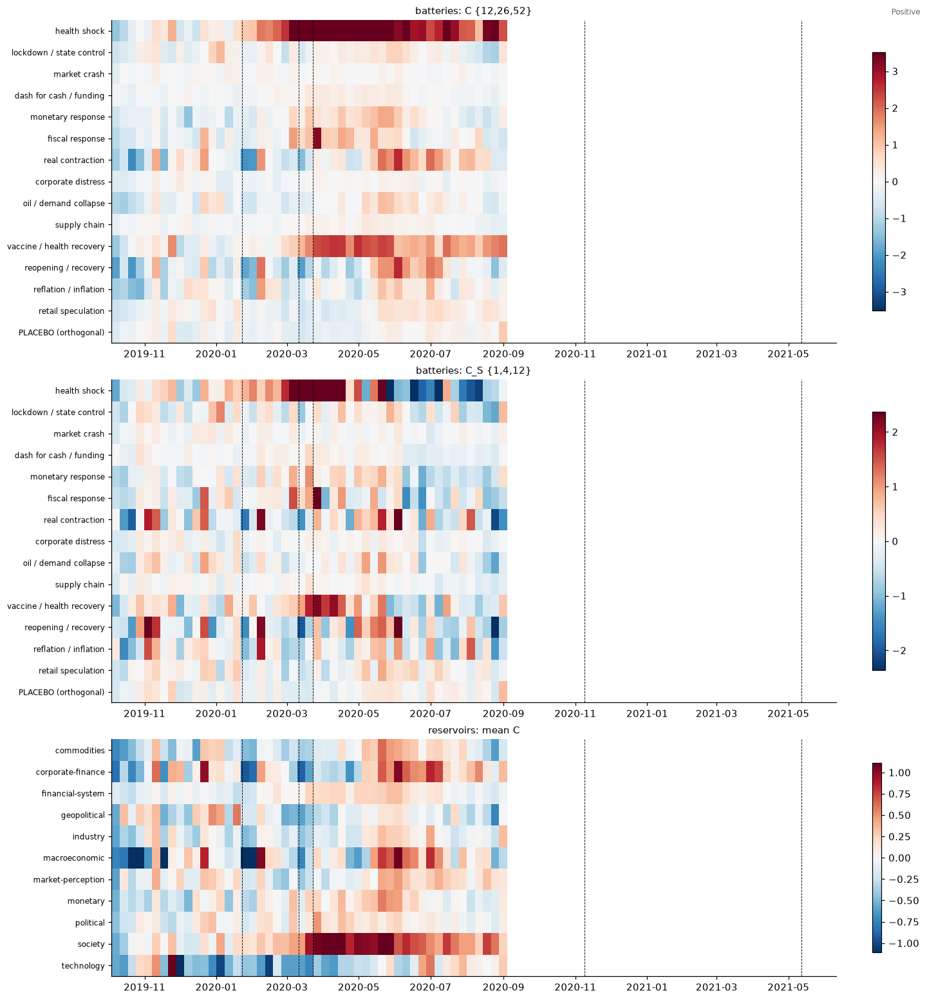

In [65]:
def heat(ax, frame, rows, title, vmax=None):
    m = frame.select(rows).to_numpy().T
    vmax = vmax or np.nanpercentile(np.abs(m), 98)
    x = mdates.date2num(frame["WEEK"].to_list())
    im = ax.imshow(m, aspect="auto", cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax),
                   extent=[x[0], x[-1], len(rows) - 0.5, -0.5], interpolation="nearest")
    ax.set_yticks(range(len(rows)), rows, fontsize=8); ax.xaxis_date(); ax.grid(False)
    for name in KEY_EVENTS:
        ax.axvline(EVENTS[name], color="k", lw=0.6, ls="--")
    ax.set_title(title, fontsize=10)
    return im


res = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(*VIEW))
       .join(NARR.select(KEY, "reservoir"), on=KEY)
       .group_by("WEEK", "reservoir").agg(pl.col("COMPOSITE").mean())
       .pivot(on="reservoir", index="WEEK", values="COMPOSITE").sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(13, 14), height_ratios=[len(blist), len(blist), res.width - 1])
fig.colorbar(heat(axes[0], v, blist, "batteries: C {12,26,52}"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], v_s, blist, "batteries: C_S {1,4,12}"), ax=axes[1], shrink=0.8)
fig.colorbar(heat(axes[2], res, sorted(res.columns[1:]), "reservoirs: mean C"), ax=axes[2], shrink=0.8)
plt.show()

### D.4.1 Event table: permutation test and block-bootstrap baseline band


In [66]:
wk_arr = np.array(WEEKS.to_list())
col_of = {k: i for i, k in enumerate(C.columns)}
Cn = C.to_numpy()


def event_week(d):
    return min(int(np.searchsorted(wk_arr, d)), len(wk_arr) - 1)


def perm_p(row, idx, n_perm=N_PERM):
    # vectorised: n_perm random subsets of size k without replacement (argpartition of uniforms)
    x = row[~np.isnan(row)]
    obs = np.nanmean(row[idx])
    k = len(idx)
    pick = np.argpartition(RNG.random((n_perm, len(x))), k, axis=1)[:, :k]
    draws = x[pick].mean(axis=1)
    return obs, (1 + (draws >= obs).sum()) / (n_perm + 1)


def boot_block_max(series, n_boot=N_BOOT, block=BLOCK_WEEKS):
    # distribution of the max of one block drawn from the baseline series (moving-block bootstrap)
    s = series[~np.isnan(series)]
    starts = RNG.integers(0, len(s) - block + 1, n_boot)
    return np.array([s[i:i + block].max() for i in starts])


boot = {b: boot_block_max(base[b].to_numpy()) for b in blist}
rows = []
for ev, d in EVENTS.items():
    if not (VIEW[0] <= d <= VIEW[1]):
        continue
    i = event_week(d)
    i_s = min(int(np.searchsorted(np.array(WEEKS_S.to_list()), d)), bat_s.height - 1)
    for b in blist:
        idx = np.array([col_of[k] for k in BKEYS[b] if k in col_of])
        obs, p = perm_p(Cn[i], idx)
        rows.append({"event": ev, "week": wk_arr[i], "battery": b, "C": obs, "C_S": bat_s[b][i_s],
                     "z_vs_baseline": batz[b][i], "perm_p": p,
                     "boot_p": (1 + (boot[b] >= obs).sum()) / (N_BOOT + 1)})
ev_tab = pl.DataFrame(rows)
for col, dig in (("C", 2), ("C_S", 2), ("perm_p", 3), ("boot_p", 3)):
    print(col)
    display(ev_tab.pivot(on="event", index="battery", values=col).with_columns(pl.selectors.float().round(dig)))

C


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.3,0.93,2.55,4.32,4.95,6.59,7.19,7.19,5.14,2.26,2.26,2.26,2.26,2.26,2.26
"""lockdown / state control""",1.16,-0.27,-0.8,0.28,-0.6,-0.18,0.21,0.21,0.2,0.46,0.46,0.46,0.46,0.46,0.46
"""market crash""",-0.16,-0.08,-0.09,0.19,-0.04,0.02,0.09,0.09,-0.03,0.03,0.03,0.03,0.03,0.03,0.03
"""dash for cash / funding""",-0.03,-0.15,0.13,0.09,0.05,0.38,0.31,0.31,0.12,-0.04,-0.04,-0.04,-0.04,-0.04,-0.04
"""monetary response""",-0.0,-0.33,-0.07,0.73,0.17,0.92,0.51,0.51,0.45,0.26,0.26,0.26,0.26,0.26,0.26
"""fiscal response""",-0.61,-0.48,-0.0,1.46,0.7,1.02,3.2,3.2,1.16,-0.69,-0.69,-0.69,-0.69,-0.69,-0.69
"""real contraction""",-0.05,-2.11,-0.82,-0.54,-1.52,-0.58,0.24,0.24,-0.76,-0.47,-0.47,-0.47,-0.47,-0.47,-0.47
"""corporate distress""",-0.39,-0.21,-0.1,-0.08,-0.12,0.06,0.16,0.16,0.11,-0.06,-0.06,-0.06,-0.06,-0.06,-0.06
"""oil / demand collapse""",0.6,-0.66,-0.66,-0.3,-0.46,-0.33,-0.08,-0.08,-0.07,-0.12,-0.12,-0.12,-0.12,-0.12,-0.12


C_S


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.14,0.8,1.78,2.98,3.35,6.56,5.94,5.94,0.38,-0.11,-0.11,-0.11,-0.11,-0.11,-0.11
"""lockdown / state control""",1.17,-0.15,-0.62,0.45,-0.89,-0.04,0.44,0.44,-0.02,0.74,0.74,0.74,0.74,0.74,0.74
"""market crash""",-0.13,-0.18,-0.04,0.23,-0.16,-0.01,0.1,0.1,-0.08,0.11,0.11,0.11,0.11,0.11,0.11
"""dash for cash / funding""",-0.07,-0.07,0.14,0.03,0.0,0.5,0.22,0.22,-0.06,-0.04,-0.04,-0.04,-0.04,-0.04,-0.04
"""monetary response""",0.32,-0.32,0.05,0.87,0.04,1.1,0.17,0.17,-0.1,0.41,0.41,0.41,0.41,0.41,0.41
"""fiscal response""",0.26,-0.04,-0.21,1.54,0.43,0.91,3.86,3.86,-0.32,-0.55,-0.55,-0.55,-0.55,-0.55,-0.55
"""real contraction""",-0.06,-1.69,-0.48,-0.62,-1.41,-0.31,0.81,0.81,-1.16,-1.45,-1.45,-1.45,-1.45,-1.45,-1.45
"""corporate distress""",-0.43,-0.18,0.04,-0.05,-0.03,0.13,0.16,0.16,0.11,-0.05,-0.05,-0.05,-0.05,-0.05,-0.05
"""oil / demand collapse""",0.23,-0.53,-0.57,-0.17,-0.19,-0.02,0.01,0.01,-0.13,-0.29,-0.29,-0.29,-0.29,-0.29,-0.29


perm_p


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.265,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001,0.001,0.001,0.001,0.001,0.001
"""lockdown / state control""",0.022,0.463,0.923,0.138,0.74,0.576,0.263,0.263,0.14,0.189,0.191,0.19,0.19,0.189,0.191
"""market crash""",0.781,0.058,0.373,0.145,0.122,0.284,0.404,0.401,0.38,0.517,0.518,0.517,0.514,0.511,0.509
"""dash for cash / funding""",0.628,0.136,0.14,0.228,0.073,0.06,0.169,0.17,0.164,0.605,0.601,0.597,0.6,0.601,0.6
"""monetary response""",0.589,0.49,0.332,0.012,0.05,0.023,0.095,0.097,0.042,0.256,0.257,0.257,0.256,0.262,0.255
"""fiscal response""",0.958,0.713,0.287,0.002,0.021,0.024,0.0,0.0,0.019,0.979,0.98,0.978,0.979,0.978,0.979
"""real contraction""",0.651,0.998,0.984,0.937,0.997,0.925,0.224,0.219,0.95,0.969,0.97,0.969,0.971,0.971,0.969
"""corporate distress""",0.92,0.267,0.387,0.467,0.212,0.243,0.299,0.298,0.183,0.611,0.617,0.611,0.616,0.613,0.609
"""oil / demand collapse""",0.079,0.776,0.919,0.755,0.641,0.732,0.692,0.693,0.472,0.671,0.671,0.673,0.67,0.672,0.668


boot_p


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.934,0.362,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""lockdown / state control""",0.228,1.0,1.0,0.736,1.0,1.0,0.896,0.896,0.896,0.563,0.563,0.563,0.563,0.563,0.563
"""market crash""",1.0,1.0,1.0,0.784,1.0,0.937,0.844,0.844,1.0,0.937,0.937,0.937,0.937,0.937,0.937
"""dash for cash / funding""",1.0,1.0,0.695,0.888,0.899,0.185,0.273,0.273,0.888,1.0,1.0,1.0,1.0,1.0,1.0
"""monetary response""",1.0,1.0,1.0,0.478,0.968,0.084,0.613,0.613,0.632,0.894,0.894,0.894,0.894,0.894,0.894
"""fiscal response""",1.0,1.0,0.993,0.243,0.585,0.375,0.076,0.076,0.305,1.0,1.0,1.0,1.0,1.0,1.0
"""real contraction""",0.953,1.0,1.0,1.0,1.0,1.0,0.768,0.768,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""corporate distress""",1.0,0.925,0.881,0.835,0.907,0.562,0.552,0.552,0.552,0.798,0.798,0.798,0.798,0.798,0.798
"""oil / demand collapse""",0.576,1.0,1.0,0.957,0.983,0.983,0.837,0.837,0.827,0.837,0.837,0.837,0.837,0.837,0.837


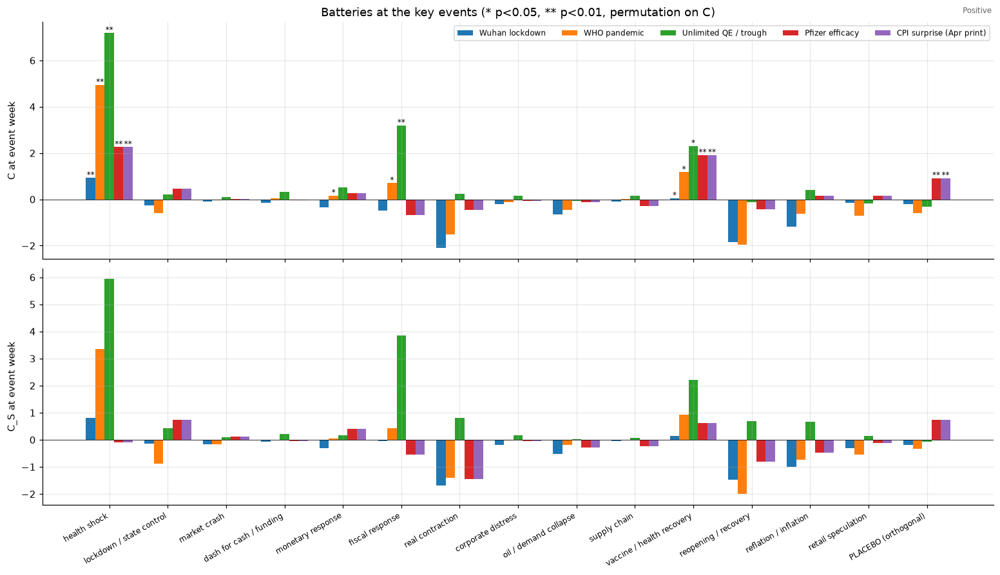

In [67]:
pz = ev_tab.filter(pl.col("event").is_in(list(KEY_EVENTS)))
evs = [e for e in KEY_EVENTS if e in pz["event"].unique().to_list()]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, col in zip(axes, ("C", "C_S")):
    wbar = 0.8 / max(len(evs), 1)
    for j, e in enumerate(evs):
        g = pz.filter(pl.col("event") == e).sort(pl.col("battery").replace_strict({b: i for i, b in enumerate(blist)}))
        xs_ = np.arange(len(blist)) + j * wbar
        ax.bar(xs_, g[col], width=wbar, label=e)
        if col == "C":
            for x_, c_, p_ in zip(xs_, g["C"], g["perm_p"]):
                if p_ < 0.05:
                    ax.text(x_, c_ + (0.03 if c_ >= 0 else -0.12), "*" if p_ >= 0.01 else "**",
                            ha="center", fontsize=8)
    ax.axhline(0, color="k", lw=0.5); ax.set_ylabel(f"{col} at event week")
axes[1].set_xticks(np.arange(len(blist)) + 0.4 - wbar / 2, blist, rotation=30, ha="right", fontsize=8)
axes[0].legend(fontsize=8, ncol=len(evs)); axes[0].set_title("Batteries at the key events (* p<0.05, ** p<0.01, permutation on C)")
plt.show()

## D.5. Horizon term structure at the key events


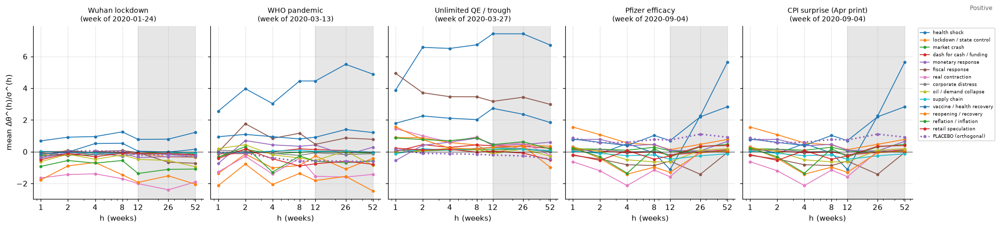

In [68]:
term = panel.select("WEEK", KEY, *[f"Z{h}" for h in ALL_H])
fig, axes = plt.subplots(1, len(KEY_EVENTS), figsize=(18, 4), sharey=True)
for ax, e in zip(axes, KEY_EVENTS):
    wk = wk_arr[event_week(EVENTS[e])]
    t = term.filter(pl.col("WEEK") == wk)
    for b in blist:
        g = t.filter(pl.col(KEY).is_in(BKEYS[b])).select([pl.col(f"Z{h}").mean() for h in ALL_H]).row(0)
        diag = b in DIAGNOSTIC
        ax.plot(ALL_H, g, marker="o", ms=3, lw=2 if diag else 1.1, ls=":" if diag else "-", label=b)
    ax.axhline(0, color="k", lw=0.5); ax.set_xscale("log"); ax.set_xticks(ALL_H, [str(h) for h in ALL_H])
    ax.axvspan(min(COMPOSITE_H), max(COMPOSITE_H), color="0.9", zorder=0)
    ax.set_title(f"{e}\n(week of {wk})", fontsize=9); ax.set_xlabel("h (weeks)")
axes[0].set_ylabel("mean Δθ^(h)/σ^(h)")
axes[-1].legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## D.6. Unsupervised cross-sections


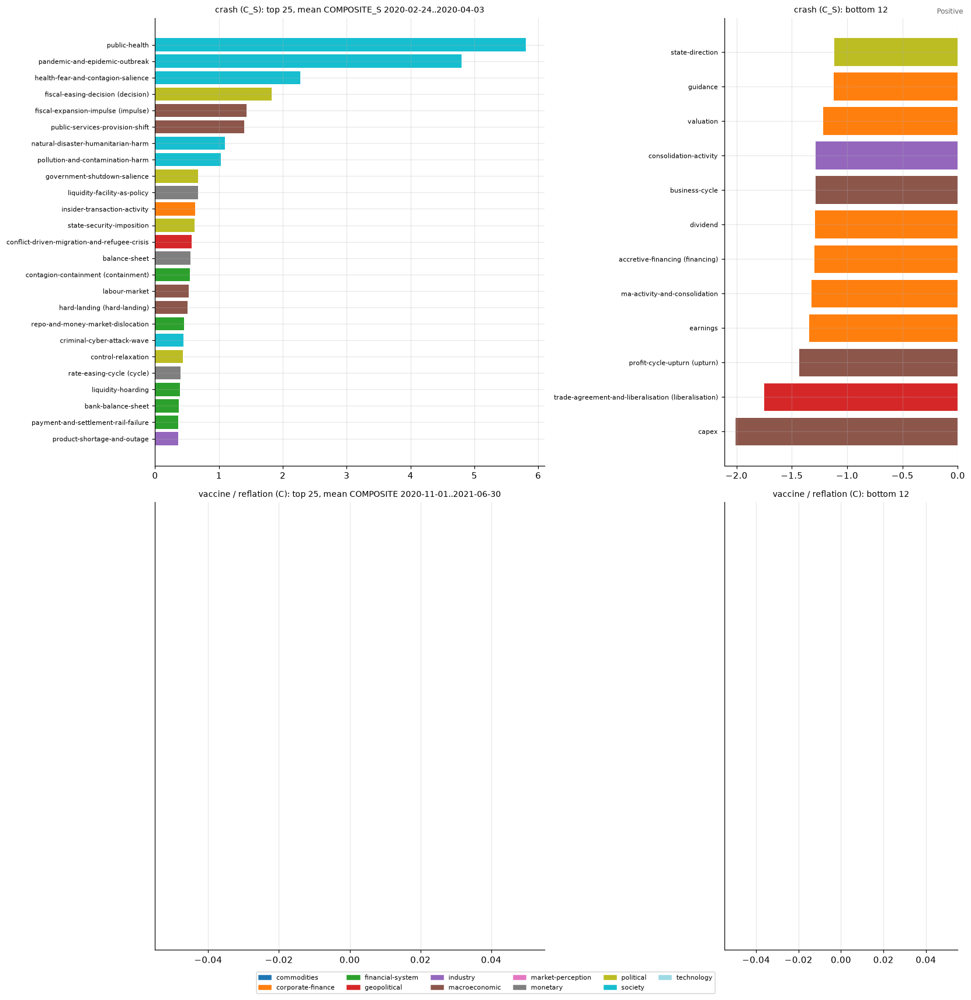

In [70]:
resv = sorted(NARR["reservoir"].unique().to_list())
cmap = dict(zip(resv, plt.cm.tab20(np.linspace(0, 1, len(resv)))))
in_b = {k for b in blist if b not in DIAGNOSTIC for k in BKEYS[b]}


def ranked(col, lo, hi):
    return (panel.filter(pl.col("WEEK").is_between(lo, hi) & pl.col(col).is_not_null())
            .group_by(KEY).agg(pl.col(col).mean().alias("V")).join(NARR, on=KEY).sort("V", descending=True))


def barplot(ax, t, title):
    lab = [f"{r['narrative']} ({r['pole']})" if r["pole"] else r["narrative"] for r in t.iter_rows(named=True)]
    ax.barh(range(t.height), t["V"], color=[cmap[r] for r in t["reservoir"]])
    ax.set_yticks(range(t.height), lab, fontsize=7); ax.invert_yaxis(); ax.set_title(title, fontsize=9)


phases = {"crash (C_S)": ("COMPOSITE_S", date(2020, 2, 24), date(2020, 4, 3)),
          "vaccine / reflation (C)": ("COMPOSITE", date(2020, 11, 1), date(2021, 6, 30))}
fig, axes = plt.subplots(2, 2, figsize=(15, 15), width_ratios=[5, 3])
for row, (name, (col, lo, hi)) in enumerate(phases.items()):
    r = ranked(col, lo, hi)
    barplot(axes[row, 0], r.head(25), f"{name}: top 25, mean {col} {lo}..{hi}")
    barplot(axes[row, 1], r.tail(12), f"{name}: bottom 12")
    # print(f"{name}: battery narratives among top 25 = {r.head(25).filter(pl.col(KEY).is_in(in_b)).height} "
    #       f"(chance ≈ {25 * len(in_b) / r.height:.1f})")
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[r]) for r in resv]
fig.legend(handles, resv, fontsize=7, loc="lower center", ncol=min(6, len(resv)), bbox_to_anchor=(0.5, -0.03))
plt.show()

## D.7. Narrative waves: onset and peak timing


battery,onset_CS,peak_C,max_C,max_CS,weeks_CS_lit
str,date,date,f64,f64,i64
"""corporate distress""",null,2019-11-29,0.31,0.43,0
"""lockdown / state control""",2020-01-03,2020-01-03,1.16,1.17,1
"""reflation / inflation""",2019-11-01,2020-02-07,1.5,1.93,4
"""dash for cash / funding""",null,2020-03-20,0.38,0.5,0
"""fiscal response""",2019-12-20,2020-03-27,3.2,3.86,4
"""health shock""",2020-01-31,2020-04-10,7.99,6.56,13
"""vaccine / health recovery""",2020-03-20,2020-05-01,2.58,2.21,7
"""supply chain""",null,2020-05-08,0.36,0.34,0
"""monetary response""",2020-03-20,2020-05-22,1.36,1.1,1


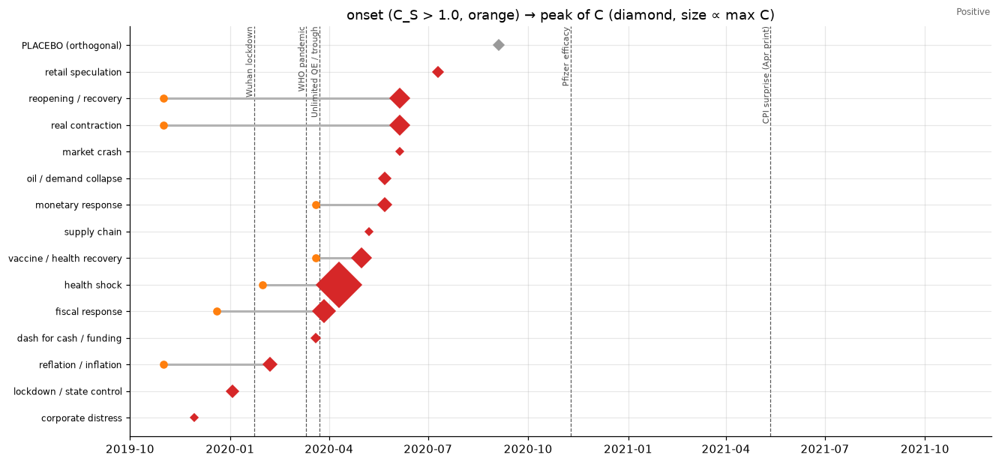

In [71]:
win = v.join(v_s, on="WEEK", suffix="_S")
wv = []
for b in blist:
    ys = win[f"{b}_S"].to_numpy(); y = win[b].to_numpy()
    on = np.flatnonzero(ys > ONSET_THRESHOLD)
    wv.append({"battery": b, "onset_CS": win["WEEK"][int(on[0])] if on.size else None,
               "peak_C": win["WEEK"][int(np.nanargmax(y))], "max_C": float(np.nanmax(y)),
               "max_CS": float(np.nanmax(ys)), "weeks_CS_lit": int(on.size)})
waves = pl.DataFrame(wv).sort("peak_C")
display(waves.with_columns(pl.selectors.float().round(2)))

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, r in enumerate(waves.iter_rows(named=True)):
    col = "0.6" if r["battery"] in DIAGNOSTIC else "tab:red"
    if r["onset_CS"] is not None:
        ax.plot([r["onset_CS"], r["peak_C"]], [i, i], color="0.7", lw=2)
        ax.plot(r["onset_CS"], i, "o", color="tab:orange")
    ax.plot(r["peak_C"], i, "D", color=col, ms=4 + 3 * max(r["max_C"], 0))
ax.set_yticks(range(waves.height), waves["battery"], fontsize=8)
date_axis(ax); shade_events(ax)
ax.set_title(f"onset (C_S > {ONSET_THRESHOLD}, orange) → peak of C (diamond, size ∝ max C)")
plt.show()

In [72]:
# the leading narratives of each quarter (mean C), 2019Q4 .. end of window
q = (panel.filter(pl.col("WEEK").is_between(*VIEW) & pl.col("COMPOSITE").is_not_null())
     .with_columns(pl.col("WEEK").dt.truncate("1q").alias("Q"))
     .group_by("Q", KEY).agg(pl.col("COMPOSITE").mean())
     .join(NARR.select(KEY, "narrative", "pole"), on=KEY)
     .with_columns(pl.when(pl.col("pole").fill_null("") != "").then(pl.format("{} ({})", "narrative", "pole"))
                   .otherwise(pl.col("narrative")).alias("label"))
     .sort("Q", "COMPOSITE", descending=[False, True])
     .group_by("Q", maintain_order=True).head(5)
     .with_columns(pl.format("{} {}", pl.col("label"), pl.col("COMPOSITE").round(2)).alias("top"))
     .group_by("Q", maintain_order=True).agg(pl.col("top"))
     .with_columns(pl.col("Q").dt.strftime("%Y-%m"), *[pl.col("top").list.get(i, null_on_oob=True).alias(f"#{i+1}")
                                                       for i in range(5)])
     .drop("top"))
q

Q,#1,#2,#3,#4,#5
str,str,str,str,str,str
"""2019-10""","""trade-agreement-and-liberalisation (liberalisation) 1.52""","""earnings 0.9""","""accretive-financing (financing) 0.86""","""alliance-and-bloc 0.54""","""equity-issuance (issuance) 0.52"""
"""2020-01""","""public-health 3.19""","""pandemic-and-epidemic-outbreak 2.98""","""health-fear-and-contagion-salience 1.61""","""fiscal-expansion-impulse (impulse) 0.78""","""natural-disaster-humanitarian-harm 0.72"""
"""2020-04""","""public-health 8.36""","""pandemic-and-epidemic-outbreak 5.42""","""health-fear-and-contagion-salience 2.98""","""liquidity-facility-as-policy 1.95""","""natural-disaster-humanitarian-harm 1.83"""
"""2020-07""","""public-health 4.65""","""pandemic-and-epidemic-outbreak 2.2""","""valuation 2.13""","""earnings 1.62""","""dividend 1.61"""


## D.8. Topic-level (direction-free) view


{'public health': 1, 'market volatility': 3, 'funding & plumbing': 3, 'monetary policy': 3, 'fiscal': 2, 'output & labour': 3, 'supply chain': 3, 'prices': 1, 'state control': 2, 'PLACEBO (orthogonal)': 3}


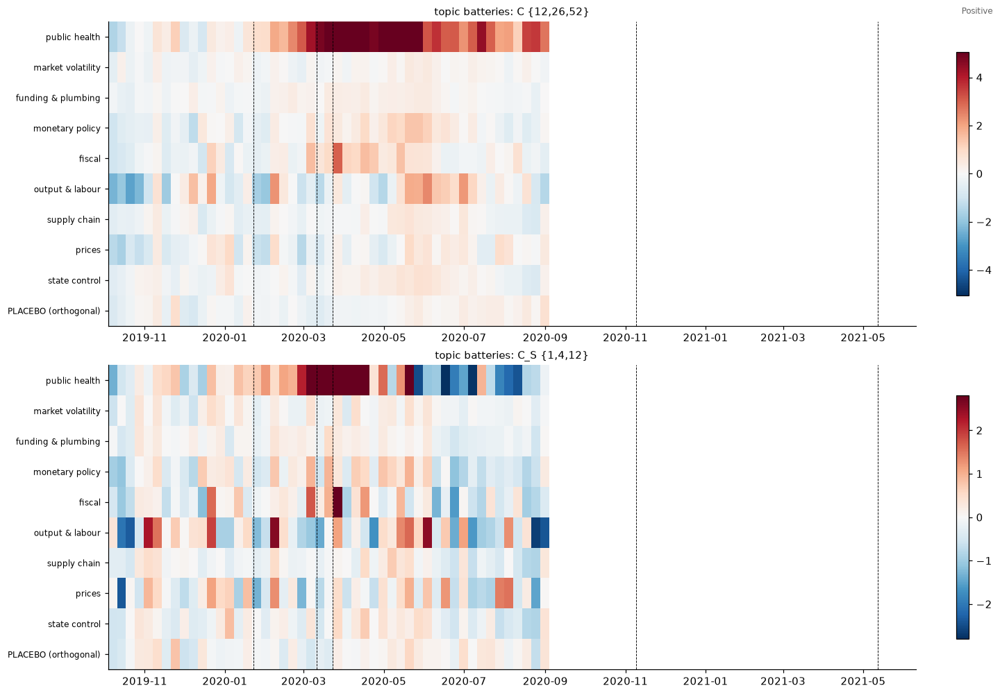

top / bottom dimensions in the crash (C_S) with their vaccine/reflation-phase C


narrative_key,C_S_crash,C_vaccine_reflation
str,f64,f64


In [73]:
topic_daily = (daily.group_by("DATE", "reservoir", "dimension")
               .agg(pl.col("THETA").sum(), pl.col("N_HEADLINES").first())
               .with_columns(pl.format("{}|{}", "reservoir", "dimension").alias(KEY)))
tpanel = post_process(topic_daily)
TKEYS = {b: [k for k in ks if k in set(tpanel[KEY].unique().to_list())] for b, ks in TOPIC_BATTERIES.items()}
print({b: len(k) for b, k in TKEYS.items()})
TW, TC, tbat = battery_frame(tpanel, "COMPOSITE", TKEYS)
_, _, tbat_s = battery_frame(tpanel, "COMPOSITE_S", TKEYS)
tv = tbat.filter(pl.col("WEEK").is_between(*VIEW)); tv_s = tbat_s.filter(pl.col("WEEK").is_between(*VIEW))
tlist = [b for b in TKEYS if TKEYS[b]]
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.colorbar(heat(axes[0], tv, tlist, "topic batteries: C {12,26,52}"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], tv_s, tlist, "topic batteries: C_S {1,4,12}"), ax=axes[1], shrink=0.8)
plt.show()

trank = (tpanel.filter(pl.col("WEEK").is_between(date(2020, 2, 24), date(2020, 4, 3)) & pl.col("COMPOSITE_S").is_not_null())
         .group_by(KEY).agg(pl.col("COMPOSITE_S").mean().alias("C_S_crash"))
         .join(tpanel.filter(pl.col("WEEK").is_between(date(2020, 11, 1), date(2021, 6, 30)))
               .group_by(KEY).agg(pl.col("COMPOSITE").mean().alias("C_vaccine_reflation")), on=KEY)
         .sort("C_S_crash", descending=True))
print("top / bottom dimensions in the crash (C_S) with their vaccine/reflation-phase C")
display(pl.concat([trank.head(12), trank.tail(6)]).with_columns(pl.selectors.float().round(2)))

## D.9. Robustness: stage-1 variants


corr(C spec, C trailing 5y seasonal) over the window = 0.954
corr(C spec, C no stage 1) over the window = 0.867


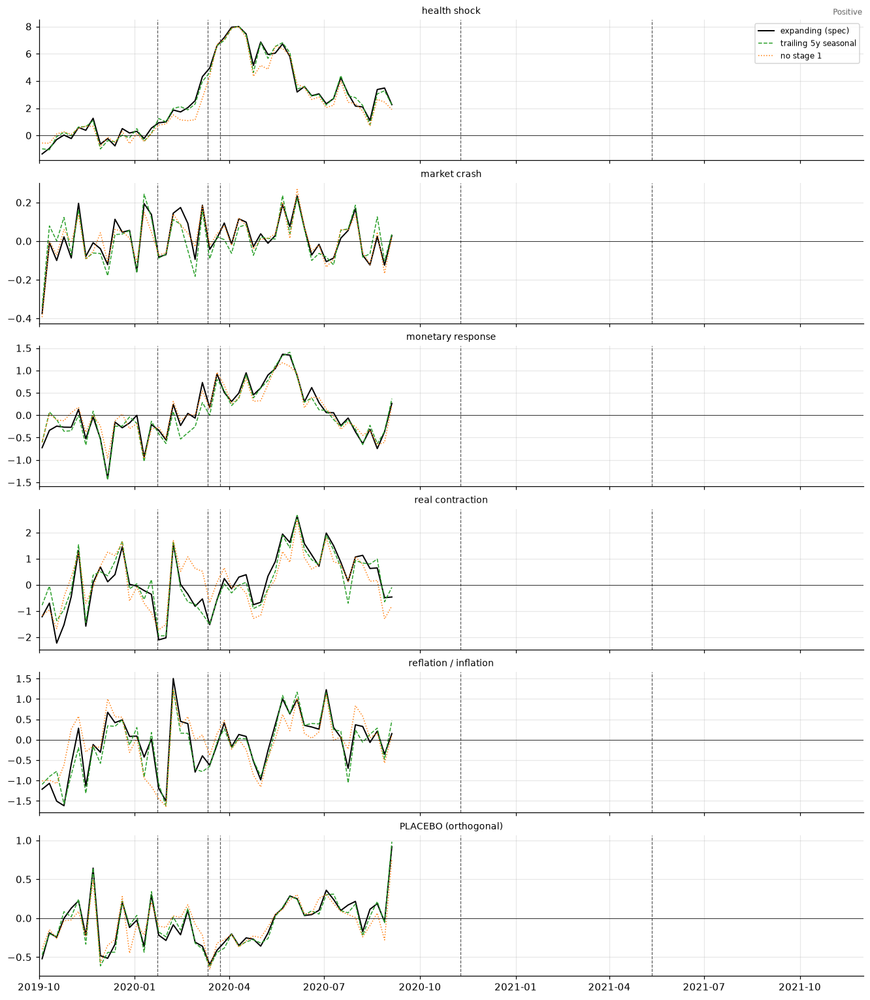

In [74]:
variants = {"expanding (spec)": panel,
            f"trailing {SEASONAL_YEARS_ROBUST}y seasonal": post_process(daily, seasonal_years=SEASONAL_YEARS_ROBUST),
            "no stage 1": post_process(daily, deseason=False)}
ref = panel.select("WEEK", KEY, "COMPOSITE")
for name, p in list(variants.items())[1:]:
    j = ref.join(p.select("WEEK", KEY, pl.col("COMPOSITE").alias("ALT")), on=["WEEK", KEY]).drop_nulls()
    j = j.filter(pl.col("WEEK").is_between(*VIEW))
    print(f"corr(C spec, C {name}) over the window = {np.corrcoef(j['COMPOSITE'], j['ALT'])[0, 1]:.3f}")

show = [b for b in ("health shock", "market crash", "monetary response", "real contraction",
                    "reflation / inflation", PLACEBO) if b in blist]
fig, axes = plt.subplots(len(show), 1, figsize=(12, 2.3 * len(show)), sharex=True)
styles = {"expanding (spec)": ("k", "-", 1.3), f"trailing {SEASONAL_YEARS_ROBUST}y seasonal": ("tab:green", "--", 1),
          "no stage 1": ("tab:orange", ":", 1)}
for name, p in variants.items():
    _, _, b_ = battery_frame(p, "COMPOSITE", {b: BKEYS[b] for b in show})
    b_ = b_.filter(pl.col("WEEK").is_between(*VIEW))
    for ax, b in zip(np.atleast_1d(axes), show):
        c, ls, lw = styles[name]
        ax.plot(b_["WEEK"], b_[b], color=c, ls=ls, lw=lw, label=name)
for ax, b in zip(np.atleast_1d(axes), show):
    ax.axhline(0, color="k", lw=0.5); ax.set_title(b, fontsize=9); date_axis(ax); shade_events(ax, labels=False)
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.show()

In [75]:
# summary per battery: baseline vs Covid phases
phases_ = {"baseline": BASELINE, "shock (Feb–May 20)": (date(2020, 2, 17), date(2020, 5, 31)),
           "vaccine (Nov 20–Mar 21)": (date(2020, 11, 1), date(2021, 3, 31)),
           "reflation (Apr–Nov 21)": (date(2021, 4, 1), VIEW[1])}
summ = []
for b in blist:
    r = {"battery": b}
    for name, (lo_, hi_) in phases_.items():
        r[f"C {name}"] = bat.filter(pl.col("WEEK").is_between(lo_, hi_))[b].mean()
    r["max z (window)"] = batz.filter(pl.col("WEEK").is_between(*VIEW))[b].max()
    summ.append(r)
pl.DataFrame(summ).with_columns(pl.selectors.float().round(2))

battery,C baseline,C shock (Feb–May 20),C vaccine (Nov 20–Mar 21),C reflation (Apr–Nov 21),max z (window)
str,f64,f64,null,null,f64
"""health shock""",0.24,5.83,null,null,17.78
"""lockdown / state control""",0.23,0.13,null,null,1.73
"""market crash""",0.05,0.05,null,null,0.89
"""dash for cash / funding""",0.04,0.24,null,null,1.88
"""monetary response""",0.17,0.65,null,null,3.5
"""fiscal response""",0.09,0.9,null,null,4.29
"""real contraction""",0.11,0.02,null,null,2.09
"""corporate distress""",0.03,0.02,null,null,0.8
"""oil / demand collapse""",0.04,0.1,null,null,1.9


## 11. Reading guide / caveats

* **Attention and tone.** θ is the share of the flow about a narrative; v3 scores at narrative level (poles merged), the topic view (section 8) is unchanged, and the direction comes from the headline's sentiment: Part B (negative) vs Parts C (positive + neutral) and D (positive only).
* **Two composites.** C {12,26,52} is the spec composite (slow, a build-up measure relative to
  the past year); C_S {1,4,12} is added because Covid is an abrupt shock. Onsets are dated on
  C_S, peaks on C.
* **Crowding-out.** Shares sum to a near-constant, so a dominant theme (Covid in 2020) mechanically
  pushes everything else negative; the permutation test (same-week random batteries) controls
  for it, the baseline z-scores and the bootstrap do not.
* **Feed.** Headline volume roughly doubles between 2019 and 2021 (section 1); Σθ is the check
  that the labelled share stays stable. The trailing-5y seasonal variant avoids leaning on the
  pre-2007 feed.
* **Point-in-time.** Every stage uses information available at the Friday of week *t*; scores are
  point-in-time (tau_asof, mu_asof with a 1-month delay). Single scoring configuration, no
  headline bootstrap.